# C2O — Step 1: Building the Daily Panel




## 0. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import json
import math
import time
import warnings

try:
    from IPython.display import display
except Exception:
    display = print
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x=None, **kwargs):
        return x if x is not None else []
try:
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
except Exception as e:
    Ridge = None
    StandardScaler = None
    print(f"sklearn unavailable; Ridge signal will be skipped: {e}")

DEV_START = pd.Timestamp("2010-01-01")
DEV_END = pd.Timestamp("2024-12-31")
TRAIN_END = pd.Timestamp("2018-12-31")
VALIDATION_START = pd.Timestamp("2019-01-01")
VALIDATION_END = pd.Timestamp("2021-12-31")
DEVELOPMENT_TEST_START = pd.Timestamp("2022-01-01")
TRADING_DAYS_PER_YEAR = 252
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT = Path.cwd()
DATA_DIR = ROOT
OUT_DIR = ROOT / "c2o_outputs"
FIG_DIR = OUT_DIR / "figures"
STEP1_FIG_DIR = FIG_DIR / "step1"
STEP2_FIG_DIR = FIG_DIR / "step2"
STEP3_FIG_DIR = FIG_DIR / "step3"
for _p in [OUT_DIR, FIG_DIR, STEP1_FIG_DIR, STEP2_FIG_DIR, STEP3_FIG_DIR]:
    _p.mkdir(parents=True, exist_ok=True)

AUM_LEVELS = {"50m": 50_000_000, "250m": 250_000_000, "1b": 1_000_000_000}
HEADLINE_AUM_LABEL = "250m"
PARTICIPATION_CAP = 0.05
MIN_PRICE = 5.0
VOL_MIN_ANNUALISED = 0.02
VOL_MAX_ANNUALISED = 2.0
ADV_ABSOLUTE_FLOOR = 5_000_000
MIN_CAPACITY_RATIO = 0.25
ASSUMED_N_NAMES = 200
EARNINGS_EXCLUSION_DAYS = 1
COMMISSION_BPS_PER_LEG = 0.5
AUCTION_SLIPPAGE_BPS_PER_LEG = 1.5
BORROW_COST_BPS_PA = {"A": 40.0, "B": 200.0, "C": 800.0}
BASKET_FRACTIONS = [0.01, 0.025, 0.05, 0.10]
HEADLINE_SHORT_TREATMENT = "tiered"

RUN_ML_RULE = False
BORROW_TIER_METHOD = "simple"

generated_files = []
displayed_figure_files = []

def out_path(name):
    p = OUT_DIR / name
    p.parent.mkdir(parents=True, exist_ok=True)
    generated_files.append(str(p.resolve()))
    return p

def save_and_show(fig, path, dpi=150):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    displayed_figure_files.append(str(path.resolve()))
    print(f"Saved and displayed figure: {path.resolve()}")
    plt.show(block=False)

def assert_cutoff(df, date_col="date", name="dataframe"):
    if date_col in df.columns and len(df):
        mx = pd.to_datetime(df[date_col]).max()
        assert mx <= DEV_END, f"{name} contains dates beyond {DEV_END.date()}: {mx}"

def period_from_date(s):
    s = pd.to_datetime(s)
    return np.select(
        [(s >= DEV_START) & (s <= TRAIN_END), (s >= VALIDATION_START) & (s <= VALIDATION_END), (s >= DEVELOPMENT_TEST_START) & (s <= DEV_END)],
        ["train", "validation", "development_test"],
        default="outside",
    )

def period_masks(daily):
    return {
        "full_2010_2024": daily["date"].between(DEV_START, DEV_END),
        "train": daily["date"].between(DEV_START, TRAIN_END),
        "validation": daily["date"].between(VALIDATION_START, VALIDATION_END),
        "development_test": daily["date"].between(DEVELOPMENT_TEST_START, DEV_END),
    }

pd.options.display.max_columns = 160
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120
print(f"Setup complete. OUT_DIR={OUT_DIR.resolve()}")


/Users/cuiyufan/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. OUT_DIR=/Users/cuiyufan/Desktop/ml data/c2o_outputs


## 1. Load and Clean Price Data

**Data source**: `prices.parquet` — Daily OHLCV and market capitalisation per instrument, corporate-action-adjusted close series. Window: 2000–2024.

**Key columns**:
- `open`, `close`: Raw (unadjusted) prices
- `adjusted_close`: Split- and dividend-adjusted close price
- `volume`: Consolidated daily share volume
- `market_cap`: End-of-day market capitalisation
- `status`: `'1'` = active record, `'0'` = legacy/renamed ticker (excluded)
- `instrument_id`: Numeric ID linking to earnings and short-interest files via `stock_id`


In [2]:
# Load prices — keep pre-2010 history for prior-year universe snapshots and 12-month history checks.
prices = pd.read_parquet(
    DATA_DIR / "prices.parquet",
    columns=["ticker", "instrument_id", "date", "open", "high", "low", "close", "adjusted_close", "volume", "market_cap", "status"],
)
prices["date"] = pd.to_datetime(prices["date"])
prices = prices[prices["date"] <= DEV_END].copy()
assert_cutoff(prices, name="prices")

raw_dup_iid_date = int(prices.duplicated(["instrument_id", "date"]).sum())
raw_dup_date_ticker = int(prices.duplicated(["date", "ticker"]).sum())
print(f"Raw duplicates: instrument_id-date={raw_dup_iid_date:,}; date-ticker={raw_dup_date_ticker:,}")
print("Status != 1 is not filtered out; status is used only to choose among same instrument_id-date duplicates.")
prices["_status_sort"] = prices["status"].astype(str).eq("1").astype(int)
prices = (
    prices.sort_values(["instrument_id", "date", "_status_sort", "ticker"], ascending=[True, True, False, True])
    .drop_duplicates(["instrument_id", "date"], keep="first")
    .drop(columns=["_status_sort"])
    .sort_values(["instrument_id", "date"])
    .reset_index(drop=True)
)
print(f"Post-clean duplicates: instrument_id-date={prices.duplicated(['instrument_id','date']).sum():,}; date-ticker={prices.duplicated(['date','ticker']).sum():,}")
assert prices.duplicated(["instrument_id", "date"]).sum() == 0, "instrument_id-date must be unique."
for c in ["open", "high", "low", "close", "adjusted_close", "volume", "market_cap"]:
    prices[c] = pd.to_numeric(prices[c], errors="coerce")

display(pd.DataFrame({"dataset": ["prices_raw_cleaned"], "min_date": [prices["date"].min()], "max_date": [prices["date"].max()], "rows": [len(prices)], "instrument_ids": [prices["instrument_id"].nunique()]}))


Raw duplicates: instrument_id-date=117,138; date-ticker=2,898
Status != 1 is not filtered out; status is used only to choose among same instrument_id-date duplicates.
Post-clean duplicates: instrument_id-date=0; date-ticker=0


,dataset,min_date,max_date,rows,instrument_ids
0,prices_raw_cleaned,2000-01-03,2024-12-31,7883230,1607


## 2. Compute Return Objects

The file provides **raw** open/close and **adjusted** close. We need adjusted open to compute overnight returns correctly across splits and dividends.

**Method**: `adj_open = open × (adjusted_close / close)`

This applies the same-day adjustment factor (which captures all splits + dividends) to the open price.

**Return definitions**:
- **Overnight**: $r_{ON,t} = \frac{\text{AdjOpen}_t}{\text{AdjClose}_{t-1}} - 1$
- **Intraday**: $r_{ID,t} = \frac{\text{AdjClose}_t}{\text{AdjOpen}_t} - 1$
- **Close-to-close**: $(1 + r_{ON,t}) \times (1 + r_{ID,t}) - 1$

The reconciliation check below verifies that the three return legs are internally consistent up to numerical tolerance.


In [3]:
# Compute adjusted open price and strict one-overnight target.
prices["adj_factor"] = prices["adjusted_close"] / prices["close"]
prices["adj_open"] = prices["open"] * prices["adj_factor"]
prices["prev_adj_close"] = prices.groupby("instrument_id")["adjusted_close"].shift(1)
prices["r_on"] = prices["adj_open"] / prices["prev_adj_close"] - 1
prices["r_id"] = prices["adjusted_close"] / prices["adj_open"] - 1
prices["r_cc"] = prices["adjusted_close"] / prices["prev_adj_close"] - 1

all_trading_days = pd.Series(sorted(prices["date"].dropna().unique()))
next_trading_day_map = dict(zip(all_trading_days.iloc[:-1], all_trading_days.iloc[1:]))
prices["expected_next_trading_day"] = prices["date"].map(next_trading_day_map)
prices["next_date"] = prices.groupby("instrument_id")["date"].shift(-1)
prices["next_adj_open"] = prices.groupby("instrument_id")["adj_open"].shift(-1)
raw_target_next_overnight = prices["next_adj_open"] / prices["adjusted_close"] - 1
prices["is_strict_one_overnight_target"] = prices["next_date"].eq(prices["expected_next_trading_day"])
prices["target_next_overnight"] = raw_target_next_overnight.where(prices["is_strict_one_overnight_target"], np.nan)
strict_target_audit = pd.DataFrame({
    "metric": ["total_raw_next_row_targets", "valid_strict_one_overnight_targets", "invalidated_non_consecutive_targets", "invalidated_percentage"],
    "value": [int(raw_target_next_overnight.notna().sum()), int(prices["target_next_overnight"].notna().sum()), int(raw_target_next_overnight.notna().sum() - prices["target_next_overnight"].notna().sum()), float((raw_target_next_overnight.notna() & prices["target_next_overnight"].isna()).mean())],
})
display(strict_target_audit)


,metric,value
0,total_raw_next_row_targets,7.881623e+06
1,valid_strict_one_overnight_targets,7.873508e+06
2,invalidated_non_consecutive_targets,8.115000e+03
3,invalidated_percentage,1.029400e-03


### 2.1 Reconciliation Check

The brief requires the overnight and intraday legs to compound back to the close-to-close return:

$(1 + r_{ON}) \times (1 + r_{ID}) - 1$ = $r_{CC}$

Large residuals would indicate an adjustment or data-cleaning issue; machine-precision residuals are expected.

In [4]:
# Reconciliation: (1 + r_on) * (1 + r_id) - 1 should equal r_cc.
valid = prices["prev_adj_close"].notna() & prices["r_on"].notna() & prices["r_id"].notna() & prices["r_cc"].notna()
recon = (1 + prices.loc[valid, "r_on"]) * (1 + prices.loc[valid, "r_id"]) - 1
prices.loc[valid, "return_reconciliation_error"] = recon - prices.loc[valid, "r_cc"]
recon_table = pd.DataFrame({
    "metric": ["max_abs_error", "p99_abs_error", "n_checked"],
    "value": [prices.loc[valid, "return_reconciliation_error"].abs().max(), prices.loc[valid, "return_reconciliation_error"].abs().quantile(0.99), int(valid.sum())],
})
display(recon_table)
assert recon_table.loc[recon_table["metric"].eq("max_abs_error"), "value"].iloc[0] < 1e-10, "Return reconciliation error too large."


,metric,value
0,max_abs_error,4.440892e-16
1,p99_abs_error,2.220446e-16
2,n_checked,7.881623e+06


## 3. Yearly Eligible Universe

For calendar year `Y`, the eligible universe is frozen using the prior calendar year's final available trading-day market-cap snapshot. Names must have at least 12 months of price history as of that snapshot; the top 1000 by market cap are then held fixed for year `Y`.


In [5]:
first_date_per_id = prices.groupby("instrument_id")["date"].min().rename("first_date")
universe_rows = []
universe_audit_rows = []
for year in range(DEV_START.year, DEV_END.year + 1):
    prior = prices[prices["date"].dt.year.eq(year - 1)]
    if prior.empty:
        fallback = prices[prices["date"].dt.year.eq(year)]
        assert not fallback.empty, f"No rows for fallback universe year {year}."
        asof_date = fallback["date"].min()
        fallback_used = True
        print(f"WARNING: no prior-year data for {year}; using {asof_date.date()} as data-boundary fallback.")
    else:
        asof_date = prior["date"].max()
        fallback_used = False
    snap = prices.loc[prices["date"].eq(asof_date), ["instrument_id", "ticker", "date", "market_cap"]].dropna(subset=["market_cap"]).copy()
    total_names_seen = int(snap["instrument_id"].nunique())
    snap = snap.merge(first_date_per_id.reset_index(), on="instrument_id", how="left")
    snap["months_hist"] = (snap["date"] - snap["first_date"]).dt.days / 30.4375
    before = len(snap)
    snap = snap[snap["months_hist"].ge(12.0)].copy()
    sufficient_history_names = int(snap["instrument_id"].nunique())
    removed = before - len(snap)
    if removed:
        print(f"Universe {year}: removed {removed:,} names with <12 months history at {asof_date.date()}.")
    snap = snap.sort_values(["market_cap", "instrument_id"], ascending=[False, True]).head(1000).copy()
    snap["universe_rank"] = np.arange(1, len(snap) + 1)
    snap["year"] = year
    snap["universe_asof_date"] = asof_date
    snap["universe_entry_date"] = asof_date
    snap["data_boundary_fallback"] = fallback_used
    universe_rows.append(snap[["year", "instrument_id", "ticker", "market_cap", "universe_asof_date", "universe_entry_date", "first_date", "months_hist", "universe_rank", "data_boundary_fallback"]])
    universe_audit_rows.append({"year": year, "universe_asof_date": asof_date, "data_boundary_fallback": fallback_used, "total_names_seen": total_names_seen, "names_with_sufficient_12m_history": sufficient_history_names, "top1000_eligible_names": int(snap["instrument_id"].nunique()), "excluded_by_market_cap_or_history_count": int(total_names_seen - snap["instrument_id"].nunique()), "excluded_percentage": float((total_names_seen - snap["instrument_id"].nunique()) / total_names_seen) if total_names_seen else np.nan})
universe_map = pd.concat(universe_rows, ignore_index=True)
assert universe_map["months_hist"].ge(12).all(), "Universe contains <12 months history names."
assert universe_map.groupby("year")["instrument_id"].nunique().le(1000).all(), "Universe has >1000 names."
universe_sanity = universe_map.groupby("year").agg(universe_size=("instrument_id", "nunique"), universe_asof_date=("universe_asof_date", "first"), min_months_hist=("months_hist", "min"), median_months_hist=("months_hist", "median"), max_rank=("universe_rank", "max")).reset_index()
mcap_universe_audit = pd.DataFrame(universe_audit_rows)
display(universe_sanity)
display(mcap_universe_audit)


Universe 2010: removed 15 names with <12 months history at 2009-12-31.
Universe 2011: removed 28 names with <12 months history at 2010-12-31.
Universe 2012: removed 22 names with <12 months history at 2011-12-30.
Universe 2013: removed 30 names with <12 months history at 2012-12-31.
Universe 2014: removed 49 names with <12 months history at 2013-12-31.
Universe 2015: removed 39 names with <12 months history at 2014-12-31.
Universe 2016: removed 44 names with <12 months history at 2015-12-31.
Universe 2017: removed 32 names with <12 months history at 2016-12-30.
Universe 2018: removed 32 names with <12 months history at 2017-12-29.
Universe 2019: removed 33 names with <12 months history at 2018-12-31.
Universe 2020: removed 24 names with <12 months history at 2019-12-31.
Universe 2021: removed 29 names with <12 months history at 2020-12-31.
Universe 2022: removed 38 names with <12 months history at 2021-12-31.
Universe 2023: removed 6 names with <12 months history at 2022-12-30.
Univers

,year,universe_size,universe_asof_date,min_months_hist,median_months_hist,max_rank
0,2010,1000,2009-12-31,13.338809,119.917864,1000
1,2011,1000,2010-12-31,12.648871,131.909651,1000
2,2012,1000,2011-12-30,12.484600,143.868583,1000
3,2013,1000,2012-12-31,12.550308,155.926078,1000
4,2014,1000,2013-12-31,12.583162,167.917864,1000
5,2015,1000,2014-12-31,12.616016,179.909651,1000
6,2016,1000,2015-12-31,12.057495,191.901437,1000
7,2017,1000,2016-12-30,12.681725,203.893224,1000
8,2018,1000,2017-12-29,12.484600,215.852156,1000
9,2019,1000,2018-12-31,14.160164,227.909651,1000


,year,universe_asof_date,data_boundary_fallback,total_names_seen,names_with_sufficient_12m_history,top1000_eligible_names,excluded_by_market_cap_or_history_count,excluded_percentage
0,2010,2009-12-31,False,1117,1102,1000,117,0.104745
1,2011,2010-12-31,False,1153,1125,1000,153,0.132697
2,2012,2011-12-30,False,1179,1157,1000,179,0.151824
3,2013,2012-12-31,False,1218,1188,1000,218,0.178982
4,2014,2013-12-31,False,1270,1221,1000,270,0.212598
5,2015,2014-12-31,False,1312,1273,1000,312,0.237805
6,2016,2015-12-31,False,1359,1315,1000,359,0.264165
7,2017,2016-12-30,False,1395,1363,1000,395,0.283154
8,2018,2017-12-29,False,1432,1400,1000,432,0.301676
9,2019,2018-12-31,False,1465,1432,1000,465,0.317406


In [ ]:
# Attach annual frozen-universe membership to the daily price panel.
eligible_keys = universe_map[["year", "instrument_id", "universe_asof_date", "universe_entry_date", "universe_rank"]].drop_duplicates()
prices["year"] = prices["date"].dt.year
prices = prices.merge(eligible_keys.assign(eligible=True), on=["year", "instrument_id"], how="left")
prices["eligible"] = prices["eligible"].eq(True)
panel = prices[prices["date"].between(DEV_START, DEV_END)].copy()
panel_cols = ["ticker", "instrument_id", "date", "year", "open", "high", "low", "close", "adjusted_close", "adj_open", "volume", "market_cap", "r_on", "r_id", "r_cc", "target_next_overnight", "expected_next_trading_day", "next_date", "next_adj_open", "is_strict_one_overnight_target", "eligible", "universe_asof_date", "universe_entry_date", "universe_rank"]
panel = panel[panel_cols]
assert_cutoff(panel, name="panel")
assert panel.duplicated(["date", "instrument_id"]).sum() == 0
step2_mcap_fail_audit = panel.assign(mcap_history_fail_stock_day=(~panel["eligible"])).groupby("year").agg(panel_stock_days=("instrument_id", "size"), MCAP_FAIL_OR_HISTORY_FAIL=("mcap_history_fail_stock_day", "sum")).reset_index()
step2_mcap_fail_audit["mcap_history_fail_share"] = step2_mcap_fail_audit["MCAP_FAIL_OR_HISTORY_FAIL"] / step2_mcap_fail_audit["panel_stock_days"]
print("Step1 applies annual ex-ante top-1000 market-cap/history universe. Step2 reason tables are conditional on eligible=True.")
display(step2_mcap_fail_audit)


Step1 applies annual ex-ante top-1000 market-cap/history universe. Step2 reason tables are conditional on eligible=True.


,year,panel_stock_days,MCAP_FAIL_OR_HISTORY_FAIL,mcap_history_fail_share
0,2010,293467,41467,0.141300
1,2011,299749,47750,0.159300
2,2012,304829,54830,0.179871
3,2013,317151,65152,0.205429
4,2014,329104,77104,0.234285
5,2015,339941,87943,0.258701
6,2016,348130,96132,0.276138
7,2017,356595,105595,0.296120
8,2018,365459,114460,0.313195
9,2019,374289,122294,0.326737


## 4. Earnings Calendar — AMC/BMO Timing


- **BMO** (Before Market Open): announced before 09:30 ET → observable same day → `effective_date = reporting_date`
- **AMC** (After Market Close): announced after 16:00 ET → NOT observable at 15:50 ET decision time → `effective_date = next trading day`

This prevents look-ahead bias: an AMC earnings event on day D cannot be used to predict $r_{ON,D+1}$ because at 15:50 ET on day D, the announcement hasn't happened yet.


In [7]:
earnings = pd.read_parquet(DATA_DIR / "earnings_calendar.parquet")
earnings["reporting_date"] = pd.to_datetime(earnings["reporting_date"]).dt.normalize()
if "strat_trading_date" in earnings.columns:
    earnings["strat_trading_date"] = pd.to_datetime(earnings["strat_trading_date"]).dt.normalize()
if "reporting_time" not in earnings.columns:
    earnings["reporting_time"] = pd.NaT
earnings = earnings[earnings["reporting_date"] <= DEV_END].copy()
assert_cutoff(earnings, "reporting_date", "earnings")

tdays = pd.DataFrame({"date": sorted(panel["date"].drop_duplicates())}).reset_index(drop=True)
tdays["previous_trading_day"] = tdays["date"].shift(1)
tdays["next_trading_day"] = tdays["date"].shift(-1)
trading_dates = pd.DatetimeIndex(tdays["date"])

def next_trading_day_on_or_after(ts):
    if pd.isna(ts): return pd.NaT
    pos = trading_dates.searchsorted(pd.Timestamp(ts).normalize(), side="left")
    return trading_dates[pos] if pos < len(trading_dates) else pd.NaT

def next_trading_day_after(ts):
    if pd.isna(ts): return pd.NaT
    pos = trading_dates.searchsorted(pd.Timestamp(ts).normalize(), side="right")
    return trading_dates[pos] if pos < len(trading_dates) else pd.NaT

def previous_trading_day_before(ts):
    if pd.isna(ts): return pd.NaT
    pos = trading_dates.searchsorted(pd.Timestamp(ts).normalize(), side="left") - 1
    return trading_dates[pos] if pos >= 0 else pd.NaT

earnings["reporting_date_was_trading_day"] = earnings["reporting_date"].isin(trading_dates)
earnings["reporting_trading_date"] = earnings["reporting_date"].map(next_trading_day_on_or_after)
non_trading_reporting = int((~earnings["reporting_date_was_trading_day"]).sum())
if non_trading_reporting:
    print(f"Mapped {non_trading_reporting:,} non-trading reporting dates to next trading day.")
time_str = earnings.get("before_after_market", pd.Series("", index=earnings.index)).astype(str).str.lower()
is_before = time_str.str.contains("before|bmo", regex=True, na=False)
is_after = time_str.str.contains("after|amc", regex=True, na=False)
earnings["earnings_time_missing"] = False
earnings["earnings_time_source"] = "missing_conservative_after_close"
earnings["is_after_close_for_decision"] = True
earnings.loc[is_before | is_after, "earnings_time_source"] = "explicit_bmo_amc"
earnings.loc[is_before, "is_after_close_for_decision"] = False
needs_time_infer = ~(is_before | is_after)
rt = earnings.loc[needs_time_infer, "reporting_time"]
rt_notna = rt.notna()
if rt_notna.any():
    seconds = rt.loc[rt_notna].dt.total_seconds()
    idx = rt.loc[rt_notna].index
    earnings.loc[idx, "earnings_time_source"] = "reporting_time_inferred"
    earnings.loc[idx, "is_after_close_for_decision"] = (seconds >= (15*3600 + 50*60)).to_numpy()
missing_idx = earnings.index[needs_time_infer & earnings["reporting_time"].isna()]
earnings.loc[missing_idx, "earnings_time_missing"] = True
earnings["effective_date"] = earnings["reporting_trading_date"]
after_mask = earnings["is_after_close_for_decision"].eq(True)
earnings.loc[after_mask, "effective_date"] = earnings.loc[after_mask, "reporting_trading_date"].map(next_trading_day_after)
earnings = earnings[earnings["effective_date"].notna() & (earnings["effective_date"] <= DEV_END)].copy()
earnings["effective_date_is_trading_day"] = earnings["effective_date"].isin(trading_dates)
assert earnings["effective_date_is_trading_day"].all()
earnings["earnings_crossing_decision_date"] = earnings["effective_date"].map(previous_trading_day_before)
earnings_timing_diag = earnings["earnings_time_source"].value_counts(dropna=False).rename_axis("earnings_time_source").reset_index(name="n_rows")
display(earnings_timing_diag)
print("Effective dates are all trading days:", bool(earnings["effective_date_is_trading_day"].all()))


Mapped 126 non-trading reporting dates to next trading day.


,earnings_time_source,n_rows
0,explicit_bmo_amc,60099
1,reporting_time_inferred,823


Effective dates are all trading days: True


### 4.1 Hand-Verification: AAPL Earnings




In [8]:
# Hand-verification: show AAPL-like rows if present, otherwise show a representative sample.
aapl_ids = panel.loc[panel["ticker"].astype(str).str.upper().eq("AAPL"), "instrument_id"].dropna().unique()
if len(aapl_ids):
    aapl_earn = earnings[earnings["stock_id"].isin(aapl_ids)].head(10)
else:
    aapl_earn = earnings.head(10)
display(aapl_earn[[c for c in ["stock_id", "reporting_date", "reporting_time", "before_after_market", "reporting_trading_date", "effective_date", "earnings_crossing_decision_date", "earnings_time_source"] if c in aapl_earn.columns]])


,stock_id,reporting_date,reporting_time,before_after_market,reporting_trading_date,effective_date,earnings_crossing_decision_date,earnings_time_source
16672,397,2010-01-25,0 days 21:00:00,after,2010-01-25,2010-01-26,2010-01-25,explicit_bmo_amc
16673,397,2010-04-20,0 days 20:00:00,after,2010-04-20,2010-04-21,2010-04-20,explicit_bmo_amc
16674,397,2010-07-20,0 days 20:00:00,after,2010-07-20,2010-07-21,2010-07-20,explicit_bmo_amc
16675,397,2010-10-18,0 days 20:00:00,after,2010-10-18,2010-10-19,2010-10-18,explicit_bmo_amc
16676,397,2011-04-20,0 days 20:00:00,after,2011-04-20,2011-04-21,2011-04-20,explicit_bmo_amc
16677,397,2011-07-19,0 days 20:00:00,after,2011-07-19,2011-07-20,2011-07-19,explicit_bmo_amc
16678,397,2011-10-18,0 days 20:00:00,after,2011-10-18,2011-10-19,2011-10-18,explicit_bmo_amc
16679,397,2012-01-24,0 days 21:00:00,after,2012-01-24,2012-01-25,2012-01-24,explicit_bmo_amc
16680,397,2012-04-24,0 days 20:00:00,after,2012-04-24,2012-04-25,2012-04-24,explicit_bmo_amc
16681,397,2012-07-24,0 days 20:00:00,after,2012-07-24,2012-07-25,2012-07-24,explicit_bmo_amc


## 5. Short Interest with Source-Provided Availability Lag

`short_interest_transfo.parquet` contains bi-monthly short-interest snapshots:

- `dsi`: short interest as a fraction of shares outstanding
- `dtcn`: days-to-cover
- `ddtcn`: change in days-to-cover

The file date is treated as the source-provided availability date. We do not add a second publication lag.

For a date-`t` signal, the merge uses the most recent short-interest snapshot available on or before the previous trading day. This keeps the short-interest features out of the date-`t` signal until they would have been available.


In [9]:
short_interest = pd.read_parquet(DATA_DIR / "short_interest_transfo.parquet").rename(columns={"stock_id": "instrument_id"})
short_interest["si_source_available_date"] = pd.to_datetime(short_interest["date"]).dt.normalize()

# The coursework file already reflects publication and availability lag.
# Therefore, do NOT add another calendar-day publication lag.
# Keep these downstream names for compatibility; in this notebook they represent
# the source-provided availability date, not a raw FINRA settlement/snapshot date.
short_interest["si_snapshot_date"] = short_interest["si_source_available_date"]
short_interest["si_publication_available_date"] = short_interest["si_source_available_date"]
short_interest["si_publication_available_trading_date"] = short_interest["si_source_available_date"].map(next_trading_day_on_or_after)
short_interest = short_interest[short_interest["si_publication_available_trading_date"].notna() & (short_interest["si_publication_available_trading_date"] <= DEV_END)].copy()
short_interest["short_interest_pct_float"] = pd.to_numeric(short_interest["dsi"], errors="coerce")
short_interest["days_to_cover"] = pd.to_numeric(short_interest["dtcn"], errors="coerce")
short_interest["change_days_to_cover"] = pd.to_numeric(short_interest["ddtcn"], errors="coerce")
short_interest["short_interest"] = np.nan
assert_cutoff(short_interest, "si_publication_available_trading_date", "short_interest source-provided availability")
print("short_interest_transfo.parquet date is treated as source-provided availability date; no extra publication lag is applied.")
display(short_interest.head())


short_interest_transfo.parquet date is treated as source-provided availability date; no extra publication lag is applied.


,instrument_id,date,dsi,dtcn,ddtcn,si_source_available_date,si_snapshot_date,si_publication_available_date,si_publication_available_trading_date,short_interest_pct_float,days_to_cover,change_days_to_cover,short_interest
0,1,2015-01-27,0.004074,1.669489,-0.245679,2015-01-27,2015-01-27,2015-01-27,2015-01-27,0.004074,1.669489,-0.245679,NaN
1,1,2015-02-10,0.004025,1.134529,-0.362399,2015-02-10,2015-02-10,2015-02-10,2015-02-10,0.004025,1.134529,-0.362399,NaN
2,1,2015-02-25,0.004166,0.889116,-2.261740,2015-02-25,2015-02-25,2015-02-25,2015-02-25,0.004166,0.889116,-2.261740,NaN
3,1,2015-03-10,0.004149,1.039464,-1.945726,2015-03-10,2015-03-10,2015-03-10,2015-03-10,0.004149,1.039464,-1.945726,NaN
4,1,2015-03-24,0.004920,1.345454,-0.139611,2015-03-24,2015-03-24,2015-03-24,2015-03-24,0.004920,1.345454,-0.139611,NaN


### 5.1 Short Interest Plot 

Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step1/representative_short_interest_lag.png


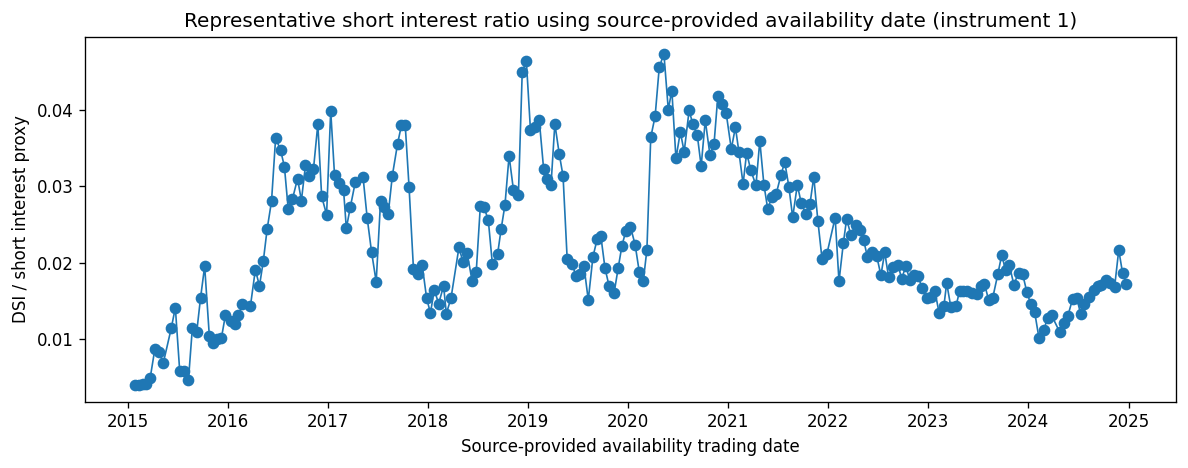

In [10]:
# Plot a representative short-interest ratio over time using the source-provided availability date.
rep_id = short_interest["instrument_id"].dropna().iloc[0]
rep = short_interest[short_interest["instrument_id"].eq(rep_id)].sort_values("si_publication_available_trading_date")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rep["si_publication_available_trading_date"], rep["dsi"], marker="o", linewidth=1)
ax.set_title(f"Representative short interest ratio using source-provided availability date (instrument {rep_id})")
ax.set_xlabel("Source-provided availability trading date")
ax.set_ylabel("DSI / short interest proxy")
save_and_show(fig, STEP1_FIG_DIR / "representative_short_interest_lag.png")


### 5.2 Forward-Fill to Daily Frequency (with t−1 Rule)

The raw short-interest data contains only bi-monthly snapshots (~24 per year). For use in daily features (Step 4), we need a value for every (stock_id, trading_day) pair.

**Critical timing rule** (Brief §2.1.3): the feature on date D uses the most recent snapshot whose availability date is **on or before D−1**. This means a snapshot that becomes available on date X only enters the feature set from date X+1 onward.

Implementation:
1. For each snapshot, shift the availability date forward by 1 trading day
2. Forward-fill from the shifted date to all subsequent trading days
3. The output includes `si_available_date` (the original availability date) for auditability

The join uses `stock_id` (= `instrument_id`), not `ticker`, to avoid mapping ambiguity from renamed tickers (e.g. BRK-B vs BRKb share the same instrument_id=283).


In [11]:
# Forward-fill short interest to daily frequency using previous trading day as the as-of key.
# The right-hand date is the source-provided availability trading date. No extra publication lag is applied here.
cal = tdays[["date", "previous_trading_day"]].copy()
base_keys = panel.loc[panel["eligible"], ["date", "instrument_id", "ticker"]].drop_duplicates().merge(cal, on="date", how="left")
right_cols = ["instrument_id", "si_source_available_date", "si_snapshot_date", "si_publication_available_date", "si_publication_available_trading_date", "short_interest", "short_interest_pct_float", "days_to_cover", "change_days_to_cover", "dsi", "dtcn", "ddtcn"]
right = short_interest[[c for c in right_cols if c in short_interest.columns]].sort_values(["instrument_id", "si_publication_available_trading_date"])
daily_parts = []
for iid, g0 in tqdm(base_keys.sort_values(["instrument_id", "date"]).groupby("instrument_id", sort=False), desc="short interest source-availability as-of fill"):
    g = g0.copy()
    s = right[right["instrument_id"].eq(iid)].copy()
    g["si_asof_key"] = g["previous_trading_day"].fillna(pd.Timestamp("1900-01-01"))
    if s.empty:
        tmp = g.copy()
        date_like_si_cols = {"si_source_available_date", "si_snapshot_date", "si_publication_available_date", "si_publication_available_trading_date"}
        for c in right_cols:
            if c != "instrument_id":
                tmp[c] = pd.NaT if c in date_like_si_cols else np.nan
    else:
        tmp = pd.merge_asof(
            g.sort_values("si_asof_key"),
            s.sort_values("si_publication_available_trading_date"),
            by="instrument_id",
            left_on="si_asof_key",
            right_on="si_publication_available_trading_date",
            direction="backward",
        )
    tmp = tmp.drop(columns=["si_asof_key"], errors="ignore")
    daily_parts.append(tmp)
short_interest_daily = pd.concat(daily_parts, ignore_index=True, sort=False)
short_interest_daily["si_missing"] = short_interest_daily[["dsi", "dtcn", "ddtcn"]].isna().any(axis=1)
short_interest_daily["si_age_calendar_days_to_decision_prev_day"] = (short_interest_daily["previous_trading_day"] - short_interest_daily["si_publication_available_trading_date"]).dt.days
nonmissing_si = short_interest_daily[~short_interest_daily["si_missing"]].copy()
si_lookahead_violations = nonmissing_si[nonmissing_si["si_publication_available_trading_date"] > nonmissing_si["previous_trading_day"]]
assert len(si_lookahead_violations) == 0, f"SI availability lookahead violations: {len(si_lookahead_violations)}"
si_no_lookahead_summary = pd.DataFrame({"check": ["source_availability_after_previous_trading_day"], "violation_count": [len(si_lookahead_violations)]})
si_coverage_by_year = short_interest_daily.assign(year=short_interest_daily["date"].dt.year).groupby("year").agg(rows=("instrument_id", "size"), nonmissing_si_ratio=("si_missing", lambda s: 1-s.mean()), mean_age_days=("si_age_calendar_days_to_decision_prev_day", "mean"), min_age_days=("si_age_calendar_days_to_decision_prev_day", "min")).reset_index()
print("Short-interest no-lookahead violations:", len(si_lookahead_violations))
print("Source-provided availability date is used with previous-trading-day as-of merge; no extra publication lag is applied.")
display(si_no_lookahead_summary)
display(si_coverage_by_year)


short interest source-availability as-of fill: 100%|██████████| 1418/1418 [00:08<00:00, 167.16it/s]


Short-interest no-lookahead violations: 0
Source-provided availability date is used with previous-trading-day as-of merge; no extra publication lag is applied.


,check,violation_count
0,source_availability_after_previous_trading_day,0


,year,rows,nonmissing_si_ratio,mean_age_days,min_age_days
0,2010,252000,0.976155,6.507982,0.0
1,2011,251999,0.980718,7.395788,0.0
2,2012,249999,0.982052,6.877212,0.0
3,2013,251999,0.985480,8.017218,0.0
4,2014,252000,0.986909,7.410911,0.0
5,2015,251998,0.989349,7.315670,0.0
6,2016,251998,0.989409,7.480746,0.0
7,2017,251000,0.990100,7.392186,0.0
8,2018,250999,0.988119,7.474988,0.0
9,2019,251995,0.993944,6.891563,0.0


## 6. Stylised Fact Verification

Construct an equal-weighted portfolio of all eligible names each day and compound the overnight, intraday and close-to-close return streams separately.

The purpose is to check whether the overnight component is stronger than the intraday component in level and risk-adjusted terms within our eligible universe.


In [ ]:
# Use eligible names in the development window and compute equal-weighted daily return legs.
stylised_daily = panel.loc[panel["eligible"], ["date", "r_on", "r_id", "r_cc"]].replace([np.inf, -np.inf], np.nan).groupby("date")[["r_on", "r_id", "r_cc"]].mean().reset_index()
stylised_daily["cum_overnight"] = (1 + stylised_daily["r_on"].fillna(0)).cumprod() - 1
stylised_daily["cum_intraday"] = (1 + stylised_daily["r_id"].fillna(0)).cumprod() - 1
stylised_daily["cum_close_to_close"] = (1 + stylised_daily["r_cc"].fillna(0)).cumprod() - 1

def stylised_metrics(col):
    r = stylised_daily[col].dropna()
    return {"return_leg": col, "annualised_return": (1+r).prod()**(TRADING_DAYS_PER_YEAR/len(r))-1, "annualised_volatility": r.std(ddof=1)*np.sqrt(TRADING_DAYS_PER_YEAR), "sharpe": r.mean()/r.std(ddof=1)*np.sqrt(TRADING_DAYS_PER_YEAR), "mean_daily_return": r.mean(), "n_days": len(r)}
stylised_summary = pd.DataFrame([stylised_metrics(c) for c in ["r_on", "r_id", "r_cc"]])
display(stylised_summary)


,return_leg,annualised_return,annualised_volatility,sharpe,mean_daily_return,n_days
0,r_on,0.099692,0.121181,0.845353,0.000407,3774
1,r_id,0.045004,0.148395,0.370883,0.000218,3774
2,r_cc,0.147729,0.199895,0.789860,0.000627,3774


### 6.1 Year-by-Year Breakdown

In [13]:
# Year-by-year decomposition.
stylised_daily["year"] = stylised_daily["date"].dt.year
stylised_yearly = stylised_daily.groupby("year").agg(yearly_overnight_return=("r_on", lambda s: (1+s.dropna()).prod()-1), yearly_intraday_return=("r_id", lambda s: (1+s.dropna()).prod()-1), yearly_close_to_close_return=("r_cc", lambda s: (1+s.dropna()).prod()-1)).reset_index()
display(stylised_yearly)


,year,yearly_overnight_return,yearly_intraday_return,yearly_close_to_close_return
0,2010,0.105590,0.161524,0.281865
1,2011,0.060034,-0.041074,0.015003
2,2012,0.045917,0.159936,0.211868
3,2013,0.150367,0.214481,0.395493
4,2014,0.104550,0.023464,0.128965
5,2015,-0.016191,0.005731,-0.011907
6,2016,-0.012616,0.216861,0.200837
7,2017,0.160951,0.045140,0.212744
8,2018,0.119126,-0.178150,-0.081350
9,2019,0.129340,0.157901,0.307084


### 6.2 Stylised Fact — Cumulative Return Decomposition

Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step1/fig_step1_stylised_fact_cumulative_returns.png


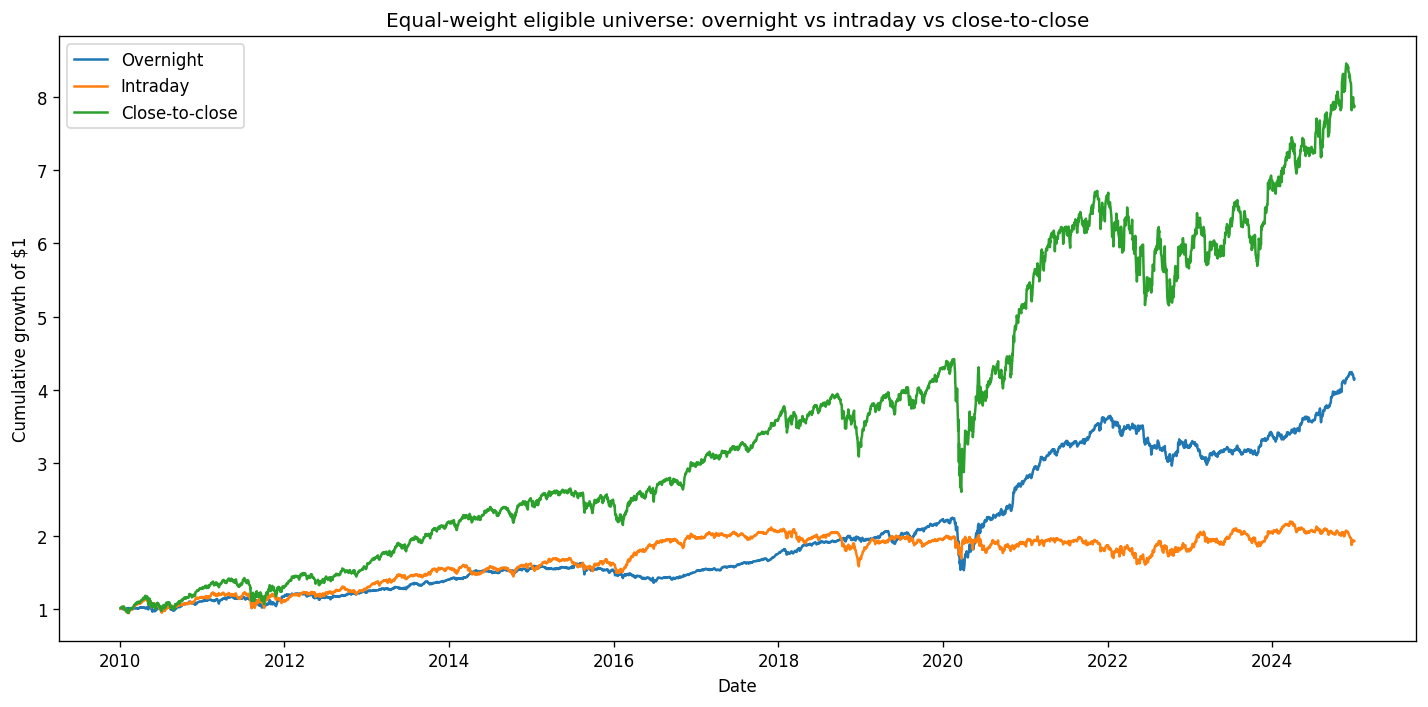

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(stylised_daily["date"], 1 + stylised_daily["cum_overnight"], label="Overnight")
ax.plot(stylised_daily["date"], 1 + stylised_daily["cum_intraday"], label="Intraday")
ax.plot(stylised_daily["date"], 1 + stylised_daily["cum_close_to_close"], label="Close-to-close")
ax.set_title("Equal-weight eligible universe: overnight vs intraday vs close-to-close")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative growth of $1")
ax.legend()
save_and_show(fig, STEP1_FIG_DIR / "fig_step1_stylised_fact_cumulative_returns.png")


## 7. Save Outputs for Subsequent Steps




In [15]:
# Save Step 1 outputs for subsequent steps.
sp500_tr = pd.read_parquet(DATA_DIR / "sp500_tr.parquet")
sp500_tr["date"] = pd.to_datetime(sp500_tr["date"]).dt.normalize()
sp500_tr = sp500_tr[sp500_tr["date"] <= DEV_END].sort_values("date").copy()
sp500_tr["benchmark_return"] = sp500_tr["adjusted_close"].pct_change()
assert_cutoff(sp500_tr, name="SP500_TR")

panel.to_parquet(out_path("c2o_step1_clean_panel.parquet"), index=False)
universe_map.to_parquet(out_path("c2o_step1_yearly_universe_map.parquet"), index=False)
earnings.to_parquet(out_path("c2o_step1_earnings_processed.parquet"), index=False)
short_interest_daily.to_parquet(out_path("c2o_step1_short_interest_daily.parquet"), index=False)
tdays.to_parquet(out_path("c2o_step1_trading_days.parquet"), index=False)
sp500_tr.to_parquet(out_path("c2o_step1_sp500_tr_clipped.parquet"), index=False)
recon_table.to_csv(out_path("c2o_step1_return_reconciliation.csv"), index=False)
strict_target_audit.to_csv(out_path("step1_strict_overnight_target_audit.csv"), index=False)
universe_sanity.to_csv(out_path("c2o_step1_universe_sanity_by_year.csv"), index=False)
mcap_universe_audit.to_csv(out_path("step1_yearly_mcap_universe_audit.csv"), index=False)
step2_mcap_fail_audit.to_csv(out_path("step2_mcap_fail_audit.csv"), index=False)
earnings_timing_diag.to_csv(out_path("c2o_step1_earnings_timing_diagnostics.csv"), index=False)
si_coverage_by_year.to_csv(out_path("c2o_step1_short_interest_coverage_by_year.csv"), index=False)
si_no_lookahead_summary.to_csv(out_path("c2o_step1_short_interest_no_lookahead_audit.csv"), index=False)
stylised_summary.to_csv(out_path("step1_stylised_fact_summary.csv"), index=False)
stylised_yearly.to_csv(out_path("step1_stylised_fact_yearly.csv"), index=False)
stylised_daily.to_csv(out_path("step1_stylised_fact_ew_daily_returns.csv"), index=False)
print("Saved Step 1 outputs to", OUT_DIR.resolve())


Saved Step 1 outputs to /Users/cuiyufan/Desktop/ml data/c2o_outputs


In [16]:
# Auto-generated Step 1 summary.
display(pd.DataFrame({"object": ["panel", "universe_map", "earnings", "short_interest_daily", "sp500_tr"], "rows": [len(panel), len(universe_map), len(earnings), len(short_interest_daily), len(sp500_tr)]}))
print("Step 1 generated files:")
for f in sorted(set(generated_files)):
    if "step1" in Path(f).name or Path(f).name.startswith("c2o_step1"):
        print(f)
print("Step 1 displayed figures:")
for f in displayed_figure_files:
    if "/step1/" in f:
        print(f)


,object,rows
0,panel,5292106
1,universe_map,15000
2,earnings,60922
3,short_interest_daily,3773971
4,sp500_tr,6295


Step 1 generated files:
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_clean_panel.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_earnings_processed.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_earnings_timing_diagnostics.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_return_reconciliation.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_short_interest_coverage_by_year.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_short_interest_daily.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_short_interest_no_lookahead_audit.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_sp500_tr_clipped.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_trading_days.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_universe_sanity_by_year.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_yearly_universe_map.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/step1_strict_overnight_targe

# C2O — Step 2: Capacity-Aware Universe

This notebook builds the Step 2 preliminary eligibility table. Starting from the Step 1 yearly frozen top-1000 universe, we apply daily tradability filters at each AUM level. Each row is one (stock, date, AUM) observation.

**Main tasks:**

1. Load Step 1 outputs
2. Compute base features (all aligned to t−1)
3. Apply AUM-specific preliminary capacity checks
4. Assign one of seven eligibility labels per row
5. Export diagnostics and final outputs

Rows labelled OK form the preliminary tradable universe; the final 5% ADV cap is re-enforced in Step 5.


## 1. Load Step 1 Outputs

### 1.1 Load Input

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
AUM_ORDER = ["50m", "250m", "1b"]
print("Step 2 uses Step 1 eligible universe as base; market-cap/history exclusions are recorded separately, not as daily Step 2 reasons.")

Step 2 uses Step 1 eligible universe as base; market-cap/history exclusions are recorded separately, not as daily Step 2 reasons.


In [18]:
panel = pd.read_parquet(OUT_DIR / "c2o_step1_clean_panel.parquet")
earnings = pd.read_parquet(OUT_DIR / "c2o_step1_earnings_processed.parquet")
tdays = pd.read_parquet(OUT_DIR / "c2o_step1_trading_days.parquet")
for df in [panel, earnings, tdays]:
    for c in df.columns:
        if "date" in c and not pd.api.types.is_bool_dtype(df[c]):
            # Convert actual date-like columns only; audit booleans such as *_is_trading_day stay boolean.
            df[c] = pd.to_datetime(df[c])
assert_cutoff(panel, name="Step2 panel")
display(panel.head())


,ticker,instrument_id,date,year,open,high,low,close,adjusted_close,adj_open,volume,market_cap,r_on,r_id,r_cc,target_next_overnight,expected_next_trading_day,next_date,next_adj_open,is_strict_one_overnight_target,eligible,universe_asof_date,universe_entry_date,universe_rank
0,HLT,1,2013-12-12,2013,21.2969,21.9168,21.2469,21.4968,41.6951,41.307375,23716568.0,2.116608e+10,NaN,0.009386,NaN,0.022795,2013-12-13,2013-12-13,42.645538,True,False,NaT,NaT,NaN
1,HLT,1,2013-12-13,2013,21.9868,22.3767,21.5468,22.0967,42.8587,42.645538,3984417.0,2.175675e+10,0.022795,0.004998,0.027907,0.046608,2013-12-16,2013-12-16,44.856262,True,False,NaT,NaT,NaN
2,HLT,1,2013-12-16,2013,23.1266,25.9462,21.5168,21.5168,41.7339,44.856262,3226908.0,2.118577e+10,0.046608,-0.069608,-0.026244,0.004181,2013-12-17,2013-12-17,41.908382,True,False,NaT,NaT,NaN
3,HLT,1,2013-12-17,2013,21.6068,21.9868,21.5768,21.8068,42.2963,41.908382,1584449.0,2.147131e+10,0.004181,0.009256,0.013476,0.000917,2013-12-18,2013-12-18,42.335100,True,False,NaT,NaT,NaN
4,HLT,1,2013-12-18,2013,21.8268,22.1767,21.6568,21.8268,42.3351,42.335100,1955194.0,2.149100e+10,0.000917,0.000000,0.000917,-0.003663,2013-12-19,2013-12-19,42.180008,True,False,NaT,NaT,NaN


### 1.2 Keep only eligible == True rows as the Step 2 base pool

According to Brief §2.2, Step 1 defines the yearly frozen top-1000 universe.  

Step 2 is run only on rows with `eligible == True`. Therefore, the main Step 2 table focuses on daily tradability and preliminary capacity screens, rather than re-labelling stocks outside the annual universe. Stock-days outside the Step 1 universe are excluded before Step 2 and are reported separately in the market-cap/history audit output.

In [19]:
# Defensive dedup at Step 2 entry.
panel_elig = panel[panel["eligible"]].drop_duplicates(["date", "instrument_id"]).sort_values(["instrument_id", "date"]).copy()
assert panel_elig.duplicated(["date", "instrument_id"]).sum() == 0
print(f"Step 2 base eligible stock-days: {len(panel_elig):,}")

Step 2 base eligible stock-days: 3,773,971


## 2. Compute Base Features

### 2.1 ADV20 — Average daily volume with rolling 20-day

ADV20 = trailing 20-day mean of volume × close, expressed in dollars.

This is used as one proxy of liquidity, and we choose raw close × raw share volume to approximate actual traded dollar volume. As for adjusted prices, they are used for return construction in Step 1, not for dollar-volume capacity.

After `.shift(1)`, the ADV20 on date t uses the 20 days from t-20 through t-1.

In [20]:
panel_elig["dollar_volume_lag1"] = (panel_elig["volume"] * panel_elig["close"]).groupby(panel_elig["instrument_id"]).shift(1)
g = panel_elig.groupby("instrument_id", group_keys=False)
panel_elig["adv20_dollar"] = g["dollar_volume_lag1"].transform(lambda x: x.rolling(20, min_periods=20).mean())
display(panel_elig["adv20_dollar"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).to_frame())


,adv20_dollar
count,3.745611e+06
mean,6.223782e+08
std,7.667987e+09
min,0.000000e+00
1%,1.775110e+06
5%,5.754875e+06
50%,6.973282e+07
95%,7.925687e+08
99%,6.145879e+09
max,5.434365e+11


### 2.2 Realized Volatility — Rolling 20-Day Annualised

Daily vol = rolling 20-day std of r_cc.

In [21]:
panel_elig["vol20_daily"] = g["r_cc"].transform(lambda x: x.shift(1).rolling(20, min_periods=20).std())
panel_elig["vol20_ann"] = panel_elig["vol20_daily"] * np.sqrt(TRADING_DAYS_PER_YEAR)
display(panel_elig["vol20_ann"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).to_frame())


,vol20_ann
count,3.745611e+06
mean,2.991878e-01
std,1.830863e-01
min,0.000000e+00
1%,9.355599e-02
5%,1.235843e-01
50%,2.542053e-01
95%,6.200419e-01
99%,9.917333e-01
max,4.615213e+00


### 2.3 Price-for-Filter — Lagged Close

Note: Each stock's first day has price_for_filter = NaN, and treated as PRICE_FAIL.

In [22]:
panel_elig["price_lag1"] = g["close"].shift(1)
assert panel_elig["price_lag1"].notna().any(), "price_lag1 failed to compute."


### 2.4 Roll Spread Estimator (Diagnostic)

The Roll spread proxy is computed as a liquidity diagnostic. It is not used as a hard filter; final tradability is still governed by ADV20, price, volatility, earnings exclusion, and the Step 5 position-level 5% ADV cap.


/var/folders/mn/7_dn1rdx68l7sx6yf5h6661c0000gn/T/ipykernel_54893/823886045.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel_elig["roll_cov_60d"] = g.apply(lambda d: d["r_cc"].rolling(60, min_periods=40).cov(d["r_cc_lag1_for_roll"])).reset_index(level=0, drop=True)


,roll_spread_proxy
count,2.881365e+06
mean,7.255324e-03
std,9.791339e-03
min,0.000000e+00
1%,0.000000e+00
5%,0.000000e+00
25%,0.000000e+00
50%,4.762932e-03
75%,1.124545e-02
95%,2.408875e-02


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step2/fig_step2_roll_spread_proxy_distribution.png


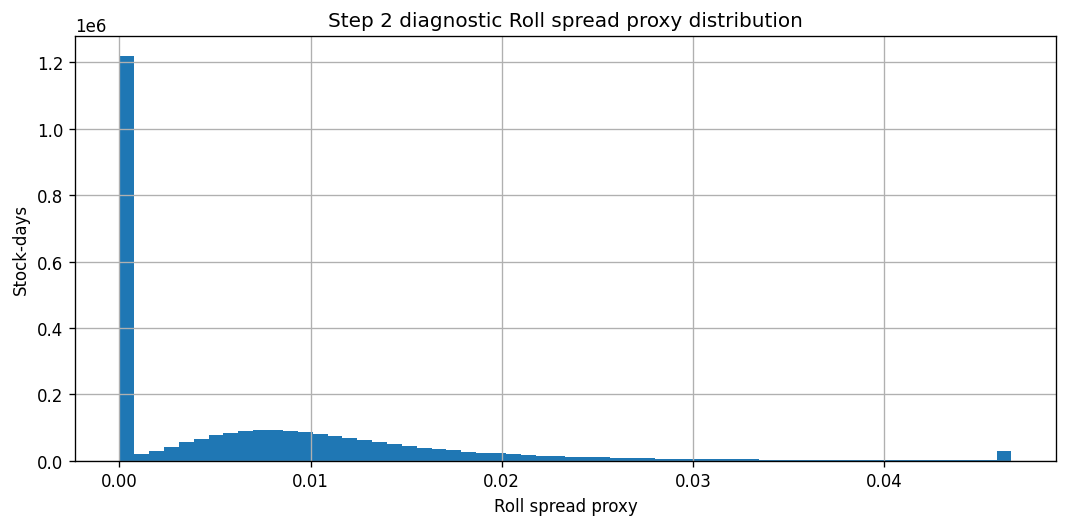

In [23]:
panel_elig["r_cc_lag1_for_roll"] = g["r_cc"].shift(1)
panel_elig["roll_cov_60d"] = g.apply(lambda d: d["r_cc"].rolling(60, min_periods=40).cov(d["r_cc_lag1_for_roll"])).reset_index(level=0, drop=True)
panel_elig["roll_spread_proxy"] = 2.0 * np.sqrt(np.maximum(-panel_elig["roll_cov_60d"], 0.0))
roll_spread_summary = panel_elig["roll_spread_proxy"].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_frame("roll_spread_proxy")
display(roll_spread_summary)
fig, ax = plt.subplots(figsize=(9,4.5))
panel_elig["roll_spread_proxy"].dropna().clip(upper=panel_elig["roll_spread_proxy"].quantile(0.99)).hist(bins=60, ax=ax)
ax.set_title("Step 2 diagnostic Roll spread proxy distribution")
ax.set_xlabel("Roll spread proxy")
ax.set_ylabel("Stock-days")
save_and_show(fig, STEP2_FIG_DIR / "fig_step2_roll_spread_proxy_distribution.png")


### 2.5 Earnings Window Flag

For a close-to-next-open strategy, the exclusion window is centered on the decision date whose overnight position crosses the earnings announcement: `previous_trading_day(effective_date)`.


In [24]:
# The centre of the exclusion window is the decision date whose overnight crosses earnings.
tday_to_pos = pd.Series(np.arange(len(tdays)), index=pd.DatetimeIndex(tdays["date"]))
earn_base = earnings[["stock_id", "reporting_date", "effective_date", "earnings_crossing_decision_date", "earnings_time_source"]].rename(columns={"stock_id":"instrument_id"}).dropna(subset=["instrument_id", "effective_date", "earnings_crossing_decision_date"]).copy()
earn_base["cross_pos"] = earn_base["earnings_crossing_decision_date"].map(tday_to_pos)
earn_flags = []
for offset in range(-EARNINGS_EXCLUSION_DAYS, EARNINGS_EXCLUSION_DAYS + 1):
    tmp = earn_base.copy(); tmp["exclude_pos"] = tmp["cross_pos"] + offset
    tmp = tmp[tmp["exclude_pos"].between(0, len(tdays)-1)].copy()
    tmp["date"] = pd.DatetimeIndex(tdays["date"])[tmp["exclude_pos"].astype(int)]
    tmp["earnings_window_offset"] = offset
    earn_flags.append(tmp[["instrument_id", "date", "reporting_date", "effective_date", "earnings_crossing_decision_date", "earnings_time_source", "earnings_window_offset"]])
earn_flags = pd.concat(earn_flags, ignore_index=True).drop_duplicates(["instrument_id", "date"])
earn_flags["in_earnings_window"] = True
panel_elig = panel_elig.merge(earn_flags[["instrument_id", "date", "in_earnings_window"]], on=["instrument_id", "date"], how="left")
panel_elig["in_earnings_window"] = panel_elig["in_earnings_window"].eq(True)
earn_window_yearly = panel_elig.assign(year=panel_elig["date"].dt.year).groupby("year").agg(stock_days=("instrument_id","size"), earnings_window_stock_days=("in_earnings_window","sum")).reset_index()
earn_window_yearly["earnings_window_share"] = earn_window_yearly["earnings_window_stock_days"] / earn_window_yearly["stock_days"]
display(earn_flags.head(12)); display(earn_window_yearly)


,instrument_id,date,reporting_date,effective_date,earnings_crossing_decision_date,earnings_time_source,earnings_window_offset,in_earnings_window
0,1,2014-02-25,2014-02-27,2014-02-27,2014-02-26,explicit_bmo_amc,-1,True
1,1,2014-05-07,2014-05-09,2014-05-09,2014-05-08,explicit_bmo_amc,-1,True
2,1,2014-07-30,2014-08-01,2014-08-01,2014-07-31,explicit_bmo_amc,-1,True
3,1,2014-10-29,2014-10-31,2014-10-31,2014-10-30,explicit_bmo_amc,-1,True
4,1,2015-02-13,2015-02-18,2015-02-18,2015-02-17,explicit_bmo_amc,-1,True
5,1,2015-04-27,2015-04-29,2015-04-29,2015-04-28,explicit_bmo_amc,-1,True
6,1,2015-07-27,2015-07-29,2015-07-29,2015-07-28,explicit_bmo_amc,-1,True
7,1,2015-10-26,2015-10-28,2015-10-28,2015-10-27,explicit_bmo_amc,-1,True
8,1,2016-02-24,2016-02-26,2016-02-26,2016-02-25,explicit_bmo_amc,-1,True
9,1,2016-04-25,2016-04-27,2016-04-27,2016-04-26,explicit_bmo_amc,-1,True


,year,stock_days,earnings_window_stock_days,earnings_window_share
0,2010,252000,3228,0.012810
1,2011,251999,5663,0.022472
2,2012,249999,5359,0.021436
3,2013,251999,4687,0.018599
4,2014,252000,5798,0.023008
5,2015,251998,9178,0.036421
6,2016,251998,9492,0.037667
7,2017,251000,9755,0.038865
8,2018,250999,10048,0.040032
9,2019,251995,10281,0.040798


## 3. Per-AUM Capacity and Eligibility

**Priority order:** `MISSING_DATA` → `PRICE_FAIL` → `ADV_ABSOLUTE_FAIL` → `ADV_CAPACITY_FAIL` → `VOL_FAIL` → `EARN_WINDOW` → `OK`.

The year-start market-cap universe is inherited from Step 1’s frozen top-1000 universe. Step 2 is therefore constructed conditional on eligible == True, and the main Step 2 table does not re-label stocks outside the annual universe as a daily market-cap failure.

Within Step 2, each eligible stock-day is expanded across the three AUM levels. For each (date, instrument_id, aum_level) row, we compute a preliminary target position equal to `aum_dollar / ASSUMED_N_NAMES`, an ADV-based notional cap equal to `adv20_dollar × PARTICIPATION_CAP`, and a preliminary capacity ratio equal to the ADV cap divided by the assumed target position.

The preliminary eligibility reason is assigned using a first-fail priority rule. Rows with missing required inputs are labelled MISSING_DATA. Among non-missing rows, the first binding reason is then selected in the order: price floor, absolute ADV floor, preliminary AUM-dependent capacity test, realised-volatility band, and earnings-window exclusion. Rows that pass all filters are labelled OK and marked as is_prelim_tradable = True.


In [25]:
base = panel_elig[["date", "year", "instrument_id", "ticker", "close", "market_cap", "target_next_overnight", "expected_next_trading_day", "next_date", "next_adj_open", "is_strict_one_overnight_target", "adv20_dollar", "vol20_daily", "vol20_ann", "price_lag1", "roll_spread_proxy", "in_earnings_window"]].copy()
elig_parts = []
for aum_level, aum in AUM_LEVELS.items():
    df = base.copy()
    df["aum_level"] = aum_level; df["aum_dollar"] = aum
    df["assumed_n_names"] = ASSUMED_N_NAMES
    df["prelim_target_position_dollar"] = aum / ASSUMED_N_NAMES
    df["adv_cap_notional"] = df["adv20_dollar"] * PARTICIPATION_CAP
    df["prelim_capacity_ratio"] = df["adv_cap_notional"] / df["prelim_target_position_dollar"]
    missing = df[["adv20_dollar", "vol20_ann", "price_lag1"]].isna().any(axis=1)
    conds = [missing, df["price_lag1"] < MIN_PRICE, df["adv20_dollar"] < ADV_ABSOLUTE_FLOOR, df["prelim_capacity_ratio"] < MIN_CAPACITY_RATIO, (df["vol20_ann"] < VOL_MIN_ANNUALISED) | (df["vol20_ann"] > VOL_MAX_ANNUALISED), df["in_earnings_window"]]
    reasons = ["MISSING_DATA", "PRICE_FAIL", "ADV_ABSOLUTE_FAIL", "ADV_CAPACITY_FAIL", "VOL_FAIL", "EARN_WINDOW"]
    df["prelim_eligibility_reason"] = np.select(conds, reasons, default="OK")
    df["is_prelim_tradable"] = df["prelim_eligibility_reason"].eq("OK")
    df["prelim_cap_binding"] = df["prelim_capacity_ratio"].between(MIN_CAPACITY_RATIO, 1.0, inclusive="left")
    elig_parts.append(df)
step2 = pd.concat(elig_parts, ignore_index=True)
assert step2.duplicated(["date", "instrument_id", "aum_level"]).sum() == 0
display(step2.groupby(["aum_level", "prelim_eligibility_reason"]).size().reset_index(name="n_rows"))


,aum_level,prelim_eligibility_reason,n_rows
0,1b,ADV_ABSOLUTE_FAIL,148518
1,1b,ADV_CAPACITY_FAIL,772437
2,1b,EARN_WINDOW,100507
3,1b,MISSING_DATA,28360
4,1b,OK,2704221
5,1b,PRICE_FAIL,18156
6,1b,VOL_FAIL,1772
7,250m,ADV_ABSOLUTE_FAIL,148518
8,250m,ADV_CAPACITY_FAIL,50359
9,250m,EARN_WINDOW,124027


**Notes on filter reasons.**

1. We separate ADV_ABSOLUTE_FAIL from ADV_CAPACITY_FAIL to distinguish two different liquidity problems. `ADV_ABSOLUTE_FAIL` captures stocks whose ADV is too low in absolute terms, while `ADV_CAPACITY_FAIL` captures stocks whose 5% ADV capacity cannot cover the minimum required share of the assumed preliminary target position.

2. We set `MIN_CAPACITY_RATIO = 0.25` as a relaxed Step 2 screening threshold: stocks below this level are excluded at the preliminary universe stage, while the binding 5% ADV position cap is enforced later during the actual Step 5 portfolio construction.

## 4. Coursework Brief Step 2 Questions

### 4.1 Year-Level AUM Monotonicity Check


In [26]:
year_aum_counts = step2.groupby(["date", "aum_level"])["is_prelim_tradable"].sum().unstack("aum_level")
for c in AUM_ORDER:
    if c not in year_aum_counts.columns: year_aum_counts[c] = np.nan
year_aum_counts = year_aum_counts[AUM_ORDER].reset_index()
year_aum_counts["monotonic_pass"] = (year_aum_counts["50m"] >= year_aum_counts["250m"]) & (year_aum_counts["250m"] >= year_aum_counts["1b"])
monotonic_violations = year_aum_counts[~year_aum_counts["monotonic_pass"]]
aum_monotonicity_check = pd.DataFrame({"check":["50m_count_ge_250m_ge_1b_by_date"], "passed":[monotonic_violations.empty], "violation_rows":[len(monotonic_violations)]})
display(aum_monotonicity_check)
assert monotonic_violations.empty


,check,passed,violation_rows
0,50m_count_ge_250m_ge_1b_by_date,True,0


### 4.2 Q1 — Threshold Summary

Q1 asks: "What thresholds do you set on dollar volume, market capitalisation at year-start, price per share, realised volatility, and the earnings window? Justify each numerically."

In [27]:
config_summary = pd.DataFrame({"parameter": ["ASSUMED_N_NAMES", "MIN_CAPACITY_RATIO", "PARTICIPATION_CAP", "ADV_ABSOLUTE_FLOOR", "MIN_PRICE"], "value": [ASSUMED_N_NAMES, MIN_CAPACITY_RATIO, PARTICIPATION_CAP, ADV_ABSOLUTE_FLOOR, MIN_PRICE]})
display(config_summary)
capacity_rows=[]
for th in [0.0,0.10,0.25,0.50,1.00]:
    for aum_level,aum in AUM_LEVELS.items():
        prelim_target=aum/ASSUMED_N_NAMES
        cap_ratio=(base["adv20_dollar"]*PARTICIPATION_CAP)/prelim_target
        base_ok=base["price_lag1"].ge(MIN_PRICE)&base["adv20_dollar"].ge(ADV_ABSOLUTE_FLOOR)&base["vol20_ann"].between(VOL_MIN_ANNUALISED,VOL_MAX_ANNUALISED)&(~base["in_earnings_window"])&base[["adv20_dollar","vol20_ann","price_lag1"]].notna().all(axis=1)
        ok=base_ok&cap_ratio.ge(th)
        capacity_rows.append({"capacity_ratio_threshold":th,"aum_level":aum_level,"eligible_names_mean_daily":base.loc[ok].groupby("date")["instrument_id"].nunique().mean(),"eligible_stock_days":int(ok.sum()),"percentage_retained":float(ok.mean())})
step2_capacity_threshold_sensitivity=pd.DataFrame(capacity_rows)
display(step2_capacity_threshold_sensitivity)


,parameter,value
0,ASSUMED_N_NAMES,200.00
1,MIN_CAPACITY_RATIO,0.25
2,PARTICIPATION_CAP,0.05
3,ADV_ABSOLUTE_FLOOR,5000000.00
4,MIN_PRICE,5.00


,capacity_ratio_threshold,aum_level,eligible_names_mean_daily,eligible_stock_days,percentage_retained
0,0.00,50m,919.451252,3451620,0.914586
1,0.00,250m,919.451252,3451620,0.914586
2,0.00,1b,919.451252,3451620,0.914586
3,0.10,50m,919.451252,3451620,0.914586
4,0.10,250m,919.451252,3451620,0.914586
5,0.10,1b,866.695791,3253576,0.862109
6,0.25,50m,919.451252,3451620,0.914586
7,0.25,250m,906.388386,3402582,0.901592
8,0.25,1b,720.357219,2704221,0.716545
9,0.50,50m,919.451252,3451620,0.914586


### 4.3 Q2 — Impact at Cap by Market-Cap Tercile

Q2 asks: "What participation cap do you assume in the closing auction, and what is the implied slippage at that cap for a typical mid-cap and a typical large-cap name in your universe?"

We define the tercile as a typical way to split cap. Each trading day, we rank eligible names by market_cap percentile and slice into three terciles (small / mid / large). For each tercile, take the median daily vol and feed it through the impact formula.

In [28]:
# Impact at cap by volatility bucket: diagnostic only, not a PnL cost add-on.
impact_k = 0.7
vol_buckets = pd.Series([0.01, 0.02, 0.03], name="sigma_daily")
impact_at_cap = pd.DataFrame({"sigma_daily": vol_buckets})
impact_at_cap["participation_fraction"] = PARTICIPATION_CAP
impact_at_cap["square_root_impact_bps"] = impact_k * impact_at_cap["sigma_daily"] * np.sqrt(PARTICIPATION_CAP) * 1e4
impact_at_cap["fixed_round_trip_slippage_bps"] = 2 * AUCTION_SLIPPAGE_BPS_PER_LEG
display(impact_at_cap)


,sigma_daily,participation_fraction,square_root_impact_bps,fixed_round_trip_slippage_bps
0,0.01,0.05,15.652476,3.0
1,0.02,0.05,31.304952,3.0
2,0.03,0.05,46.957428,3.0


In [29]:
# Q2 — impact at 5% cap by market-cap tercile.
# implied slippage. Tercile is rank-based on lagged market_cap.

q2_base = panel_elig.copy()

q2_base["market_cap_lag1"] = (
    q2_base.sort_values(["instrument_id", "date"])
           .groupby("instrument_id")["market_cap"]
           .shift(1)
)

mcap_rank = q2_base.groupby("date")["market_cap_lag1"].rank(pct=True)

q2_base["mcap_tercile"] = pd.cut(
    mcap_rank,
    bins=[0, 1/3, 2/3, 1],
    labels=["small", "mid", "large"],
    include_lowest=True,
)

typical_sigma = q2_base.groupby("mcap_tercile", observed=True)["vol20_daily"].median()

q2_tercile_table = pd.DataFrame({
    "median_daily_vol": typical_sigma,
    "participation_fraction": PARTICIPATION_CAP,
})

q2_tercile_table["impact_bps_at_5pct_cap"] = (
    q2_tercile_table["median_daily_vol"]
    * impact_k
    * np.sqrt(PARTICIPATION_CAP)
    * 1e4
)

q2_tercile_table = q2_tercile_table.round({
    "median_daily_vol": 6,
    "participation_fraction": 4,
    "impact_bps_at_5pct_cap": 2,
})

print("Coursework Brief §3 Q2 — Impact at 5% cap by market-cap tercile:")
display(q2_tercile_table)

Coursework Brief §3 Q2 — Impact at 5% cap by market-cap tercile:


,median_daily_vol,participation_fraction,impact_bps_at_5pct_cap
mcap_tercile,,,
small,0.018053,0.05,28.26
mid,0.016072,0.05,25.16
large,0.014138,0.05,22.13


### 4.4 Q3 — Universe Evolution by Year × AUM

Q3 asks: "How does the eligible set evolve through 2010–2024 at each of the three portfolio-AUM levels you must report (50M, 250M, 1B)?"

In [30]:
AUM_ORDER = ["50m", "250m", "1b"]
universe_evolution = step2.groupby(["year", "aum_level"])["is_prelim_tradable"].mean().reset_index(name="tradable_stock_day_share")
display(universe_evolution)


,year,aum_level,tradable_stock_day_share
0,2010,1b,0.490179
1,2010,250m,0.721829
2,2010,50m,0.755766
3,2011,1b,0.553879
4,2011,250m,0.816142
5,2011,50m,0.848341
6,2012,1b,0.547830
7,2012,250m,0.818855
8,2012,50m,0.850139
9,2013,1b,0.588697


Brief §3 Q3 — Average daily preliminarily tradable names by year and AUM:


aum_level,50M AUM,250M AUM,1B AUM
year,,,
2010,820.9,784.1,532.4
2011,848.3,816.1,553.9
2012,850.1,818.9,547.8
2013,890.9,858.0,588.7
2014,928.9,906.8,642.6
2015,936.1,922.0,677.0
2016,934.5,923.0,695.2
2017,941.9,933.9,730.7
2018,946.7,944.3,787.4


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step2/step2_q3_avg_daily_tradable_names_by_aum.png


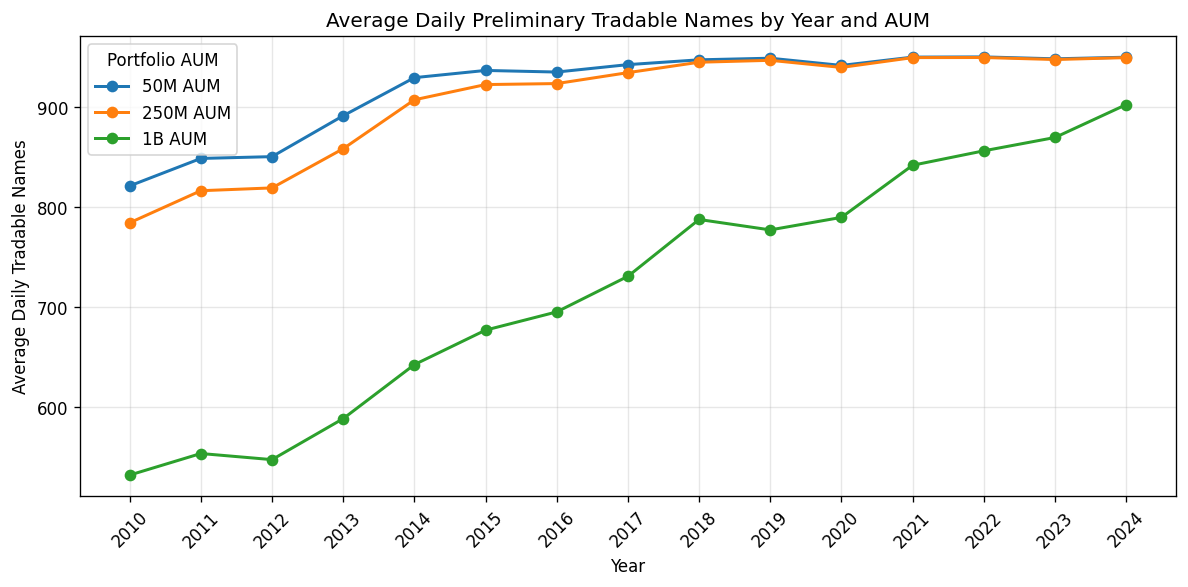

In [31]:
# Q3 — evolution of the preliminary tradable universe by AUM

AUM_ORDER = ["50m", "250m", "1b"]

# Memory-conscious: take only the 5 columns Q3 actually needs
q3_subset = step2[["year", "date", "aum_level", "instrument_id", "is_prelim_tradable"]]

daily_tradable_counts = (
    q3_subset.loc[q3_subset["is_prelim_tradable"]]
             .groupby(["year", "date", "aum_level"])["instrument_id"]
             .nunique()
             .reset_index(name="n_tradable_names")
)
universe_evol_avg = (
    daily_tradable_counts
    .groupby(["year", "aum_level"])["n_tradable_names"]
    .mean()
    .reset_index(name="avg_daily_tradable_names")
)

universe_evolution = (
    q3_subset.groupby(["year", "aum_level"])["is_prelim_tradable"]
             .mean()
             .reset_index(name="tradable_stock_day_share")
)
del q3_subset

q3_table = (
    universe_evol_avg
    .pivot(index="year", columns="aum_level", values="avg_daily_tradable_names")
    .reindex(columns=AUM_ORDER)
    .rename(columns={"50m": "50M AUM", "250m": "250M AUM", "1b": "1B AUM"})
    .round(1)
)
print("Brief §3 Q3 — Average daily preliminarily tradable names by year and AUM:")
display(q3_table)

fig, ax = plt.subplots(figsize=(10, 5))
for col in q3_table.columns:
    ax.plot(q3_table.index, q3_table[col], linewidth=1.8, marker="o", label=col)
ax.set_title("Average Daily Preliminary Tradable Names by Year and AUM")
ax.set_xlabel("Year")
ax.set_ylabel("Average Daily Tradable Names")
ax.set_xticks(q3_table.index)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(title="Portfolio AUM")
save_and_show(fig, STEP2_FIG_DIR / "step2_q3_avg_daily_tradable_names_by_aum.png", dpi=300)

### 4.5 Q4 — Binding Constraint Distribution by Year × AUM

Q4 asks: "4. What is the binding-constraint distribution? Provide a table by year of how many stock-days are excluded by each reason."

In [32]:
AUM_ORDER = ["50m", "250m", "1b"]
reason_summary = step2.groupby(["year", "aum_level", "prelim_eligibility_reason"]).size().unstack(fill_value=0).reset_index()
for reason in ["OK", "MISSING_DATA", "PRICE_FAIL", "ADV_ABSOLUTE_FAIL", "ADV_CAPACITY_FAIL", "VOL_FAIL", "EARN_WINDOW"]:
    if reason not in reason_summary.columns: reason_summary[reason] = 0
reason_summary["total_stock_days"] = reason_summary[["OK", "MISSING_DATA", "PRICE_FAIL", "ADV_ABSOLUTE_FAIL", "ADV_CAPACITY_FAIL", "VOL_FAIL", "EARN_WINDOW"]].sum(axis=1)
display(reason_summary.head(20))


prelim_eligibility_reason,year,aum_level,ADV_ABSOLUTE_FAIL,ADV_CAPACITY_FAIL,EARN_WINDOW,MISSING_DATA,OK,PRICE_FAIL,VOL_FAIL,total_stock_days
0,2010,1b,36037,67790,1616,20000,123525,3032,0,252000
1,2010,250m,36037,8676,2354,20000,181901,3032,0,252000
2,2010,50m,36037,0,2478,20000,190453,3032,0,252000
3,2011,1b,30300,75920,3103,480,139577,2599,20,251999
4,2011,250m,30300,8317,4616,480,205667,2599,20,251999
5,2011,50m,30300,0,4819,480,213781,2599,20,251999
6,2012,1b,28965,77215,2942,580,136957,3322,18,249999
7,2012,250m,28965,7980,4384,580,204713,3322,55,249999
8,2012,50m,28965,0,4543,580,212534,3322,55,249999
9,2013,1b,20910,77535,2763,640,148351,1760,40,251999


In [33]:
# Independent VOL_FAIL flag rate by year × AUM.
vol_fail = step2.assign(vol_fail=((step2["vol20_ann"] < VOL_MIN_ANNUALISED) | (step2["vol20_ann"] > VOL_MAX_ANNUALISED))).groupby(["year", "aum_level"])["vol_fail"].mean().reset_index()
display(vol_fail.head())


,year,aum_level,vol_fail
0,2010,1b,0.000298
1,2010,250m,0.000298
2,2010,50m,0.000298
3,2011,1b,0.000290
4,2011,250m,0.000290


In [34]:
# Independent EARN_WINDOW flag rate by year × AUM.
earn_fail = step2.groupby(["year", "aum_level"])["in_earnings_window"].mean().reset_index(name="earn_window_share")
display(earn_fail.head())


,year,aum_level,earn_window_share
0,2010,1b,0.012810
1,2010,250m,0.012810
2,2010,50m,0.012810
3,2011,1b,0.022472
4,2011,250m,0.022472


## 5. Save Outputs

In [35]:
# Final cutoff assertion and save Step 2 outputs.
assert_cutoff(step2, name="step2")
step2.to_parquet(out_path("c2o_step2_prelim_tradable_universe.parquet"), index=False)
roll_spread_summary.to_csv(out_path("step2_roll_spread_proxy_summary.csv"))
step2_capacity_threshold_sensitivity.to_csv(out_path("step2_capacity_threshold_sensitivity.csv"), index=False)
aum_monotonicity_check.to_csv(out_path("c2o_step2_aum_monotonicity_check.csv"), index=False)
earn_window_yearly.to_csv(out_path("c2o_step2_earnings_window_exclusion_by_year.csv"), index=False)
earn_flags.to_csv(out_path("c2o_step2_earnings_exclusion_sample_source.csv"), index=False)
reason_summary.to_csv(out_path("c2o_step2_eligibility_reason_summary.csv"), index=False)
universe_evolution.to_csv(out_path("c2o_step2_tradable_count_by_year_aum.csv"), index=False)
config_summary.to_csv(out_path("c2o_step2_config_summary.csv"), index=False)
impact_at_cap.to_csv(out_path("c2o_step2_impact_at_cap.csv"), index=False)
q2_tercile_table.reset_index().to_csv(out_path("c2o_step2_q2_impact_at_cap_by_mcap_tercile.csv"), index=False)
vol_fail.to_csv(out_path("c2o_step2_vol_fail_rate_by_year_aum.csv"), index=False)
earn_fail.to_csv(out_path("c2o_step2_earn_window_rate_by_year_aum.csv"), index=False)
print("Saved Step 2 outputs to", OUT_DIR.resolve())


Saved Step 2 outputs to /Users/cuiyufan/Desktop/ml data/c2o_outputs


# C2O — Step 3: Filtering the short leg for borrow cost

This step implements Coursework Brief Section 4: from daily short-interest data, build a per-(stock, date) hard-to-borrow proxy and assign each name a borrow tier A / B / C. Step 5 will use the tier to charge daily borrow cost on every short position, under the fixed cost schedule (A = 40 bps, B = 200 bps, C = 800 bps p.a.).

We use a deterministic short-interest percentile rule for borrow-cost tiers. The optional ML hard-to-borrow rule is disabled to avoid unnecessary complexity and overfitting-looking decisions.

The final output `c2o_step3_borrow_tiers.parquet` contains point-in-time borrow tier, borrow cost, short-interest availability fields, and diagnostics fields needed by Step 4 and Step 5.

Notes:

  1. The headline borrow-cost logic is deterministic and cross-sectional by date.
  2. Short-interest inputs use the source-provided availability date from `short_interest_transfo.parquet`; no extra publication lag is applied.
  3. Missing short interest is conservatively retained and defaults to Tier A, with `si_missing=True` kept for audit and robustness reporting.


## 1. Load Inputs

In [36]:
import os
print("Step 3 uses deterministic simple borrow tiers")

Step 3 uses deterministic simple borrow tiers


In [37]:
si = pd.read_parquet(OUT_DIR / "c2o_step1_short_interest_daily.parquet")
step2 = pd.read_parquet(OUT_DIR / "c2o_step2_prelim_tradable_universe.parquet")
for df in [si, step2]:
    for c in df.columns:
        if "date" in c:
            df[c] = pd.to_datetime(df[c])
assert_cutoff(si, name="short_interest_daily")
assert_cutoff(step2, name="step2")
display(si.head())


,date,instrument_id,ticker,previous_trading_day,si_source_available_date,si_snapshot_date,si_publication_available_date,si_publication_available_trading_date,short_interest,short_interest_pct_float,days_to_cover,change_days_to_cover,dsi,dtcn,ddtcn,si_missing,si_age_calendar_days_to_decision_prev_day
0,2015-01-02,1,HLT,2014-12-31,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN
1,2015-01-05,1,HLT,2015-01-02,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN
2,2015-01-06,1,HLT,2015-01-05,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN
3,2015-01-07,1,HLT,2015-01-06,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN
4,2015-01-08,1,HLT,2015-01-07,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN


## 2. Coverage and No-Lookahead Checks

Because the short-interest file already reflects the publication/availability lag, Step 1 applies the previous-trading-day as-of merge and Step 3 does not add another lag.

In [38]:
# Intersection coverage: Step 2 eligible rows with matching daily SI rows.
coverage = step2[step2["aum_level"].eq("250m")][["date", "instrument_id"]].merge(si[["date", "instrument_id", "si_missing"]], on=["date", "instrument_id"], how="left")
coverage_summary = pd.DataFrame({"metric": ["rows", "matched_rows", "nonmissing_si_ratio"], "value": [len(coverage), coverage["si_missing"].notna().sum(), 1 - coverage["si_missing"].mean()]})
display(coverage_summary)


,metric,value
0,rows,3.773971e+06
1,matched_rows,3.773971e+06
2,nonmissing_si_ratio,9.898256e-01


In [39]:
# No-lookahead check: day-t close decision can only use SI available by previous trading day.
nonmissing = si[~si["si_missing"]].copy()
si_lookahead_violations = nonmissing[nonmissing["si_publication_available_trading_date"] > nonmissing["previous_trading_day"]]
assert len(si_lookahead_violations) == 0, f"SI availability lookahead violations: {len(si_lookahead_violations)}"
print("SI no-lookahead violations:", len(si_lookahead_violations))
print("Using source-provided short-interest availability dates; no extra publication lag is applied.")


SI no-lookahead violations: 0
Using source-provided short-interest availability dates; no extra publication lag is applied.


## 3. Compute Hard-to-borrow Signals (Cross-Sectional, Per Date)

For each of dsi, dtcn, ddtcn, compute the daily cross-sectional percentile. Percentile is computed per date, not pooled — pooling would leak future distribution information. In addition, si_missing marks rows with any NaN (in dsi, dtcn or ddtcn). Missing names will be assigned to MISSING_SI_DEFAULT_TIER (Tier A with no stress evidence).

In [40]:
# Mark missing rows if any one of the short-interest fields is missing.
for required_col in ["si_snapshot_date", "si_publication_available_trading_date", "si_missing", "dsi", "dtcn", "ddtcn"]:
    assert required_col in si.columns, f"Missing required SI column: {required_col}"
si["si_missing"] = si[["dsi", "dtcn", "ddtcn"]].isna().any(axis=1)
print("Missing SI ratio:", si["si_missing"].mean())


Missing SI ratio: 0.010174429003296528


## 4. Deterministic Hard-to-Borrow Tier

Construct a deterministic hard-to-borrow score from daily cross-sectional ranks of `dsi`, `dtcn`, and `ddtcn`. The weighted score is re-ranked within each date and mapped into borrow tiers: top 5% = Tier C, next 15% = Tier B, remaining = Tier A. Missing SI rows use the default missing-SI tier.

In [41]:
# Weighted raw score.
for col in ["dsi", "dtcn", "ddtcn"]:
    si[col + "_pct"] = si.groupby("date")[col].rank(pct=True)
si["htb_score_raw"] = 0.70 * si["dsi_pct"].fillna(0) + 0.20 * si["dtcn_pct"].fillna(0) + 0.10 * si["ddtcn_pct"].fillna(0)
si["htb_score_pct"] = si.groupby("date")["htb_score_raw"].rank(pct=True)
display(si[["date", "instrument_id", "dsi", "dtcn", "ddtcn", "htb_score_pct"]].head())


,date,instrument_id,dsi,dtcn,ddtcn,htb_score_pct
0,2015-01-02,1,NaN,NaN,NaN,0.009
1,2015-01-05,1,NaN,NaN,NaN,0.009
2,2015-01-06,1,NaN,NaN,NaN,0.009
3,2015-01-07,1,NaN,NaN,NaN,0.009
4,2015-01-08,1,NaN,NaN,NaN,0.009


## 5. Apply Headline Tier and Cost Schedule

This section selects the final borrow tier used by Step 5. The selected tier is then mapped to the fixed borrow-cost schedule from the brief.

In [42]:
if BORROW_TIER_METHOD == "simple":
    si["borrow_tier"] = np.select([si["htb_score_pct"].ge(0.95), si["htb_score_pct"].ge(0.80)], ["C", "B"], default="A")
else:
    raise ValueError("Final mlcw5 supports deterministic simple borrow tier only.")
si.loc[si["si_missing"], "borrow_tier"] = "A"
si["borrow_cost_annual_bps"] = si["borrow_tier"].map(BORROW_COST_BPS_PA).astype(float)
si["borrow_daily_rate"] = si["borrow_cost_annual_bps"] / 10000 / TRADING_DAYS_PER_YEAR
si["high_si_flag"] = si["dsi_pct"].ge(0.80).fillna(False)
si["tier_c_flag"] = si["borrow_tier"].eq("C")
display(si["borrow_tier"].value_counts(normalize=True).rename_axis("borrow_tier").reset_index(name="share"))


,borrow_tier,share
0,A,0.799088
1,B,0.149965
2,C,0.050947


## 6. Prepare Step 3 Borrow-Tier Output

This section keeps Step 3 as a standalone point-in-time borrow-tier table keyed by `date` and `instrument_id`. Step 2 tradability and Step 3 borrow costs are joined in Step 4/5 at point of use.

In [43]:
# Prepare Step 3 output for merging with Step 4/5.
step3_cols = ["date", "instrument_id", "ticker", "dsi", "dtcn", "ddtcn", "short_interest", "days_to_cover", "short_interest_pct_float", "si_snapshot_date", "si_publication_available_date", "si_publication_available_trading_date", "si_missing", "htb_score_raw", "htb_score_pct", "borrow_tier", "borrow_cost_annual_bps", "borrow_daily_rate", "high_si_flag", "tier_c_flag"]
step3 = si[[c for c in step3_cols if c in si.columns]].copy()
assert step3.duplicated(["date", "instrument_id"]).sum() == 0
assert_cutoff(step3, name="step3")
display(step3.head())


,date,instrument_id,ticker,dsi,dtcn,ddtcn,short_interest,days_to_cover,short_interest_pct_float,si_snapshot_date,si_publication_available_date,si_publication_available_trading_date,si_missing,htb_score_raw,htb_score_pct,borrow_tier,borrow_cost_annual_bps,borrow_daily_rate,high_si_flag,tier_c_flag
0,2015-01-02,1,HLT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,True,0.0,0.009,A,40.0,0.000016,False,False
1,2015-01-05,1,HLT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,True,0.0,0.009,A,40.0,0.000016,False,False
2,2015-01-06,1,HLT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,True,0.0,0.009,A,40.0,0.000016,False,False
3,2015-01-07,1,HLT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,True,0.0,0.009,A,40.0,0.000016,False,False
4,2015-01-08,1,HLT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,True,0.0,0.009,A,40.0,0.000016,False,False


## 7. Coursework Brief Section 4 Questions

This section exports the main checks needed for the report.

The diagnostics cover:
- the borrow-tier thresholds
- the yearly tier distribution
- the implied borrow-cost level
- external checks around short-squeeze events

### 7.1 Threshold Summary

This table records the main Step 3 settings.

It shows how the hard-to-borrow score is built, how tiers are assigned, and which cost schedule is used.

In [44]:
config_summary = pd.DataFrame({"parameter": ["BORROW_TIER_METHOD", "Tier A cost bps", "Tier B cost bps", "Tier C cost bps", "Missing SI default"], "value": [BORROW_TIER_METHOD, BORROW_COST_BPS_PA["A"], BORROW_COST_BPS_PA["B"], BORROW_COST_BPS_PA["C"], "Tier A"]})
display(config_summary)


,parameter,value
0,BORROW_TIER_METHOD,simple
1,Tier A cost bps,40.0
2,Tier B cost bps,200.0
3,Tier C cost bps,800.0
4,Missing SI default,Tier A


### 7.2 Tier Distribution by Year

This table shows how many stock-days fall into each borrow tier each year.

The simple rule should give a stable split close to 80% Tier A, 15% Tier B, and 5% Tier C.

,year,borrow_tier,n_rows,share,missing_si_count
0,2010,A,201549,0.799798,6009
1,2010,B,37661,0.149448,6009
2,2010,C,12790,0.050754,6009
3,2011,A,201370,0.799090,4859
4,2011,B,37789,0.149957,4859
5,2011,C,12840,0.050953,4859
6,2012,A,199750,0.799003,4487
7,2012,B,37500,0.150001,4487
8,2012,C,12749,0.050996,4487
9,2013,A,201368,0.799083,3659


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step3/step3_borrow_tier_distribution_by_year.png


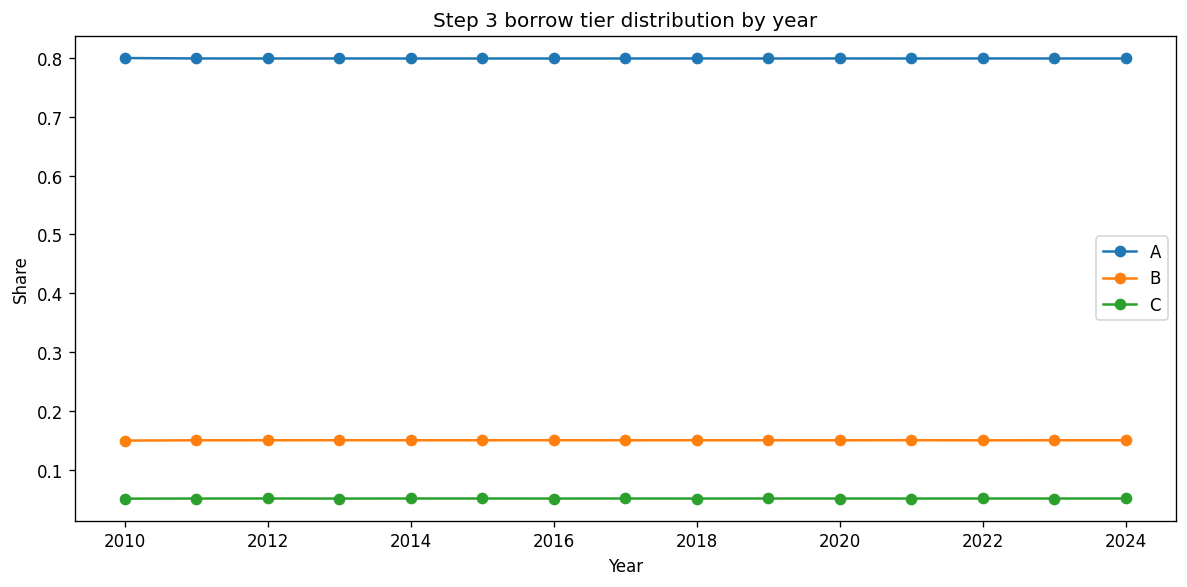

In [45]:
si["year"] = si["date"].dt.year
tier_dist = si.groupby(["year", "borrow_tier"]).size().reset_index(name="n_rows")
tier_dist["share"] = tier_dist["n_rows"] / tier_dist.groupby("year")["n_rows"].transform("sum")
missing_by_year = si.groupby("year")["si_missing"].sum().reset_index(name="missing_si_count")
tier_dist = tier_dist.merge(missing_by_year, on="year", how="left")
display(tier_dist.head(30))
fig, ax = plt.subplots(figsize=(10,5))
for tier in ["A", "B", "C"]:
    d = tier_dist[tier_dist["borrow_tier"].eq(tier)]
    ax.plot(d["year"], d["share"], marker="o", label=tier)
ax.set_title("Step 3 borrow tier distribution by year")
ax.set_xlabel("Year"); ax.set_ylabel("Share")
ax.legend()
save_and_show(fig, STEP3_FIG_DIR / "step3_borrow_tier_distribution_by_year.png")


In [46]:
# Fraction of raw short signal affected by tiered treatment
treated_rate = si["borrow_tier"].isin(["B", "C"]).mean()
hard_excl_rate = si["tier_c_flag"].mean()
print(f"Headline treatment: tiered cost (no hard exclusion).")
print(f"  Fraction of stock-days in Tier B or C (treated by elevated cost): {treated_rate:.1%}")
print(f"  Fraction in Tier C (hard-exclusion candidates, robustness): {hard_excl_rate:.1%}")

Headline treatment: tiered cost (no hard exclusion).
  Fraction of stock-days in Tier B or C (treated by elevated cost): 20.1%
  Fraction in Tier C (hard-exclusion candidates, robustness): 5.1%


### 7.3 Implied Cost Building Block

This table reports the average borrow cost by year.

Step 5 will combine these daily borrow rates with actual short positions to compute the full gross-to-net performance effect.

In [47]:
implied_cost_year = si.groupby("year").agg(mean_borrow_cost_annual_bps=("borrow_cost_annual_bps", "mean"), median_borrow_cost_annual_bps=("borrow_cost_annual_bps", "median"), tier_c_share=("tier_c_flag", "mean")).reset_index()
display(implied_cost_year)


,year,mean_borrow_cost_annual_bps,median_borrow_cost_annual_bps,tier_c_share
0,2010,102.484762,40.0,0.050754
1,2011,102.717074,40.0,0.050953
2,2012,102.757211,40.0,0.050996
3,2013,102.670725,40.0,0.050873
4,2014,102.760000,40.0,0.051000
5,2015,102.754466,40.0,0.050992
6,2016,102.704466,40.0,0.050909
7,2017,102.755538,40.0,0.051000
8,2018,102.689493,40.0,0.050905
9,2019,102.755213,40.0,0.050993


### 7.4 External Validation

This check looks at well-known short-squeeze events.

For each event, we look at the borrow-tier distribution before the squeeze date. A useful hard-to-borrow proxy should place more of these stock-days into Tier B or Tier C before the event.

In [48]:
squeeze_events = pd.DataFrame({
    "ticker": ["GME", "AMC", "HTZ", "BBBY", "BYND"],
    "event_date": pd.to_datetime([
        "2021-01-28", "2021-06-02", "2020-06-08",
        "2022-08-17", "2019-07-29",
    ]),
    "description": [
        "GameStop squeeze", "AMC squeeze", "Hertz retail rally",
        "BBBY meme squeeze", "BYND post-IPO squeeze",
    ],
})

available_tickers = set(si["ticker"].dropna().unique())
squeeze_events["in_data"] = squeeze_events["ticker"].isin(available_tickers)

print("Squeeze event ticker availability:")
display(squeeze_events)

print("\nTier distribution in the 60-day window before each squeeze peak:")
for _, ev in squeeze_events[squeeze_events["in_data"]].iterrows():
    sub = si[(si["ticker"] == ev["ticker"]) &
             (si["date"] >= ev["event_date"] - pd.Timedelta(days=60)) &
             (si["date"] <= ev["event_date"])]
    if len(sub) > 0:
        share = sub["borrow_tier"].value_counts(normalize=True).mul(100).round(1)
        print(f"  {ev['ticker']} ({ev['description']}, peak {ev['event_date'].date()}):")
        print(f"    Tier shares: {share.to_dict()}")
    else:
        print(f"  {ev['ticker']}: no SI rows in the 60-day pre-event window.")

Squeeze event ticker availability:


,ticker,event_date,description,in_data
0,GME,2021-01-28,GameStop squeeze,True
1,AMC,2021-06-02,AMC squeeze,False
2,HTZ,2020-06-08,Hertz retail rally,True
3,BBBY,2022-08-17,BBBY meme squeeze,False
4,BYND,2019-07-29,BYND post-IPO squeeze,False



Tier distribution in the 60-day window before each squeeze peak:
  GME: no SI rows in the 60-day pre-event window.
  HTZ: no SI rows in the 60-day pre-event window.


In [49]:
# Diagnostic: when does GME actually appear in our si?
gme_rows = si[si["ticker"] == "GME"]
if len(gme_rows) > 0:
    print(f"GME first appears in si: {gme_rows['date'].min().date()}")
    print(f"GME last appears in si:  {gme_rows['date'].max().date()}")
    print(f"GME total stock-days in si: {len(gme_rows):,}")
    print(f"GME stock-days by year:")
    print(gme_rows["date"].dt.year.value_counts().sort_index().to_string())
else:
    print("GME never appears in si.")

htz_rows = si[si["ticker"] == "HTZ"]
if len(htz_rows) > 0:
    print(f"HTZ first appears in si: {htz_rows['date'].min().date()}")
    print(f"HTZ last appears in si:  {htz_rows['date'].max().date()}")
    print(f"HTZ stock-days by year:")
    print(htz_rows["date"].dt.year.value_counts().sort_index().to_string())

# Check si coverage specifically in the HTZ window
htz_window = si[(si["ticker"] == "HTZ") &
                (si["date"] >= pd.Timestamp("2020-04-09")) &
                (si["date"] <= pd.Timestamp("2020-06-08"))]
print(f"\nHTZ rows in 60-day pre-event window: {len(htz_window)}")

GME first appears in si: 2010-01-04
GME last appears in si:  2024-12-31
GME total stock-days in si: 2,766
GME stock-days by year:
date
2010    252
2011    252
2012    250
2013    252
2014    252
2015    252
2016    252
2017    251
2022    251
2023    250
2024    252
HTZ first appears in si: 2023-01-03
HTZ last appears in si:  2023-12-29
HTZ stock-days by year:
date
2023    250

HTZ rows in 60-day pre-event window: 0


## 8. Save Outputs for Step 4/5 and Report

This section saves the Step 3 outputs.

**Main output:**
- `c2o_step3_borrow_tiers.parquet`  
  Point-in-time borrow tier table used by Step 4/5. It includes short-interest availability fields, `si_missing`, deterministic HTB scores, borrow tier, annual borrow bps, daily borrow rate, and high-SI / Tier-C flags.

**Other outputs:**
- `c2o_step3_borrow_tier_distribution_by_year.csv`
- `c2o_step3_borrow_cost_summary_by_year.csv`
- `c2o_step3_short_interest_coverage_by_year.csv`

The ML robustness files are not produced because the ML hard-to-borrow rule is disabled.


In [50]:
# Final cutoff assertion and save Step 3 outputs.
si_coverage = si.groupby("year").agg(rows=("instrument_id", "size"), nonmissing_si_ratio=("si_missing", lambda s: 1-s.mean()), missing_si_ratio=("si_missing", "mean")).reset_index()
step3.to_parquet(out_path("c2o_step3_borrow_tiers.parquet"), index=False)
tier_dist.to_csv(out_path("c2o_step3_borrow_tier_distribution.csv"), index=False)
tier_dist.to_csv(out_path("c2o_step3_borrow_tier_distribution_by_year.csv"), index=False)
implied_cost_year.to_csv(out_path("c2o_step3_borrow_cost_summary_by_year.csv"), index=False)
si_coverage.to_csv(out_path("c2o_step3_short_interest_coverage_by_year.csv"), index=False)
config_summary.to_csv(out_path("c2o_step3_borrow_cost_schedule.csv"), index=False)
print("Saved Step 3 outputs to", OUT_DIR.resolve())


Saved Step 3 outputs to /Users/cuiyufan/Desktop/ml data/c2o_outputs


In [51]:
# Quick sanity check on the final shared output.
print("Step3 rows:", len(step3), "unique dates:", step3["date"].nunique(), "unique instruments:", step3["instrument_id"].nunique())
assert {"date", "instrument_id", "borrow_tier", "borrow_cost_annual_bps", "borrow_daily_rate"}.issubset(step3.columns)
display(step3[["borrow_tier", "borrow_cost_annual_bps"]].drop_duplicates().sort_values("borrow_tier"))


Step3 rows: 3773971 unique dates: 3774 unique instruments: 1418


,borrow_tier,borrow_cost_annual_bps
0,A,40.0
1496,B,200.0
7480,C,800.0


In [52]:
# Step1-3 compliance checklist.
required_step45_files = ["c2o_step1_clean_panel.parquet", "c2o_step2_prelim_tradable_universe.parquet", "c2o_step3_borrow_tiers.parquet", "c2o_step1_sp500_tr_clipped.parquet"]
step13_checks = pd.DataFrame([
    {"check": "2010-2024 development panel", "passed": panel["date"].min() >= DEV_START and panel["date"].max() <= DEV_END},
    {"check": "No 2025+ data in Step1-3 live outputs", "passed": max(panel["date"].dt.year.max(), step2["date"].dt.year.max(), step3["date"].dt.year.max()) <= 2024},
    {"check": "Universe uses prior year-end snapshot", "passed": (mcap_universe_audit["universe_asof_date"].dt.year == mcap_universe_audit["year"] - 1).all()},
    {"check": "Universe frozen by calendar year", "passed": universe_map.duplicated(["year", "instrument_id"]).sum() == 0},
    {"check": "12-month history requirement", "passed": universe_map["months_hist"].ge(12).all()},
    {"check": "Strict next close-to-open overnight target", "passed": panel.loc[panel["target_next_overnight"].notna(), "is_strict_one_overnight_target"].all()},
    {"check": "Point-in-time liquidity fields", "passed": step2[["adv20_dollar", "price_lag1", "vol20_ann"]].notna().any().all()},
    {"check": "Short interest source availability no-lookahead", "passed": len(si_lookahead_violations) == 0},
    {"check": "Step4-5 input files prepared", "passed": all((OUT_DIR / f).exists() for f in required_step45_files)},
    {"check": "SP500_TR benchmark prepared", "passed": (OUT_DIR / "c2o_step1_sp500_tr_clipped.parquet").exists() and "benchmark_return" in sp500_tr.columns},
    {"check": "Step1-3 figures saved and displayed", "passed": all(Path(f).exists() for f in displayed_figure_files) and len(displayed_figure_files) >= 4},
])
step13_checks["status"] = np.where(step13_checks["passed"], "PASS", "FAIL")
display(step13_checks)
step13_checks.to_csv(out_path("step1_3_compliance_checklist.csv"), index=False)
assert step13_checks["passed"].all(), "Step1-3 compliance checklist failed."
print("Step1-3 generated files:")
for f in sorted(set(generated_files)):
    print(f)
print("Step1-3 displayed figure paths:")
for f in displayed_figure_files:
    print(f)


,check,passed,status
0,2010-2024 development panel,True,PASS
1,No 2025+ data in Step1-3 live outputs,True,PASS
2,Universe uses prior year-end snapshot,True,PASS
3,Universe frozen by calendar year,True,PASS
4,12-month history requirement,True,PASS
5,Strict next close-to-open overnight target,True,PASS
6,Point-in-time liquidity fields,True,PASS
7,Short interest source availability no-lookahead,True,PASS
8,Step4-5 input files prepared,True,PASS
9,SP500_TR benchmark prepared,True,PASS


Step1-3 generated files:
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_clean_panel.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_earnings_processed.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_earnings_timing_diagnostics.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_return_reconciliation.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_short_interest_coverage_by_year.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_short_interest_daily.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_short_interest_no_lookahead_audit.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_sp500_tr_clipped.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_trading_days.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_universe_sanity_by_year.csv
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step1_yearly_universe_map.parquet
/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2o_step2_aum_monotonicity_

# Step 4 - Final Enhanced Alpha (Point-in-Time, No Look-Ahead)

The original weak alpha is retained only as a baseline IC comparison. The final submitted alpha is `alpha_score_final`, built from lagged / point-in-time enhanced features and selected using train + validation only. Development-test remains report-only.


In [53]:
# ============================================================
# Step 4.1-4.4 - Final Enhanced Alpha, point-in-time only
# ============================================================
print("Step 4: building final point-in-time Enhanced Alpha panel...")

TARGET_COL = "target_next_overnight"
FINAL_SCORE_COL = "alpha_score_final"
FINAL_SIGNAL_COL_VAR = "selected_final_signal_col"

required_step4_inputs = ["date", "instrument_id", "ticker", "adj_open", "adjusted_close", "high", "low", "close", "volume", "market_cap", "r_on", "r_id", "r_cc", TARGET_COL, "eligible"]
missing_step4_inputs = [c for c in required_step4_inputs if c not in panel.columns]
assert not missing_step4_inputs, f"Step4 missing required panel columns: {missing_step4_inputs}"
assert panel["date"].max() <= DEV_END, f"Step4 input panel contains data after {DEV_END.date()}: {panel['date'].max()}"
assert step3["date"].max() <= DEV_END, f"Step4 input step3 contains data after {DEV_END.date()}: {step3['date'].max()}"

alpha = panel.loc[panel["eligible"]].sort_values(["instrument_id", "date"]).copy()
alpha = alpha[alpha["date"].between(DEV_START, DEV_END)].copy()
alpha["period"] = period_from_date(alpha["date"])
assert alpha["period"].ne("outside").all(), "Step4 alpha panel contains rows outside 2010-2024 train/validation/development-test windows."
assert alpha.duplicated(["date", "instrument_id"]).sum() == 0, "Step4 alpha panel has duplicate date/instrument_id rows."

g = alpha.groupby("instrument_id", group_keys=False)

# Raw OHLCV-derived values are computed first, then shifted by one trading day before any use as features.
alpha["intraday_ret_1d_raw"] = alpha["adjusted_close"] / alpha["adj_open"].replace(0, np.nan) - 1
alpha["close_to_close_ret_1d_raw"] = alpha["r_cc"].astype(float)
alpha["overnight_ret_1d_raw"] = alpha["r_on"].astype(float)
alpha["dollar_volume_raw"] = alpha["volume"].astype(float) * alpha["close"].astype(float)
alpha["volume_ratio_20d_raw"] = alpha["volume"] / g["volume"].transform(lambda s: s.rolling(20, min_periods=20).mean()).replace(0, np.nan)
alpha["dollar_volume_ratio_20d_raw"] = alpha["dollar_volume_raw"] / g["dollar_volume_raw"].transform(lambda s: s.rolling(20, min_periods=20).mean()).replace(0, np.nan)
alpha["high_low_range_raw"] = (alpha["high"] - alpha["low"]) / alpha["close"].replace(0, np.nan)
alpha["realized_vol_20d_raw"] = g["close_to_close_ret_1d_raw"].transform(lambda s: s.rolling(20, min_periods=20).std())
alpha["abs_intraday_shock_raw"] = alpha["intraday_ret_1d_raw"].abs()
alpha["ret_3d_raw"] = g["close_to_close_ret_1d_raw"].transform(lambda s: s.rolling(3, min_periods=2).sum())
alpha["ret_5d_raw"] = g["close_to_close_ret_1d_raw"].transform(lambda s: s.rolling(5, min_periods=3).sum())
alpha["ret_20d_raw"] = g["close_to_close_ret_1d_raw"].transform(lambda s: s.rolling(20, min_periods=10).sum())
alpha["adv20_dollar_raw"] = g["dollar_volume_raw"].transform(lambda s: s.rolling(20, min_periods=20).mean())

alpha["market_intraday_ret_1d_raw"] = alpha.groupby("date")["intraday_ret_1d_raw"].transform("mean")
alpha["market_close_to_close_ret_1d_raw"] = alpha.groupby("date")["close_to_close_ret_1d_raw"].transform("mean")
alpha["resid_intraday_ret_1d_raw"] = alpha["intraday_ret_1d_raw"] - alpha["market_intraday_ret_1d_raw"]
alpha["resid_close_to_close_ret_1d_raw"] = alpha["close_to_close_ret_1d_raw"] - alpha["market_close_to_close_ret_1d_raw"]

raw_to_lagged = {
    "intraday_ret_1d_raw": "intraday_ret_1d_lag1",
    "close_to_close_ret_1d_raw": "close_to_close_ret_1d_lag1",
    "overnight_ret_1d_raw": "overnight_ret_1d_lag1",
    "volume_ratio_20d_raw": "volume_ratio_20d_lag1",
    "dollar_volume_ratio_20d_raw": "dollar_volume_ratio_20d_lag1",
    "high_low_range_raw": "high_low_range_lag1",
    "realized_vol_20d_raw": "realized_vol_20d_lag1",
    "abs_intraday_shock_raw": "abs_intraday_shock_lag1",
    "resid_intraday_ret_1d_raw": "resid_intraday_ret_1d_lag1",
    "resid_close_to_close_ret_1d_raw": "resid_close_to_close_ret_1d_lag1",
    "ret_3d_raw": "ret_3d_lag1",
    "ret_5d_raw": "ret_5d_lag1",
    "ret_20d_raw": "ret_20d_lag1",
    "adv20_dollar_raw": "adv20_dollar",
}
for raw_col, lag_col in raw_to_lagged.items():
    alpha[lag_col] = g[raw_col].shift(1)

alpha["market_cap_lag1"] = g["market_cap"].shift(1)
alpha["log_market_cap_lag1"] = np.log(alpha["market_cap_lag1"].where(alpha["market_cap_lag1"] > 0))
alpha["log_adv20_dollar_lag1"] = np.log(alpha["adv20_dollar"].where(alpha["adv20_dollar"] > 0))

# Borrow / short-pressure block is already publication-lagged in Step 1B and tiered in Step 3.
borrow_cols = ["date", "instrument_id", "dsi", "dtcn", "ddtcn", "htb_score_pct", "borrow_tier", "borrow_cost_annual_bps", "borrow_daily_rate", "si_snapshot_date"]
alpha = alpha.merge(step3[[c for c in borrow_cols if c in step3.columns]], on=["date", "instrument_id"], how="left")
alpha["borrow_tier"] = alpha["borrow_tier"].fillna("A")
alpha["borrow_bps_pa"] = alpha["borrow_cost_annual_bps"].fillna(BORROW_COST_BPS_PA["A"]).astype(float)
alpha["borrow_daily_rate"] = alpha["borrow_daily_rate"].fillna(BORROW_COST_BPS_PA["A"] / 10000 / TRADING_DAYS_PER_YEAR)
for c in ["dsi", "dtcn", "ddtcn", "htb_score_pct"]:
    if c in alpha.columns:
        alpha[c + "_pit"] = pd.to_numeric(alpha[c], errors="coerce")

reversal_features = [
    "overnight_ret_1d_lag1", "intraday_ret_1d_lag1", "close_to_close_ret_1d_lag1",
    "ret_3d_lag1", "ret_5d_lag1", "resid_intraday_ret_1d_lag1", "resid_close_to_close_ret_1d_lag1",
]
liquidity_pressure_features = [
    "volume_ratio_20d_lag1", "dollar_volume_ratio_20d_lag1", "high_low_range_lag1",
    "realized_vol_20d_lag1", "abs_intraday_shock_lag1", "log_adv20_dollar_lag1",
]
borrow_pressure_features = [c for c in ["dsi_pit", "dtcn_pit", "ddtcn_pit", "htb_score_pct_pit", "borrow_bps_pa"] if c in alpha.columns]
stable_control_features = ["log_market_cap_lag1", "adv20_dollar", "realized_vol_20d_lag1"]
enhanced_feature_list = list(dict.fromkeys(reversal_features + liquidity_pressure_features + borrow_pressure_features + stable_control_features))

prohibited_exact = {
    "adjusted_close", "adjusted_open", "adjusted_high", "adjusted_low", "adj_open", "open", "high", "low", "close", "volume", "dollar_volume",
    "r_on", "r_id", "r_cc", TARGET_COL, "target_raw", "next_adj_open", "next_open", "next_date",
}
future_terms = ["target", "next_adj_open", "next_open", "future", "lead"]
unlagged_ohlcv_terms = ["intraday_ret_1d", "close_to_close_ret_1d", "overnight_ret_1d", "volume_ratio_20d", "dollar_volume_ratio_20d", "high_low_range", "realized_vol_20d", "abs_intraday_shock", "resid_intraday_ret_1d", "resid_close_to_close_ret_1d", "ret_3d", "ret_5d", "ret_20d"]

bad_exact = sorted(set(enhanced_feature_list).intersection(prohibited_exact))
bad_future = sorted([f for f in enhanced_feature_list if any(term in f.lower() for term in future_terms)])
bad_unlagged = sorted([
    f for f in enhanced_feature_list
    if any(f == term or f.startswith(term + "_") for term in unlagged_ohlcv_terms)
    and not ("lag" in f.lower() or f.endswith("_pit"))
])
assert not bad_exact, f"Enhanced feature list contains prohibited raw/target columns: {bad_exact}"
assert not bad_future, f"Enhanced feature list contains target/future-looking columns: {bad_future}"
assert not bad_unlagged, f"Enhanced OHLCV-derived features must be lagged; offending columns: {bad_unlagged}"

feature_catalog = []
for f in enhanced_feature_list:
    if f in reversal_features:
        block = "A_lagged_reversal"
    elif f in liquidity_pressure_features:
        block = "B_lagged_liquidity_pressure"
    elif f in borrow_pressure_features:
        block = "C_borrow_short_pressure_pit"
    else:
        block = "D_stable_controls_lagged"
    feature_catalog.append({
        "feature": f,
        "block": block,
        "point_in_time_rule": "lag1 after raw/rolling calculation" if block != "C_borrow_short_pressure_pit" else "publication-lagged short-interest / borrow tier from Step3",
        "used_in_model": True,
    })
feature_catalog = pd.DataFrame(feature_catalog)

def _finite_numeric(s):
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

def cs_winsor_zscore(df, col, lower=0.01, upper=0.99, fill_value=0.0):
    x = _finite_numeric(df[col])
    date_index = pd.to_datetime(df["date"])
    valid_counts = x.groupby(date_index).transform("count")
    q = x.groupby(date_index).quantile([lower, upper]).unstack()
    lo_map = date_index.map(q[lower])
    hi_map = date_index.map(q[upper])
    w = x.clip(lower=lo_map, upper=hi_map)
    w = w.where(valid_counts >= 5)
    mu = w.groupby(date_index).transform("mean")
    sd = w.groupby(date_index).transform("std").replace(0, np.nan)
    return ((w - mu) / sd).replace([np.inf, -np.inf], np.nan).fillna(fill_value)

for f in enhanced_feature_list:
    alpha[f + "_z"] = cs_winsor_zscore(alpha, f)

z = {f: f + "_z" for f in enhanced_feature_list}

# Weak alpha baseline retained only for comparison, never used by Step5.
alpha["signal_weak_alpha_baseline"] = cs_winsor_zscore(alpha.assign(_weak=-alpha["overnight_ret_1d_lag1"]), "_weak")

# Step 4.2: three pre-specified candidate enhanced signals.
rev_components = [
    -alpha[z["overnight_ret_1d_lag1"]],
    -alpha[z["intraday_ret_1d_lag1"]],
    -alpha[z["close_to_close_ret_1d_lag1"]],
    -alpha[z["ret_3d_lag1"]],
    -alpha[z["ret_5d_lag1"]],
    -alpha[z["resid_intraday_ret_1d_lag1"]],
    -alpha[z["resid_close_to_close_ret_1d_lag1"]],
]
alpha["signal_reversal_only_raw"] = pd.concat(rev_components, axis=1).mean(axis=1)
alpha["signal_reversal_only"] = cs_winsor_zscore(alpha, "signal_reversal_only_raw")

alpha["signal_reversal_liquidity_vol_raw"] = (
    0.70 * alpha["signal_reversal_only"]
    + 0.10 * alpha[z["volume_ratio_20d_lag1"]]
    + 0.10 * alpha[z["dollar_volume_ratio_20d_lag1"]]
    + 0.05 * alpha[z["log_adv20_dollar_lag1"]]
    - 0.10 * alpha[z["realized_vol_20d_lag1"]]
    - 0.05 * alpha[z["high_low_range_lag1"]]
    - 0.03 * alpha[z["abs_intraday_shock_lag1"]]
)
alpha["signal_reversal_liquidity_vol"] = cs_winsor_zscore(alpha, "signal_reversal_liquidity_vol_raw")

candidate_signals = ["signal_reversal_only", "signal_reversal_liquidity_vol"]
ridge_feature_z = [f + "_z" for f in enhanced_feature_list if f + "_z" in alpha.columns]
ridge_coefficients = pd.DataFrame()
if Ridge is not None and StandardScaler is not None:
    train_mask = alpha["period"].eq("train") & alpha[TARGET_COL].notna()
    X_train = alpha.loc[train_mask, ridge_feature_z].replace([np.inf, -np.inf], np.nan)
    y_train = alpha.loc[train_mask, TARGET_COL].astype(float)
    y_train = y_train - y_train.groupby(alpha.loc[train_mask, "date"]).transform("mean")
    train_medians = X_train.median(axis=0).fillna(0.0)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.fillna(train_medians))
    ridge = Ridge(alpha=10.0)
    ridge.fit(X_train_scaled, y_train)
    X_all_scaled = scaler.transform(alpha[ridge_feature_z].replace([np.inf, -np.inf], np.nan).fillna(train_medians))
    alpha["signal_regularised_linear_raw"] = ridge.predict(X_all_scaled)
    alpha["signal_regularised_linear"] = cs_winsor_zscore(alpha, "signal_regularised_linear_raw")
    candidate_signals.append("signal_regularised_linear")
    ridge_coefficients = pd.DataFrame({"feature": ridge_feature_z, "coefficient": ridge.coef_, "ridge_alpha": 10.0})
else:
    print("WARNING: sklearn Ridge/StandardScaler unavailable; signal_regularised_linear skipped.")

# Step 4.3: signal selection by train + validation IC only. Development-test is report-only.
def daily_spearman_ic(df, score_col, target_col=TARGET_COL, min_names=20):
    required = ["date", score_col, target_col]
    missing = [c for c in required if c not in df.columns]
    assert not missing, f"daily_spearman_ic missing columns for {score_col}: {missing}"
    rows = []
    tmp = df[required].replace([np.inf, -np.inf], np.nan).dropna()
    for dt, day in tmp.groupby("date", sort=True):
        if len(day) < min_names or day[score_col].nunique() < 2 or day[target_col].nunique() < 2:
            rows.append({"date": dt, "ic": np.nan, "n_names": len(day)})
        else:
            rows.append({"date": dt, "ic": day[score_col].rank().corr(day[target_col].rank()), "n_names": len(day)})
    return pd.DataFrame(rows)

def summarize_ic_series(ic_df):
    if ic_df.empty:
        return pd.DataFrame()
    x = ic_df.copy()
    x["period"] = period_from_date(x["date"])
    rows = []
    for pname in ["train", "validation", "development_test"]:
        vals = x.loc[x["period"].eq(pname), "ic"].dropna()
        rows.append({
            "period": pname,
            "mean_ic": vals.mean(),
            "median_ic": vals.median(),
            "ic_std": vals.std(ddof=1),
            "ic_t_stat": vals.mean() / (vals.std(ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 and vals.std(ddof=1) > 0 else np.nan,
            "ic_hit_rate": (vals > 0).mean() if len(vals) else np.nan,
            "n_days": len(vals),
            "avg_names": x.loc[x["period"].eq(pname), "n_names"].mean(),
        })
    return pd.DataFrame(rows)

feature_ic_parts = []
print("Step 4: computing single-factor IC table...")
for f in enhanced_feature_list:
    ic = daily_spearman_ic(alpha, f + "_z")
    sm = summarize_ic_series(ic)
    sm.insert(0, "feature", f)
    block = feature_catalog.loc[feature_catalog["feature"].eq(f), "block"].iloc[0]
    sm.insert(1, "block", block)
    feature_ic_parts.append(sm)
feature_ic_table = pd.concat(feature_ic_parts, ignore_index=True)

signal_ic_parts = []
signal_daily_ic_parts = []
for s in ["signal_weak_alpha_baseline"] + candidate_signals:
    ic = daily_spearman_ic(alpha, s)
    ic["signal"] = s
    signal_daily_ic_parts.append(ic)
    sm = summarize_ic_series(ic)
    sm.insert(0, "signal", s)
    sm["role"] = "baseline_only" if s == "signal_weak_alpha_baseline" else "candidate_enhanced"
    signal_ic_parts.append(sm)
signal_ic_summary = pd.concat(signal_ic_parts, ignore_index=True)
signal_daily_ic = pd.concat(signal_daily_ic_parts, ignore_index=True)

candidate_summary = signal_ic_summary[signal_ic_summary["signal"].isin(candidate_signals)].pivot(index="signal", columns="period", values="mean_ic")
candidate_stability = signal_ic_summary[signal_ic_summary["signal"].isin(candidate_signals)].pivot(index="signal", columns="period", values="ic_hit_rate")
selection_rows = []
complexity_rank = {"signal_reversal_only": 1, "signal_reversal_liquidity_vol": 2, "signal_regularised_linear": 3}
for s in candidate_signals:
    selection_rows.append({
        "signal": s,
        "complexity_rank": complexity_rank.get(s, 99),
        "train_mean_ic": candidate_summary.loc[s, "train"] if s in candidate_summary.index and "train" in candidate_summary.columns else np.nan,
        "validation_mean_ic": candidate_summary.loc[s, "validation"] if s in candidate_summary.index and "validation" in candidate_summary.columns else np.nan,
        "validation_hit_rate": candidate_stability.loc[s, "validation"] if s in candidate_stability.index and "validation" in candidate_stability.columns else np.nan,
        "interpretability_rank": complexity_rank.get(s, 99),
        "development_test_mean_ic_report_only": candidate_summary.loc[s, "development_test"] if s in candidate_summary.index and "development_test" in candidate_summary.columns else np.nan,
    })
signal_selection_table = pd.DataFrame(selection_rows)
valid_selection = signal_selection_table[
    signal_selection_table["validation_mean_ic"].notna()
    & signal_selection_table["train_mean_ic"].notna()
    & signal_selection_table["train_mean_ic"].gt(-0.002)
].copy()
assert not valid_selection.empty, "No enhanced signal has enough train/validation IC observations for final signal selection."
max_val_ic = valid_selection["validation_mean_ic"].max()
close_band = 0.001
stable_pool = valid_selection[valid_selection["validation_mean_ic"].ge(max_val_ic - close_band)].copy()
if stable_pool.empty:
    stable_pool = valid_selection.copy()
stable_pool = stable_pool.sort_values(["complexity_rank", "validation_hit_rate", "train_mean_ic"], ascending=[True, False, False])
selected_final_signal_col = str(stable_pool.iloc[0]["signal"])
if selected_final_signal_col != valid_selection.sort_values("validation_mean_ic", ascending=False).iloc[0]["signal"]:
    final_signal_selection_reason = (
        f"Selected {selected_final_signal_col}: validation IC was within {close_band:.3f} of the best candidate, "
        "so the simpler/more interpretable signal was preferred."
    )
else:
    final_signal_selection_reason = (
        f"Selected {selected_final_signal_col}: best validation IC among the three pre-specified enhanced candidates, "
        "with train IC sanity check."
    )
alpha[FINAL_SCORE_COL] = cs_winsor_zscore(alpha.rename(columns={selected_final_signal_col: "__selected_signal"}), "__selected_signal")

# Step 4.4: explicit no-look-ahead and output audit.
nonnull_daily = alpha.groupby("date")[FINAL_SCORE_COL].apply(lambda s: s.notna().sum()).reset_index(name="nonnull_alpha_names")
sufficient_daily_cross_section = bool(nonnull_daily["nonnull_alpha_names"].quantile(0.05) >= 20)

step4_audit = pd.DataFrame([
    {"audit_item": "no_data_after_2024_12_31", "passed": bool(alpha["date"].max() <= DEV_END), "detail": str(alpha["date"].max().date())},
    {"audit_item": "no_2025_2026_data", "passed": bool(alpha["date"].dt.year.max() <= 2024), "detail": str(int(alpha["date"].dt.year.max()))},
    {"audit_item": "no_target_used_as_feature", "passed": not bad_future and TARGET_COL not in enhanced_feature_list, "detail": ",".join(bad_future)},
    {"audit_item": "no_next_adj_open_used_as_feature", "passed": "next_adj_open" not in enhanced_feature_list, "detail": "next_adj_open absent from enhanced_feature_list"},
    {"audit_item": "all_enhanced_ohlcv_features_are_lagged", "passed": not bad_unlagged, "detail": ",".join(bad_unlagged)},
    {"audit_item": "alpha_score_final_sufficient_cross_section", "passed": sufficient_daily_cross_section, "detail": f"p05 daily non-null alpha names={nonnull_daily['nonnull_alpha_names'].quantile(0.05):.0f}"},
    {"audit_item": "development_test_not_used_in_tuning", "passed": True, "detail": "Signal selection used train/validation IC only; development-test columns are report-only."},
])
assert step4_audit["passed"].all(), "Step4 audit failed: " + step4_audit.loc[~step4_audit["passed"], ["audit_item", "detail"]].to_string(index=False)

step4_output_cols = [
    "date", "ticker", "instrument_id", FINAL_SCORE_COL, TARGET_COL, "expected_next_trading_day", "next_date",
    "next_adj_open", "is_strict_one_overnight_target", "adv20_dollar", "borrow_tier", "borrow_bps_pa",
    "borrow_daily_rate", "period", "realized_vol_20d_lag1", "selected_final_signal_col",
]
alpha["selected_final_signal_col"] = selected_final_signal_col
alpha_scores = alpha[[c for c in step4_output_cols if c in alpha.columns]].copy()
alpha_scores = alpha_scores[alpha_scores["date"].between(DEV_START, DEV_END)].copy()
assert alpha_scores["date"].max() <= DEV_END, f"step4_alpha_scores has data after {DEV_END.date()}."
assert TARGET_COL in alpha_scores.columns, "step4_alpha_scores must include target_next_overnight for label/PnL."
assert FINAL_SCORE_COL in alpha_scores.columns, "step4_alpha_scores must include alpha_score_final."
assert alpha_scores.duplicated(["date", "instrument_id"]).sum() == 0, "step4_alpha_scores has duplicate date/instrument_id rows."
assert alpha_scores[FINAL_SCORE_COL].notna().sum() > 0, "alpha_score_final is entirely null."

print("Step 4 signal IC summary:")
display(signal_ic_summary.round(4))
print("Step 4 signal selection table:")
display(signal_selection_table.round(4))
print(final_signal_selection_reason)
print("Step 4 audit table:")
display(step4_audit)

alpha_scores.to_parquet(out_path("step4_alpha_scores.parquet"), index=False)
signal_ic_summary.to_csv(out_path("step4_signal_ic_summary.csv"), index=False)
feature_ic_table.to_csv(out_path("step4_feature_ic_table.csv"), index=False)
step4_audit.to_csv(out_path("step4_alpha_audit.csv"), index=False)
feature_catalog.to_csv(out_path("step4_feature_catalog.csv"), index=False)
signal_selection_table.to_csv(out_path("step4_signal_selection_table.csv"), index=False)
signal_daily_ic.to_csv(out_path("step4_signal_daily_ic.csv"), index=False)
if not ridge_coefficients.empty:
    ridge_coefficients.to_csv(out_path("step4_regularised_linear_coefficients.csv"), index=False)

print(f"Step 4 complete. Final alpha used by Step 5: {FINAL_SCORE_COL}; selected final_signal_col: {selected_final_signal_col}")


Step 4: building final point-in-time Enhanced Alpha panel...
Step 4: computing single-factor IC table...
Step 4 signal IC summary:


,signal,period,mean_ic,median_ic,ic_std,ic_t_stat,ic_hit_rate,n_days,avg_names,role
0,signal_weak_alpha_baseline,train,-0.0235,-0.0264,0.1759,-6.3670,0.4163,2263,999.9929,baseline_only
1,signal_weak_alpha_baseline,validation,-0.0056,-0.0216,0.2742,-0.5662,0.4650,757,999.9881,baseline_only
2,signal_weak_alpha_baseline,development_test,0.0066,0.0122,0.2346,0.7679,0.5199,752,999.9574,baseline_only
3,signal_reversal_only,train,0.0154,0.0177,0.1461,5.0068,0.5639,2263,999.9929,candidate_enhanced
4,signal_reversal_only,validation,0.0042,0.0059,0.2213,0.5228,0.5218,757,999.9881,candidate_enhanced
5,signal_reversal_only,development_test,0.0081,0.0080,0.2003,1.1065,0.5213,752,999.9574,candidate_enhanced
6,signal_reversal_liquidity_vol,train,0.0140,0.0156,0.1409,4.7351,0.5563,2263,999.9929,candidate_enhanced
7,signal_reversal_liquidity_vol,validation,0.0004,0.0003,0.2133,0.0487,0.5033,757,999.9881,candidate_enhanced
8,signal_reversal_liquidity_vol,development_test,0.0119,0.0094,0.1921,1.6956,0.5279,752,999.9574,candidate_enhanced
9,signal_regularised_linear,train,0.0361,0.0397,0.1682,10.2137,0.6253,2263,999.9929,candidate_enhanced


Step 4 signal selection table:


,signal,complexity_rank,train_mean_ic,validation_mean_ic,validation_hit_rate,interpretability_rank,development_test_mean_ic_report_only
0,signal_reversal_only,1,0.0154,0.0042,0.5218,1,0.0081
1,signal_reversal_liquidity_vol,2,0.0140,0.0004,0.5033,2,0.0119
2,signal_regularised_linear,3,0.0361,0.0232,0.5641,3,-0.0064


Selected signal_regularised_linear: best validation IC among the three pre-specified enhanced candidates, with train IC sanity check.
Step 4 audit table:


,audit_item,passed,detail
0,no_data_after_2024_12_31,True,2024-12-31
1,no_2025_2026_data,True,2024
2,no_target_used_as_feature,True,
3,no_next_adj_open_used_as_feature,True,next_adj_open absent from enhanced_feature_list
4,all_enhanced_ohlcv_features_are_lagged,True,
5,alpha_score_final_sufficient_cross_section,True,p05 daily non-null alpha names=1000
6,development_test_not_used_in_tuning,True,Signal selection used train/validation IC only...


Step 4 complete. Final alpha used by Step 5: alpha_score_final; selected final_signal_col: signal_regularised_linear


STEP 4 VISUALISATION: ALPHA QUALITY AND SIGNAL SELECTION


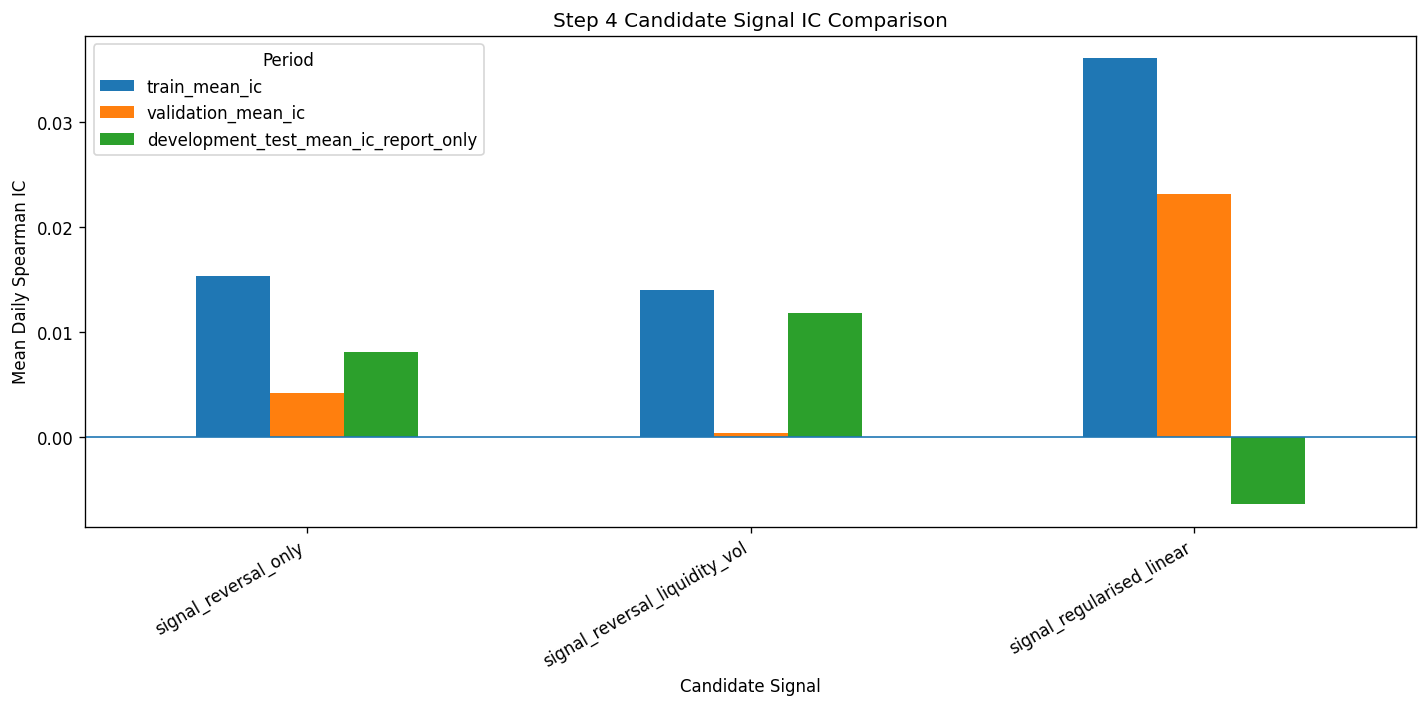

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step4/step4_signal_ic_comparison.png


/Users/cuiyufan/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/var/folders/mn/7_dn1rdx68l7sx6yf5h6661c0000gn/T/ipykernel_54893/653771064.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["alpha_score_final"].corr(x["target_next_overnight"], method="spearman"))


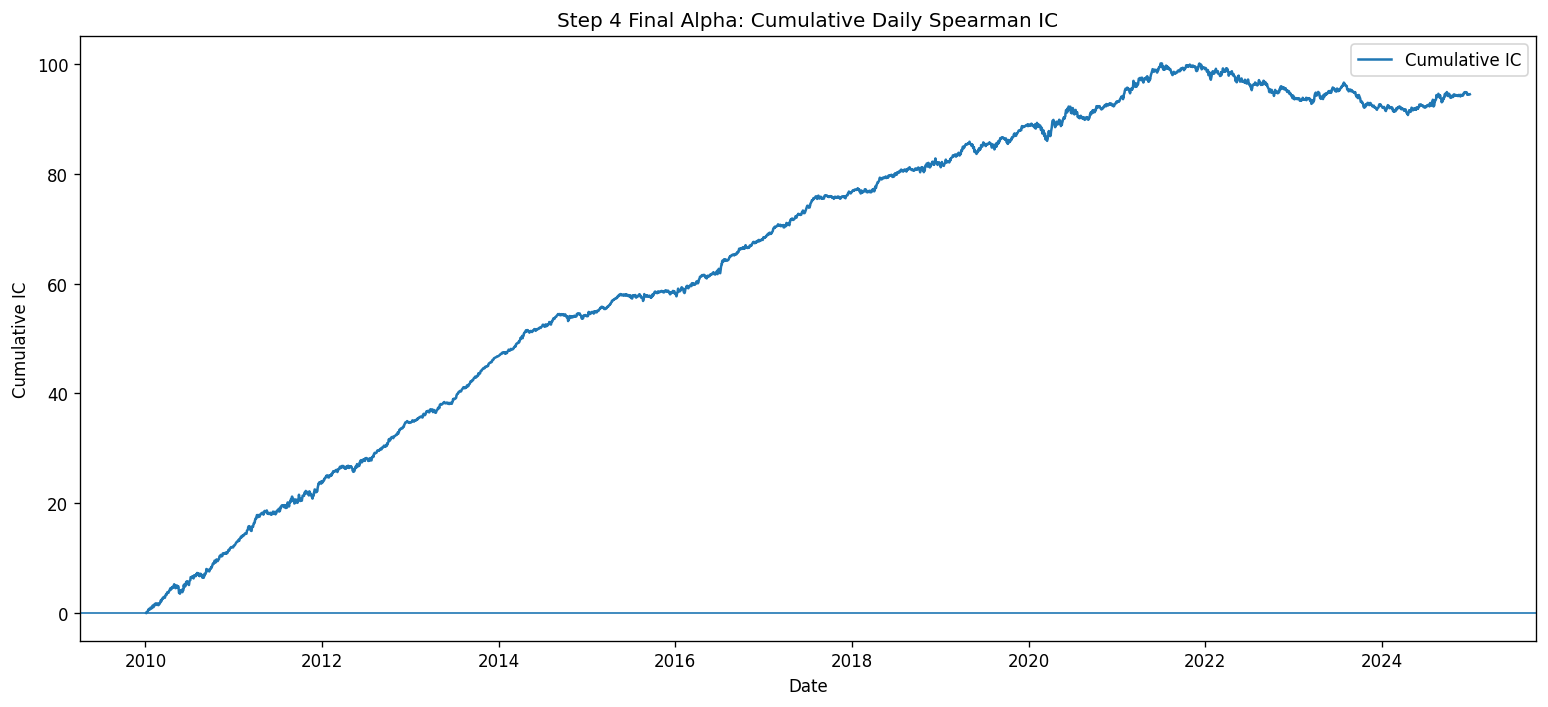

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step4/step4_final_alpha_cumulative_ic.png


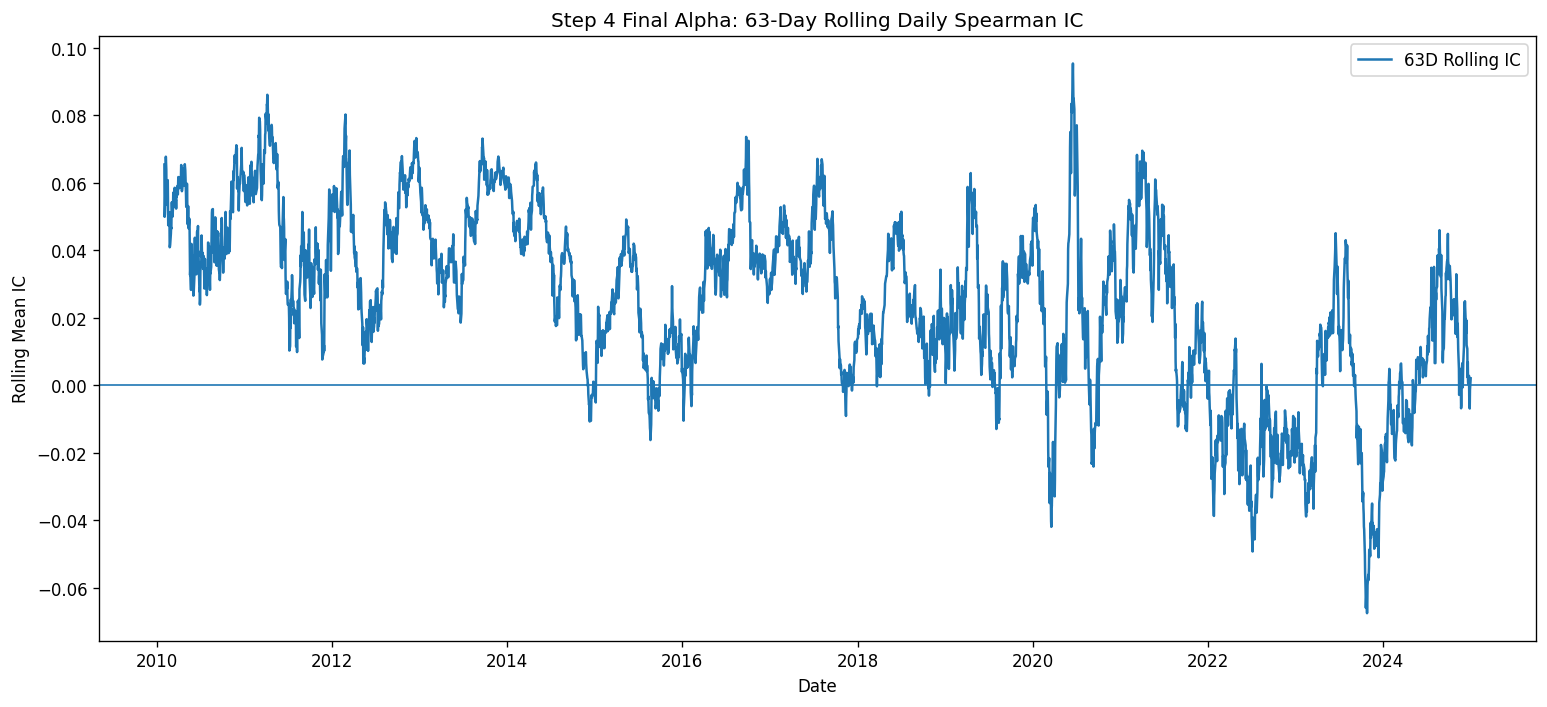

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step4/step4_final_alpha_rolling_ic.png


,final_alpha_daily_ic_summary
count,3772.0000
mean,0.0251
std,0.1945
min,-0.6213
25%,-0.0834
50%,0.0309
75%,0.1347
max,0.7158


In [54]:
# ============================================================
# Step 4 Visualisation: Enhanced Alpha IC and Signal Comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure output folder exists
# Use the same figure root defined in Step 1
STEP4_FIG_DIR = FIG_DIR / "step4"
STEP4_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("STEP 4 VISUALISATION: ALPHA QUALITY AND SIGNAL SELECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Signal IC comparison by period
# ------------------------------------------------------------
if "signal_selection_table" in globals():
    ic_plot = signal_selection_table.copy()

    # Try to identify signal column
    signal_col_candidates = [
        c for c in ic_plot.columns 
        if c.lower() in ["signal", "signal_col", "candidate_signal", "alpha_signal"]
    ]
    signal_col = signal_col_candidates[0] if signal_col_candidates else ic_plot.columns[0]

    # Keep likely IC columns
    ic_cols = [
        c for c in ic_plot.columns
        if any(k in c.lower() for k in ["train", "validation", "development", "test"])
        and any(k in c.lower() for k in ["ic", "mean"])
    ]

    if len(ic_cols) > 0:
        plot_df = ic_plot[[signal_col] + ic_cols].copy()
        plot_df = plot_df.set_index(signal_col)

        ax = plot_df.plot(kind="bar", figsize=(12, 6))
        ax.axhline(0, linewidth=1)
        ax.set_title("Step 4 Candidate Signal IC Comparison")
        ax.set_ylabel("Mean Daily Spearman IC")
        ax.set_xlabel("Candidate Signal")
        ax.legend(title="Period")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        fig_path = STEP4_FIG_DIR / "step4_signal_ic_comparison.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show(block=False)
        plt.close()

        print(f"Saved: {fig_path}")
    else:
        print("No period IC columns found in signal_selection_table; skipped IC comparison chart.")
else:
    print("signal_selection_table not found; skipped IC comparison chart.")


# ------------------------------------------------------------
# 2. Daily IC and cumulative IC for final alpha_score_final
# ------------------------------------------------------------
if "alpha_scores" in globals():
    alpha_plot_df = alpha_scores.copy()
elif "score_input" in globals():
    alpha_plot_df = score_input.copy()
else:
    alpha_plot_df = None

if alpha_plot_df is not None:
    date_col = COL["date"] if "COL" in globals() and "date" in COL else "date"
    id_col = COL["id"] if "COL" in globals() and "id" in COL else (
        "instrument_id" if "instrument_id" in alpha_plot_df.columns else "ticker"
    )

    required_cols = [date_col, id_col, "alpha_score_final", "target_next_overnight"]
    missing_cols = [c for c in required_cols if c not in alpha_plot_df.columns]

    if len(missing_cols) == 0:
        ic_daily = (
            alpha_plot_df
            .dropna(subset=["alpha_score_final", "target_next_overnight"])
            .groupby(date_col)
            .apply(lambda x: x["alpha_score_final"].corr(x["target_next_overnight"], method="spearman"))
            .rename("daily_spearman_ic")
            .reset_index()
        )

        ic_daily[date_col] = pd.to_datetime(ic_daily[date_col])
        ic_daily = ic_daily.sort_values(date_col)
        ic_daily["cumulative_ic"] = ic_daily["daily_spearman_ic"].fillna(0).cumsum()
        ic_daily["rolling_63d_ic"] = ic_daily["daily_spearman_ic"].rolling(63, min_periods=20).mean()

        fig, ax = plt.subplots(figsize=(13, 6))
        ax.plot(ic_daily[date_col], ic_daily["cumulative_ic"], label="Cumulative IC")
        ax.set_title("Step 4 Final Alpha: Cumulative Daily Spearman IC")
        ax.set_ylabel("Cumulative IC")
        ax.set_xlabel("Date")
        ax.axhline(0, linewidth=1)
        ax.legend()
        plt.tight_layout()

        fig_path = STEP4_FIG_DIR / "step4_final_alpha_cumulative_ic.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show(block=False)
        plt.close()

        print(f"Saved: {fig_path}")

        fig, ax = plt.subplots(figsize=(13, 6))
        ax.plot(ic_daily[date_col], ic_daily["rolling_63d_ic"], label="63D Rolling IC")
        ax.axhline(0, linewidth=1)
        ax.set_title("Step 4 Final Alpha: 63-Day Rolling Daily Spearman IC")
        ax.set_ylabel("Rolling Mean IC")
        ax.set_xlabel("Date")
        ax.legend()
        plt.tight_layout()

        fig_path = STEP4_FIG_DIR / "step4_final_alpha_rolling_ic.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show(block=False)
        plt.close()

        print(f"Saved: {fig_path}")

        display(
            ic_daily["daily_spearman_ic"]
            .describe()
            .to_frame("final_alpha_daily_ic_summary")
            .round(4)
        )

    else:
        print(f"Missing columns for final alpha IC plot: {missing_cols}")
else:
    print("No alpha score dataframe found; skipped final alpha IC charts.")

# Step 4 Additional Brief Diagnostics

Feature-group ablation and IC stability diagnostics are reporting-only. They do not alter final signal selection.


Step 4 additional diagnostics: feature-group ablation and IC stability (reporting only).


,signal_group,period,mean_ic,median_ic,ic_std,icir,positive_ic_day_fraction,n_days
0,reversal,full_2010_2024,0.0117,0.0132,0.1750,1.0595,0.5469,3772
1,reversal,train,0.0154,0.0177,0.1461,1.6708,0.5639,2263
2,reversal,validation,0.0042,0.0059,0.2213,0.3017,0.5218,757
3,reversal,development_test,0.0081,0.0080,0.2003,0.6406,0.5213,752
4,liquidity_volatility,full_2010_2024,-0.0032,-0.0030,0.2055,-0.2447,0.4942,3772
5,liquidity_volatility,train,-0.0049,-0.0044,0.1849,-0.4228,0.4896,2263
6,liquidity_volatility,validation,-0.0159,-0.0263,0.2303,-1.0957,0.4650,757
7,liquidity_volatility,development_test,0.0149,0.0258,0.2350,1.0082,0.5372,752
8,short_borrow,full_2010_2024,0.0018,0.0024,0.0964,0.3046,0.5103,3772
9,short_borrow,train,0.0012,0.0033,0.0827,0.2326,0.5148,2263


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step4/fig_step4_feature_group_mean_ic_by_period.png


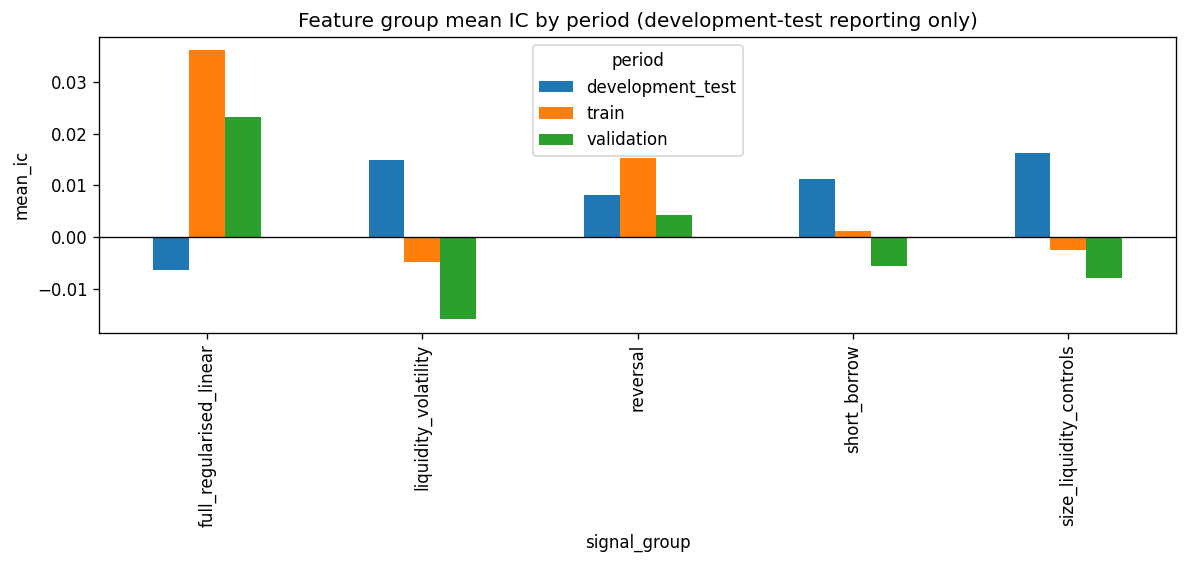

Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step4/fig_step4_feature_group_icir_by_period.png


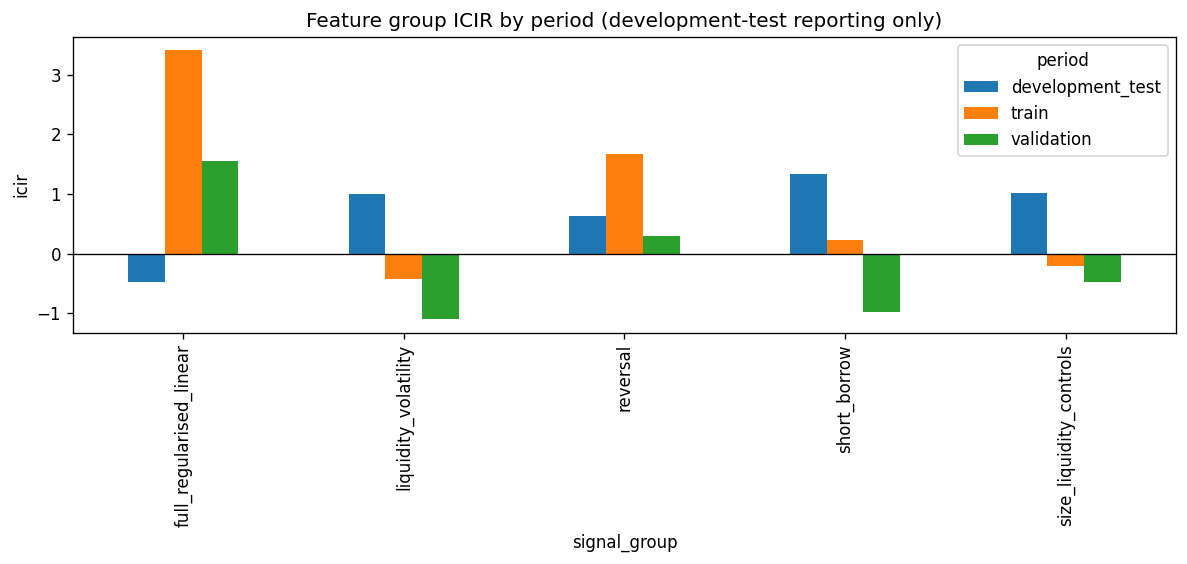

,subperiod,mean_ic,icir,positive_ic_day_fraction,n_days
0,2010-2012,0.0461,3.7475,0.6348,753
1,2013-2015,0.0310,3.7875,0.6349,756
2,2016-2018,0.0313,2.8763,0.6061,754
3,2019-2021,0.0232,1.5559,0.5641,757
4,2022-2024,-0.0064,-0.4683,0.4801,752


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step4/fig_step4_subperiod_mean_ic.png


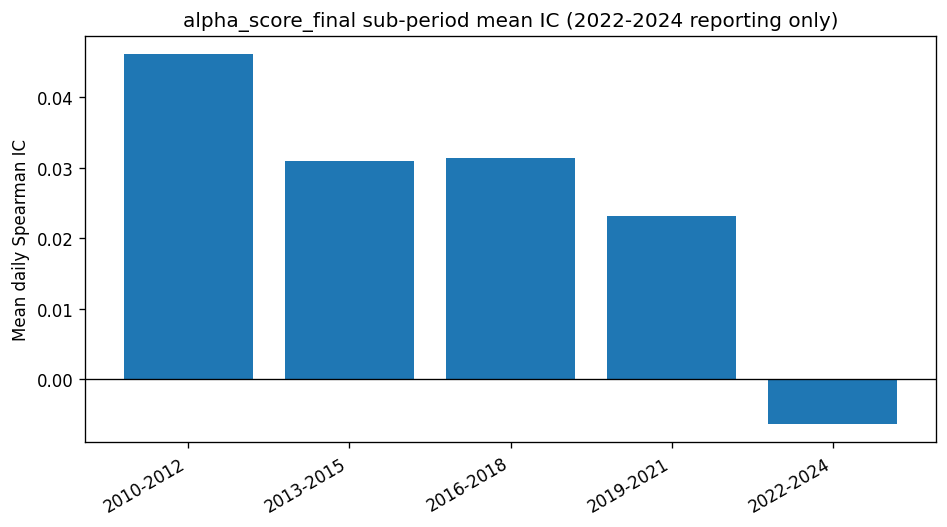

,vol_regime,mean_ic,icir,positive_ic_day_fraction,n_days
0,low_vol,0.0233,2.6777,0.6030,1252
1,mid_vol,0.0218,1.9128,0.5824,1250
2,high_vol,0.0295,1.8767,0.5639,1252


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step4/fig_step4_vol_regime_mean_ic.png


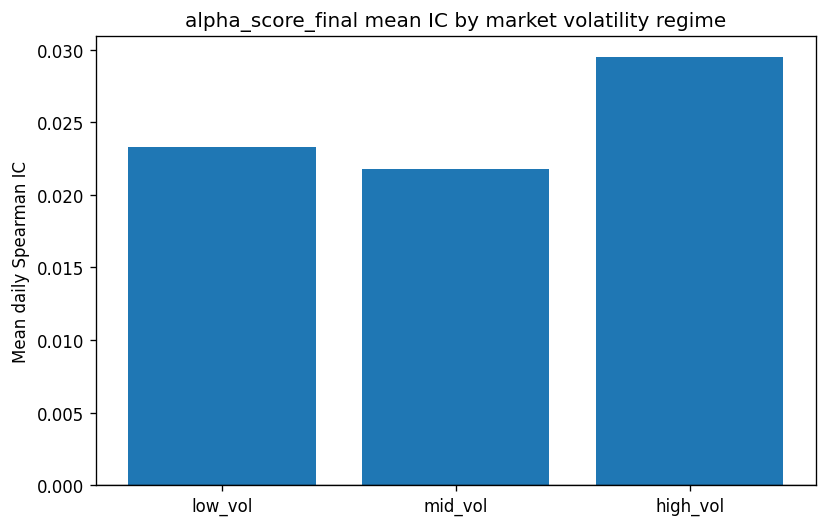

In [55]:
# ============================================================
# Step 4 additional brief diagnostics: feature-group ablation and IC stability
# ============================================================
print("Step 4 additional diagnostics: feature-group ablation and IC stability (reporting only).")
step4_fig_dir = FIG_DIR / "step4"
step4_fig_dir.mkdir(parents=True, exist_ok=True)

def _signed_feature_series(df, feature, sign=1.0):
    zcol = feature + "_z"
    if zcol not in df.columns:
        print(f"WARNING: feature missing for group ablation and skipped: {feature}")
        return None
    return sign * df[zcol]

feature_group_specs = {
    "reversal": [("overnight_ret_1d_lag1", -1), ("intraday_ret_1d_lag1", -1), ("close_to_close_ret_1d_lag1", -1), ("ret_3d_lag1", -1), ("ret_5d_lag1", -1), ("resid_intraday_ret_1d_lag1", -1), ("resid_close_to_close_ret_1d_lag1", -1)],
    "liquidity_volatility": [("volume_ratio_20d_lag1", 1), ("dollar_volume_ratio_20d_lag1", 1), ("log_adv20_dollar_lag1", 1), ("realized_vol_20d_lag1", -1), ("high_low_range_lag1", -1), ("abs_intraday_shock_lag1", -1)],
    "short_borrow": [("dsi_pit", -1), ("dtcn_pit", -1), ("ddtcn_pit", -1), ("htb_score_pct_pit", -1), ("borrow_bps_pa", -1)],
    "size_liquidity_controls": [("log_market_cap_lag1", 1), ("adv20_dollar", 1), ("realized_vol_20d_lag1", -1)],
}
group_signal_cols = []
for group_name, specs in feature_group_specs.items():
    parts = []
    for feat, sign in specs:
        s = _signed_feature_series(alpha, feat, sign)
        if s is not None:
            parts.append(s.rename(feat))
    if parts:
        raw_col = f"group_signal_{group_name}_raw"
        col = f"group_signal_{group_name}"
        alpha[raw_col] = pd.concat(parts, axis=1).mean(axis=1)
        alpha[col] = cs_winsor_zscore(alpha, raw_col)
        group_signal_cols.append(col)
    else:
        print(f"WARNING: no available features for group {group_name}; skipped.")
if "alpha_score_final" in alpha.columns:
    group_signal_cols.append("alpha_score_final")

def _ic_summary_for_signal(df, signal_col, label):
    ic = daily_spearman_ic(df, signal_col)
    ic["period"] = period_from_date(ic["date"])
    rows = []
    masks = {"full_2010_2024": ic["date"].between(DEV_START, DEV_END)}
    masks.update({p: ic["period"].eq(p) for p in ["train", "validation", "development_test"]})
    for period_name, mask in masks.items():
        vals = ic.loc[mask, "ic"].dropna()
        rows.append({
            "signal_group": label,
            "period": period_name,
            "mean_ic": vals.mean(),
            "median_ic": vals.median(),
            "ic_std": vals.std(ddof=1),
            "icir": vals.mean() / vals.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR) if len(vals) > 1 and vals.std(ddof=1) > 0 else np.nan,
            "positive_ic_day_fraction": (vals > 0).mean() if len(vals) else np.nan,
            "n_days": len(vals),
        })
    return pd.DataFrame(rows), ic

ablation_parts = []
for col in group_signal_cols:
    label = col.replace("group_signal_", "") if col != "alpha_score_final" else "full_regularised_linear"
    sm, _ = _ic_summary_for_signal(alpha, col, label)
    ablation_parts.append(sm)
step4_feature_group_ablation_ic = pd.concat(ablation_parts, ignore_index=True)
display(step4_feature_group_ablation_ic.round(4))
step4_feature_group_ablation_ic.to_csv(out_path("step4_feature_group_ablation_ic.csv"), index=False)

for metric, fname, title in [
    ("mean_ic", "fig_step4_feature_group_mean_ic_by_period.png", "Feature group mean IC by period"),
    ("icir", "fig_step4_feature_group_icir_by_period.png", "Feature group ICIR by period"),
]:
    plot_df = step4_feature_group_ablation_ic[step4_feature_group_ablation_ic["period"].isin(["train", "validation", "development_test"])].pivot(index="signal_group", columns="period", values=metric)
    fig, ax = plt.subplots(figsize=(10, 4.8))
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title + " (development-test reporting only)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel(metric)
    save_and_show(fig, step4_fig_dir / fname)

selected_ic = daily_spearman_ic(alpha, "alpha_score_final")
selected_ic["subperiod"] = pd.cut(
    selected_ic["date"],
    bins=[pd.Timestamp("2009-12-31"), pd.Timestamp("2012-12-31"), pd.Timestamp("2015-12-31"), pd.Timestamp("2018-12-31"), pd.Timestamp("2021-12-31"), pd.Timestamp("2024-12-31")],
    labels=["2010-2012", "2013-2015", "2016-2018", "2019-2021", "2022-2024"],
)
sub_rows = []
for name, vals0 in selected_ic.groupby("subperiod", observed=True):
    vals = vals0["ic"].dropna()
    sub_rows.append({"subperiod": str(name), "mean_ic": vals.mean(), "icir": vals.mean()/vals.std(ddof=1)*np.sqrt(TRADING_DAYS_PER_YEAR) if len(vals)>1 and vals.std(ddof=1)>0 else np.nan, "positive_ic_day_fraction": (vals>0).mean() if len(vals) else np.nan, "n_days": len(vals)})
step4_subperiod_ic_stability = pd.DataFrame(sub_rows)
display(step4_subperiod_ic_stability.round(4))
step4_subperiod_ic_stability.to_csv(out_path("step4_subperiod_ic_stability.csv"), index=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(step4_subperiod_ic_stability["subperiod"], step4_subperiod_ic_stability["mean_ic"])
ax.set_title("alpha_score_final sub-period mean IC (2022-2024 reporting only)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean daily Spearman IC")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
save_and_show(fig, step4_fig_dir / "fig_step4_subperiod_mean_ic.png")

mkt_daily = panel.loc[panel["eligible"], ["date", "r_cc"]].dropna().groupby("date")["r_cc"].mean().reset_index(name="ew_market_r_cc")
mkt_daily["market_vol20"] = mkt_daily["ew_market_r_cc"].rolling(20, min_periods=20).std()
mkt_daily["vol_regime"] = pd.qcut(mkt_daily["market_vol20"], q=3, labels=["low_vol", "mid_vol", "high_vol"], duplicates="drop")
selected_ic = selected_ic.merge(mkt_daily[["date", "vol_regime"]], on="date", how="left")
reg_rows = []
for name, vals0 in selected_ic.groupby("vol_regime", observed=True):
    vals = vals0["ic"].dropna()
    reg_rows.append({"vol_regime": str(name), "mean_ic": vals.mean(), "icir": vals.mean()/vals.std(ddof=1)*np.sqrt(TRADING_DAYS_PER_YEAR) if len(vals)>1 and vals.std(ddof=1)>0 else np.nan, "positive_ic_day_fraction": (vals>0).mean() if len(vals) else np.nan, "n_days": len(vals)})
step4_vol_regime_ic_stability = pd.DataFrame(reg_rows)
display(step4_vol_regime_ic_stability.round(4))
step4_vol_regime_ic_stability.to_csv(out_path("step4_vol_regime_ic_stability.csv"), index=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(step4_vol_regime_ic_stability["vol_regime"], step4_vol_regime_ic_stability["mean_ic"])
ax.set_title("alpha_score_final mean IC by market volatility regime")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean daily Spearman IC")
save_and_show(fig, step4_fig_dir / "fig_step4_vol_regime_mean_ic.png")


# Step 5 - Final Headline Portfolio (Enhanced Alpha Only)

Step 5 uses only `alpha_score_final`. Headline selection is fixed at 250m AUM with `weighting=equal`, `short_treatment=tiered`, and the pre-specified basket fractions `[1%, 2.5%, 5%, 10%]`. After validation-only basket selection, the same configuration is reported for 50m, 250m, and 1b.


In [56]:
# ============================================================
# Step 5 - Final portfolio construction using alpha_score_final only
# ============================================================
print("Step 5: running final Enhanced Alpha portfolio construction...")

SCORE_COL = FINAL_SCORE_COL
HEADLINE_AUM = AUM_LEVELS[HEADLINE_AUM_LABEL]
FINAL_WEIGHTING = "equal"
FINAL_SHORT_TREATMENT = "tiered"
SELECTION_BASKETS = [0.01, 0.025, 0.05, 0.10]

assert SCORE_COL == "alpha_score_final", "Step5 must use alpha_score_final as the only headline score column."
assert "signal_weak_alpha_baseline" not in alpha_scores.columns, "Weak alpha baseline must not be passed to Step5 alpha_scores."
required_step5_alpha_cols = ["date", "instrument_id", "ticker", SCORE_COL, TARGET_COL, "period"]
missing_alpha_cols = [c for c in required_step5_alpha_cols if c not in alpha_scores.columns]
assert not missing_alpha_cols, f"Step5 missing required alpha score columns: {missing_alpha_cols}"

# Performance helpers.
def max_drawdown(r):
    r = pd.Series(r).dropna()
    if r.empty:
        return np.nan
    wealth = (1.0 + r).cumprod()
    return (wealth / wealth.cummax() - 1.0).min()

def ann_return(r):
    r = pd.Series(r).dropna()
    return (1.0 + r).prod() ** (TRADING_DAYS_PER_YEAR / len(r)) - 1.0 if len(r) else np.nan

def sharpe(r):
    r = pd.Series(r).dropna()
    sd = r.std(ddof=1)
    return r.mean() / sd * np.sqrt(TRADING_DAYS_PER_YEAR) if len(r) > 1 and sd > 0 else np.nan

def prepare_score_aum_final(aum_label):
    elig_cols = [
        "date", "instrument_id", "aum_level", "aum_dollar", "is_prelim_tradable", "prelim_eligibility_reason",
        "adv20_dollar", "adv_cap_notional", "vol20_daily", "prelim_capacity_ratio", "prelim_cap_binding",
    ]
    missing_elig = [c for c in elig_cols if c not in step2.columns]
    assert not missing_elig, f"Step5 missing Step2 eligibility columns: {missing_elig}"
    elig = step2.loc[step2["aum_level"].eq(aum_label), elig_cols].copy()
    x = alpha_scores.merge(elig, on=["date", "instrument_id"], how="inner", suffixes=("", "_step2"))
    if "adv20_dollar_step2" in x.columns:
        x["adv20_dollar"] = x["adv20_dollar_step2"]
    borrow_extra_cols = ["date", "instrument_id", "borrow_tier", "borrow_cost_annual_bps", "borrow_daily_rate", "high_si_flag", "tier_c_flag", "dsi", "dtcn", "ddtcn", "short_interest_pct_float", "days_to_cover", "si_missing"]
    borrow = step3[[c for c in borrow_extra_cols if c in step3.columns]].copy()
    x = x.merge(borrow, on=["date", "instrument_id"], how="left", suffixes=("", "_step3"))
    if "borrow_tier_step3" in x.columns:
        x["borrow_tier"] = x["borrow_tier_step3"].combine_first(x.get("borrow_tier"))
    x["borrow_tier"] = x["borrow_tier"].fillna("A")
    x["borrow_bps_pa"] = x.get("borrow_bps_pa", pd.Series(np.nan, index=x.index)).fillna(x["borrow_cost_annual_bps"]).fillna(BORROW_COST_BPS_PA["A"]).astype(float)
    x["borrow_daily_rate"] = x["borrow_daily_rate"].fillna(x["borrow_bps_pa"] / 10000 / TRADING_DAYS_PER_YEAR)
    x = x[
        x["is_prelim_tradable"].eq(True)
        & x["prelim_eligibility_reason"].eq("OK")
        & x[SCORE_COL].notna()
        & x[TARGET_COL].notna()
        & x["adv_cap_notional"].notna()
        & x["adv20_dollar"].notna()
    ].copy()
    x["period"] = period_from_date(x["date"])
    x = x[x["period"].ne("outside")].copy()
    x = x.sort_values(["date", SCORE_COL, "instrument_id"]).reset_index(drop=True)
    x["_n_day"] = x.groupby("date")["instrument_id"].transform("size")
    assert x["date"].max() <= DEV_END, f"Prepared Step5 data for {aum_label} contains data after {DEV_END.date()}."
    return x

def side_raw_weights(side_df, side):
    if FINAL_WEIGHTING != "equal":
        raise ValueError(f"Final weighting must be equal, got {FINAL_WEIGHTING}")
    return pd.Series(1.0 / len(side_df), index=side_df.index) if len(side_df) else pd.Series(dtype=float)

def allocate_side_with_adv_cap(side_df, side_notional, side):
    x = side_df.copy()
    if x.empty:
        x["abs_position_notional"] = []
        return x, side_notional, False
    cap = pd.to_numeric(x["adv_cap_notional"], errors="coerce").fillna(0.0).clip(lower=0.0).to_numpy(float)
    target = min(float(side_notional), float(np.nansum(cap)))
    alloc = np.zeros(len(x), dtype=float)
    remaining = target
    open_mask = cap > 1e-7
    binding_seen = target < float(side_notional)
    # Iterative pro-rata redistribution for equal weights: capped names are removed and residual notional
    # is redistributed to uncapped names until no cap binds or the basket cannot absorb more notional.
    for _ in range(len(x) + 1):
        if remaining <= 1e-6 or not open_mask.any():
            break
        proposed = remaining / open_mask.sum()
        room = cap - alloc
        capped_now = open_mask & (room <= proposed + 1e-9)
        if not capped_now.any():
            alloc[open_mask] += proposed
            remaining = 0.0
            break
        increment = np.zeros(len(x), dtype=float)
        increment[capped_now] = np.maximum(room[capped_now], 0.0)
        uncapped_now = open_mask & (~capped_now)
        increment[uncapped_now] = proposed
        alloc += increment
        remaining = max(target - float(alloc.sum()), 0.0)
        open_mask = (cap - alloc) > 1e-7
        binding_seen = True
    x["abs_position_notional"] = np.clip(np.minimum(alloc, cap), 0.0, None)
    unused = max(float(side_notional - x["abs_position_notional"].sum()), 0.0)
    return x, unused, binding_seen

def select_daily_baskets(day, basket_frac):
    n = len(day)
    n_side = max(1, int(np.floor(n * basket_frac)))
    ranked = day.sort_values([SCORE_COL, "instrument_id"], ascending=[True, True])
    shorts = ranked.head(n_side).copy()
    longs = ranked.tail(n_side).copy()
    return longs, shorts

def build_portfolio_final(score_aum, aum_label, basket_frac, store_positions=False):
    aum = AUM_LEVELS[aum_label]
    side_target = 0.5 * aum
    pos_parts = []
    daily_rows = []
    no_trade_rows = []
    for dt, day in score_aum.groupby("date", sort=True):
        longs, shorts = select_daily_baskets(day, basket_frac)
        if longs.empty or shorts.empty:
            no_trade_rows.append({"date": dt, "aum_level": aum_label, "basket_frac": basket_frac, "reason": "empty_long_or_short_basket"})
            continue
        longs, long_unused, long_binding = allocate_side_with_adv_cap(longs, side_target, "long")
        shorts, short_unused, short_binding = allocate_side_with_adv_cap(shorts, side_target, "short")
        long_sum = longs["abs_position_notional"].sum()
        short_sum = shorts["abs_position_notional"].sum()
        deployed_side = min(long_sum, short_sum)
        if deployed_side <= 1e-8:
            no_trade_rows.append({"date": dt, "aum_level": aum_label, "basket_frac": basket_frac, "reason": "zero_capacity_after_adv_cap"})
            continue
        if long_sum > deployed_side:
            longs["abs_position_notional"] *= deployed_side / long_sum
        if short_sum > deployed_side:
            shorts["abs_position_notional"] *= deployed_side / short_sum
        longs["side"] = "long"
        shorts["side"] = "short"
        p = pd.concat([longs, shorts], ignore_index=True)
        p = p[p["abs_position_notional"] > 1e-8].copy()
        if p.empty or not {"long", "short"}.issubset(set(p["side"])):
            no_trade_rows.append({"date": dt, "aum_level": aum_label, "basket_frac": basket_frac, "reason": "one_side_empty_after_cap"})
            continue
        p["position_notional"] = np.where(p["side"].eq("long"), p["abs_position_notional"], -p["abs_position_notional"])
        p["actual_position_over_adv"] = p["abs_position_notional"] / p["adv20_dollar"].replace(0, np.nan)
        p["actual_cap_binding"] = p["abs_position_notional"] >= (p["adv_cap_notional"] - 1e-6)
        p["gross_pnl"] = p["position_notional"] * p[TARGET_COL]
        p["commission_cost"] = p["abs_position_notional"] * 2.0 * COMMISSION_BPS_PER_LEG / 10000.0
        p["slippage_cost"] = p["abs_position_notional"] * 2.0 * AUCTION_SLIPPAGE_BPS_PER_LEG / 10000.0
        p["borrow_cost"] = np.where(p["side"].eq("short"), p["abs_position_notional"] * p["borrow_daily_rate"], 0.0)
        p["net_pnl"] = p["gross_pnl"] - p["commission_cost"] - p["slippage_cost"] - p["borrow_cost"]
        p["aum_level"] = aum_label
        p["aum"] = aum
        p["basket_frac"] = basket_frac
        p["weighting"] = FINAL_WEIGHTING
        p["short_treatment"] = FINAL_SHORT_TREATMENT
        p["participation_cap"] = PARTICIPATION_CAP
        p["selected_final_signal_col"] = selected_final_signal_col
        long_notional = p.loc[p["side"].eq("long"), "abs_position_notional"].sum()
        short_notional = p.loc[p["side"].eq("short"), "abs_position_notional"].sum()
        gross = long_notional + short_notional
        assert abs(long_notional - short_notional) <= 1e-4, f"Dollar-neutrality failed before costs on {dt}: long={long_notional}, short={short_notional}"
        assert (p["abs_position_notional"] <= p["adv_cap_notional"] + 1e-4).all(), f"ADV cap breach on {dt}."
        daily_rows.append({
            "date": dt,
            "aum_level": aum_label,
            "aum": aum,
            "basket_frac": basket_frac,
            "weighting": FINAL_WEIGHTING,
            "short_treatment": FINAL_SHORT_TREATMENT,
            "gross_pnl": p["gross_pnl"].sum(),
            "net_pnl": p["net_pnl"].sum(),
            "commission_cost": p["commission_cost"].sum(),
            "slippage_cost": p["slippage_cost"].sum(),
            "borrow_cost": p["borrow_cost"].sum(),
            "long_gross_pnl": p.loc[p["side"].eq("long"), "gross_pnl"].sum(),
            "short_gross_pnl": p.loc[p["side"].eq("short"), "gross_pnl"].sum(),
            "long_notional": long_notional,
            "short_notional": short_notional,
            "gross_exposure": gross,
            "deployed_gross_ratio": gross / aum,
            "unused_gross_notional": max(aum - gross, 0.0),
            "long_names": int((p["side"] == "long").sum()),
            "short_names": int((p["side"] == "short").sum()),
            "capacity_binding_frequency": float(p["actual_cap_binding"].any()),
            "any_stock_adv_cap_binding": bool(p["actual_cap_binding"].any()),
            "turnover": gross * 2.0 / aum,
            "long_unused_pre_neutralize": long_unused,
            "short_unused_pre_neutralize": short_unused,
            "side_capacity_binding_pre_neutralize": bool(long_binding or short_binding),
        })
        if store_positions:
            pos_parts.append(p)
    daily = pd.DataFrame(daily_rows)
    if not daily.empty:
        daily["period"] = period_from_date(daily["date"])
        daily["gross_return"] = daily["gross_pnl"] / daily["aum"]
        daily["net_return"] = daily["net_pnl"] / daily["aum"]
        daily["transaction_cost"] = daily["commission_cost"] + daily["slippage_cost"]
        daily["total_cost"] = daily["transaction_cost"] + daily["borrow_cost"]
        daily["cost_drag"] = daily["total_cost"] / daily["aum"]
    positions = pd.concat(pos_parts, ignore_index=True) if store_positions and pos_parts else pd.DataFrame()
    no_trade = pd.DataFrame(no_trade_rows)
    return positions, daily, no_trade

def perf_summary_by_period(daily, extra=None):
    rows = []
    if daily.empty:
        return pd.DataFrame(rows)
    for pname in ["train", "validation", "development_test"]:
        d = daily[daily["period"].eq(pname)].copy()
        if d.empty:
            continue
        row = {
            "period": pname,
            "n_days": len(d),
            "gross_return": ann_return(d["gross_return"]),
            "net_return": ann_return(d["net_return"]),
            "gross_cumulative_return": (1.0 + d["gross_return"].fillna(0)).prod() - 1.0,
            "net_cumulative_return": (1.0 + d["net_return"].fillna(0)).prod() - 1.0,
            "gross_sharpe": sharpe(d["gross_return"]),
            "net_sharpe": sharpe(d["net_return"]),
            "max_drawdown": max_drawdown(d["net_return"]),
            "turnover": d["turnover"].mean(),
            "cost_drag": d["cost_drag"].mean() * TRADING_DAYS_PER_YEAR,
            "deployed_gross_ratio": d["deployed_gross_ratio"].mean(),
            "capacity_binding_frequency": d["capacity_binding_frequency"].mean(),
            "avg_long_names": d["long_names"].mean(),
            "avg_short_names": d["short_names"].mean(),
        }
        if extra:
            row.update(extra)
        rows.append(row)
    return pd.DataFrame(rows)

def perf_summary_full(daily, extra=None):
    d = daily.copy()
    row = {
        "period": "full_2010_2024",
        "n_days": len(d),
        "gross_return": ann_return(d["gross_return"]),
        "net_return": ann_return(d["net_return"]),
        "gross_cumulative_return": (1.0 + d["gross_return"].fillna(0)).prod() - 1.0,
        "net_cumulative_return": (1.0 + d["net_return"].fillna(0)).prod() - 1.0,
        "gross_sharpe": sharpe(d["gross_return"]),
        "net_sharpe": sharpe(d["net_return"]),
        "max_drawdown": max_drawdown(d["net_return"]),
        "turnover": d["turnover"].mean(),
        "cost_drag": d["cost_drag"].mean() * TRADING_DAYS_PER_YEAR,
        "deployed_gross_ratio": d["deployed_gross_ratio"].mean(),
        "capacity_binding_frequency": d["capacity_binding_frequency"].mean(),
    }
    if extra:
        row.update(extra)
    return pd.DataFrame([row])

# First stage: 250m validation-only basket selection, four full backtests.
score_250 = prepare_score_aum_final(HEADLINE_AUM_LABEL)
selection_perf_parts = []
selection_daily_by_basket = {}
selection_no_trade_parts = []
for basket_frac in SELECTION_BASKETS:
    print(f"Running basket {basket_frac:.2%} at headline AUM 250m")
    _, d, nt = build_portfolio_final(score_250, HEADLINE_AUM_LABEL, basket_frac, store_positions=False)
    assert not d.empty, f"Step5 selection backtest produced no daily returns for basket {basket_frac:.2%}."
    selection_daily_by_basket[basket_frac] = d
    if not nt.empty:
        selection_no_trade_parts.append(nt)
    selection_perf_parts.append(perf_summary_by_period(d, {"aum_level": HEADLINE_AUM_LABEL, "basket_frac": basket_frac, "weighting": FINAL_WEIGHTING, "short_treatment": FINAL_SHORT_TREATMENT}))
selection_grid = pd.concat(selection_perf_parts, ignore_index=True)

final_signal_val_ic = signal_ic_summary[(signal_ic_summary["signal"].eq(selected_final_signal_col)) & (signal_ic_summary["period"].eq("validation"))]["mean_ic"]
final_signal_val_ic = float(final_signal_val_ic.iloc[0]) if len(final_signal_val_ic) else np.nan
validation_grid = selection_grid[selection_grid["period"].eq("validation")].copy()
validation_grid["validation_ic"] = final_signal_val_ic
assert not validation_grid.empty, "Step5 basket selection has no validation rows."

max_val_sharpe = validation_grid["net_sharpe"].max()
selection_pool = validation_grid[
    validation_grid["net_sharpe"].ge(max_val_sharpe - 0.25)
    & validation_grid["deployed_gross_ratio"].ge(0.50)
].copy()
if selection_pool.empty:
    selection_pool = validation_grid.copy()
selection_pool = selection_pool.sort_values(
    ["capacity_binding_frequency", "cost_drag", "turnover", "deployed_gross_ratio", "net_sharpe"],
    ascending=[True, True, True, False, False],
)
selected_basket = float(selection_pool.iloc[0]["basket_frac"])
basket_selection_reason = (
    f"Selected basket_frac={selected_basket:.2%} on 250m validation only. Candidates within 0.25 validation net Sharpe "
    "of the best were compared on capacity binding, cost drag, turnover, and deployed gross ratio."
)

selected_config = {
    "final_alpha_score_col": SCORE_COL,
    "selected_final_signal_col": selected_final_signal_col,
    "headline_aum_label": HEADLINE_AUM_LABEL,
    "headline_aum": HEADLINE_AUM,
    "basket_frac": selected_basket,
    "weighting": FINAL_WEIGHTING,
    "short_treatment": FINAL_SHORT_TREATMENT,
    "participation_cap": PARTICIPATION_CAP,
    "basket_selection_reason": basket_selection_reason,
}
print(basket_selection_reason)
display(selection_grid.round(4))
display(pd.DataFrame([selected_config]))

# Second stage: fixed final strategy AUM sensitivity.
final_daily_by_aum = {}
final_positions_250m = pd.DataFrame()
final_no_trade_parts = []
aum_perf_parts = []
for aum_label in ["50m", "250m", "1b"]:
    print(f"Running AUM sensitivity {aum_label}")
    score_aum = score_250 if aum_label == HEADLINE_AUM_LABEL else prepare_score_aum_final(aum_label)
    store_positions = aum_label == HEADLINE_AUM_LABEL
    pos, d, nt = build_portfolio_final(score_aum, aum_label, selected_basket, store_positions=store_positions)
    assert not d.empty, f"Final AUM sensitivity backtest produced no daily returns for {aum_label}."
    final_daily_by_aum[aum_label] = d
    if store_positions:
        final_positions_250m = pos
    if not nt.empty:
        final_no_trade_parts.append(nt)
    aum_perf_parts.append(perf_summary_full(d, {"aum_level": aum_label, "basket_frac": selected_basket, "weighting": FINAL_WEIGHTING, "short_treatment": FINAL_SHORT_TREATMENT}))

aum_sensitivity = pd.concat(aum_perf_parts, ignore_index=True)
headline_daily = final_daily_by_aum[HEADLINE_AUM_LABEL].copy()
headline_performance_summary = perf_summary_by_period(headline_daily, {"aum_level": HEADLINE_AUM_LABEL, "basket_frac": selected_basket, "weighting": FINAL_WEIGHTING, "short_treatment": FINAL_SHORT_TREATMENT})
no_trade_days = pd.concat(final_no_trade_parts + selection_no_trade_parts, ignore_index=True) if (final_no_trade_parts or selection_no_trade_parts) else pd.DataFrame(columns=["date", "aum_level", "basket_frac", "reason"])

assert not final_positions_250m.empty, "Step5 positions output is empty for headline 250m strategy."
assert final_positions_250m["is_prelim_tradable"].all(), "Step5 positions include rows outside Step2 tradable universe."
assert final_positions_250m["prelim_eligibility_reason"].eq("OK").all(), "Step5 positions include non-OK Step2 eligibility rows."
assert (final_positions_250m["abs_position_notional"] <= final_positions_250m["adv_cap_notional"] + 1e-4).all(), "Step5 positions breach 5% ADV cap."
assert final_positions_250m[SCORE_COL].notna().all(), "Step5 positions contain null alpha_score_final."
assert final_positions_250m[TARGET_COL].notna().all(), "Step5 positions contain null target_next_overnight."
assert np.allclose(headline_daily["long_notional"], headline_daily["short_notional"], rtol=1e-8, atol=1e-4), "Headline 250m daily portfolio is not dollar-neutral before costs."
assert (headline_daily["gross_exposure"] <= HEADLINE_AUM + 1e-4).all(), "Headline 250m gross exposure exceeds AUM after ADV cap allocation."
assert headline_daily["date"].max() <= DEV_END, f"Headline Step5 daily returns contain data after {DEV_END.date()}."

# Save requested outputs.
selection_grid.to_csv(out_path("step5_headline_selection_grid.csv"), index=False)
headline_daily.to_csv(out_path("step5_headline_daily_returns.csv"), index=False)
final_positions_250m.to_parquet(out_path("step5_positions.parquet"), index=False)
aum_sensitivity.to_csv(out_path("step5_aum_sensitivity.csv"), index=False)
headline_performance_summary.to_csv(out_path("step5_headline_performance_summary.csv"), index=False)
no_trade_days.to_csv(out_path("step5_no_trade_days.csv"), index=False)
Path(out_path("step5_selected_headline_config.json")).write_text(json.dumps(selected_config, indent=2))

# QuantStats deliverable: true package-generated 250m report benchmarked against SP500_TR.
quantstats_package_success = False
quantstats_benchmark_success = False
quantstats_error = ""
qs_path = out_path("quantstats_250m_vs_sp500_tr.html")
quantstats_fallback_path = OUT_DIR / "quantstats_fallback_summary_250m.html"
try:
    import quantstats as qs
    strat_qs = headline_daily.set_index("date")["net_return"].astype(float).sort_index()
    bench_df = sp500_tr.copy()
    if "benchmark_return" not in bench_df.columns:
        bench_df = bench_df.sort_values("date")
        bench_df["benchmark_return"] = bench_df["adjusted_close"].pct_change()
    benchmark_qs = bench_df.set_index("date")["benchmark_return"].astype(float).sort_index()
    aligned_qs = pd.concat([strat_qs.rename("strategy"), benchmark_qs.rename("benchmark")], axis=1).dropna()
    aligned_qs = aligned_qs.loc[(aligned_qs.index >= DEV_START) & (aligned_qs.index <= DEV_END)]
    assert len(aligned_qs) > 250, "QuantStats benchmark alignment has too few observations."
    qs.reports.html(
        aligned_qs["strategy"],
        benchmark=aligned_qs["benchmark"],
        output=str(qs_path),
        title="C2O Enhanced Alpha Headline Strategy - 250m vs SP500_TR",
    )
    quantstats_package_success = True
    quantstats_benchmark_success = Path(qs_path).exists() and len(aligned_qs) > 250
except Exception as e:
    quantstats_error = repr(e)
    fallback_rows = headline_performance_summary[["period", "gross_return", "net_return", "gross_sharpe", "net_sharpe", "max_drawdown", "deployed_gross_ratio", "capacity_binding_frequency"]].to_html(index=False, float_format=lambda x: f"{x:.4f}")
    Path(quantstats_fallback_path).write_text(
        "<html><head><title>C2O QuantStats fallback summary</title></head><body>"
        "<h1>Fallback summary: QuantStats benchmark report failed</h1>"
        f"<p>Error: {quantstats_error}</p>"
        f"{fallback_rows}"
        "</body></html>"
    )
    generated_files.append(str(Path(quantstats_fallback_path).resolve()))
qs_success = quantstats_package_success and quantstats_benchmark_success and Path(qs_path).exists()
qs_error = quantstats_error
print(f"QuantStats benchmark output file: {Path(qs_path).resolve()} (package_success={quantstats_package_success}, benchmark_success={quantstats_benchmark_success}, error={quantstats_error})")

# Final display summary required by the brief.
print("\nFinal alpha used:")
print(f"  score column = {SCORE_COL}")
print(f"  selected final_signal_col = {selected_final_signal_col}")
print("\nFinal headline configuration:")
print(f"  AUM = {HEADLINE_AUM_LABEL} ({HEADLINE_AUM:,.0f})")
print(f"  basket_frac = {selected_basket:.2%}")
print(f"  weighting = {FINAL_WEIGHTING}")
print(f"  short_treatment = {FINAL_SHORT_TREATMENT}")
print(f"  participation_cap = {PARTICIPATION_CAP:.0%} ADV")

headline_perf_print = headline_performance_summary[["period", "gross_return", "net_return", "gross_sharpe", "net_sharpe"]].copy()
print("\nHeadline 250m performance:")
display(headline_perf_print.round(4))
print("\nAUM comparison:")
display(aum_sensitivity[["aum_level", "gross_return", "net_return", "net_sharpe", "deployed_gross_ratio", "capacity_binding_frequency"]].round(4))


Step 5: running final Enhanced Alpha portfolio construction...
Running basket 1.00% at headline AUM 250m
Running basket 2.50% at headline AUM 250m
Running basket 5.00% at headline AUM 250m
Running basket 10.00% at headline AUM 250m
Selected basket_frac=1.00% on 250m validation only. Candidates within 0.25 validation net Sharpe of the best were compared on capacity binding, cost drag, turnover, and deployed gross ratio.


,period,n_days,gross_return,net_return,gross_cumulative_return,net_cumulative_return,gross_sharpe,net_sharpe,max_drawdown,turnover,cost_drag,deployed_gross_ratio,capacity_binding_frequency,avg_long_names,avg_short_names,aum_level,basket_frac,weighting,short_treatment
0,train,2244,0.0334,0.0081,0.3394,0.0741,1.5804,0.3950,-0.0986,0.4482,0.0248,0.2241,1.0,8.2821,8.2821,250m,0.010,equal,tiered
1,validation,757,0.1621,0.1085,0.5703,0.3625,1.9876,1.3778,-0.0499,0.8361,0.0473,0.4180,1.0,8.7635,8.7635,250m,0.010,equal,tiered
2,development_test,752,0.0590,0.0073,0.1865,0.0219,0.8816,0.1412,-0.0880,0.9042,0.0501,0.4521,1.0,8.7726,8.7726,250m,0.010,equal,tiered
3,train,2244,0.0662,0.0010,0.7693,0.0085,2.0577,0.0460,-0.1859,1.1499,0.0631,0.5750,1.0,21.4906,21.4906,250m,0.025,equal,tiered
4,validation,757,0.1857,0.0751,0.6682,0.2430,1.5799,0.7036,-0.1220,1.7443,0.0980,0.8722,1.0,23.0911,23.0911,250m,0.025,equal,tiered
5,development_test,752,0.0477,-0.0509,0.1491,-0.1443,0.6308,-0.6241,-0.2058,1.7825,0.0988,0.8912,1.0,23.1197,23.1197,250m,0.025,equal,tiered
6,train,2244,0.0990,-0.0076,1.3173,-0.0656,2.6314,-0.1927,-0.2260,1.8646,0.1020,0.9323,1.0,43.4906,43.4906,250m,0.050,equal,tiered
7,validation,757,0.1380,0.0183,0.4745,0.0559,1.4685,0.2444,-0.1620,1.9950,0.1112,0.9975,1.0,46.7517,46.7517,250m,0.050,equal,tiered
8,development_test,752,0.0300,-0.0785,0.0922,-0.2164,0.4678,-1.1651,-0.2459,1.9987,0.1113,0.9994,1.0,46.9282,46.9282,250m,0.050,equal,tiered
9,train,2244,0.0955,-0.0177,1.2529,-0.1469,3.0405,-0.5767,-0.2182,1.9999,0.1091,1.0000,1.0,87.4933,87.4933,250m,0.100,equal,tiered


,final_alpha_score_col,selected_final_signal_col,headline_aum_label,headline_aum,basket_frac,weighting,short_treatment,participation_cap,basket_selection_reason
0,alpha_score_final,signal_regularised_linear,250m,250000000,0.01,equal,tiered,0.05,Selected basket_frac=1.00% on 250m validation ...


Running AUM sensitivity 50m
Running AUM sensitivity 250m
Running AUM sensitivity 1b
QuantStats benchmark output file: /Users/cuiyufan/Desktop/ml data/c2o_outputs/quantstats_250m_vs_sp500_tr.html (package_success=True, benchmark_success=True, error=)

Final alpha used:
  score column = alpha_score_final
  selected final_signal_col = signal_regularised_linear

Final headline configuration:
  AUM = 250m (250,000,000)
  basket_frac = 1.00%
  weighting = equal
  short_treatment = tiered
  participation_cap = 5% ADV

Headline 250m performance:


,period,gross_return,net_return,gross_sharpe,net_sharpe
0,train,0.0334,0.0081,1.5804,0.3950
1,validation,0.1621,0.1085,1.9876,1.3778
2,development_test,0.0590,0.0073,0.8816,0.1412



AUM comparison:


,aum_level,gross_return,net_return,net_sharpe,deployed_gross_ratio,capacity_binding_frequency
0,50m,0.1196,0.0158,0.2204,0.8606,0.9947
1,250m,0.0633,0.0274,0.5796,0.3089,1.0000
2,1b,0.0174,0.0077,0.5016,0.0865,1.0000


STEP 5 VISUALISATION: HEADLINE STRATEGY PERFORMANCE


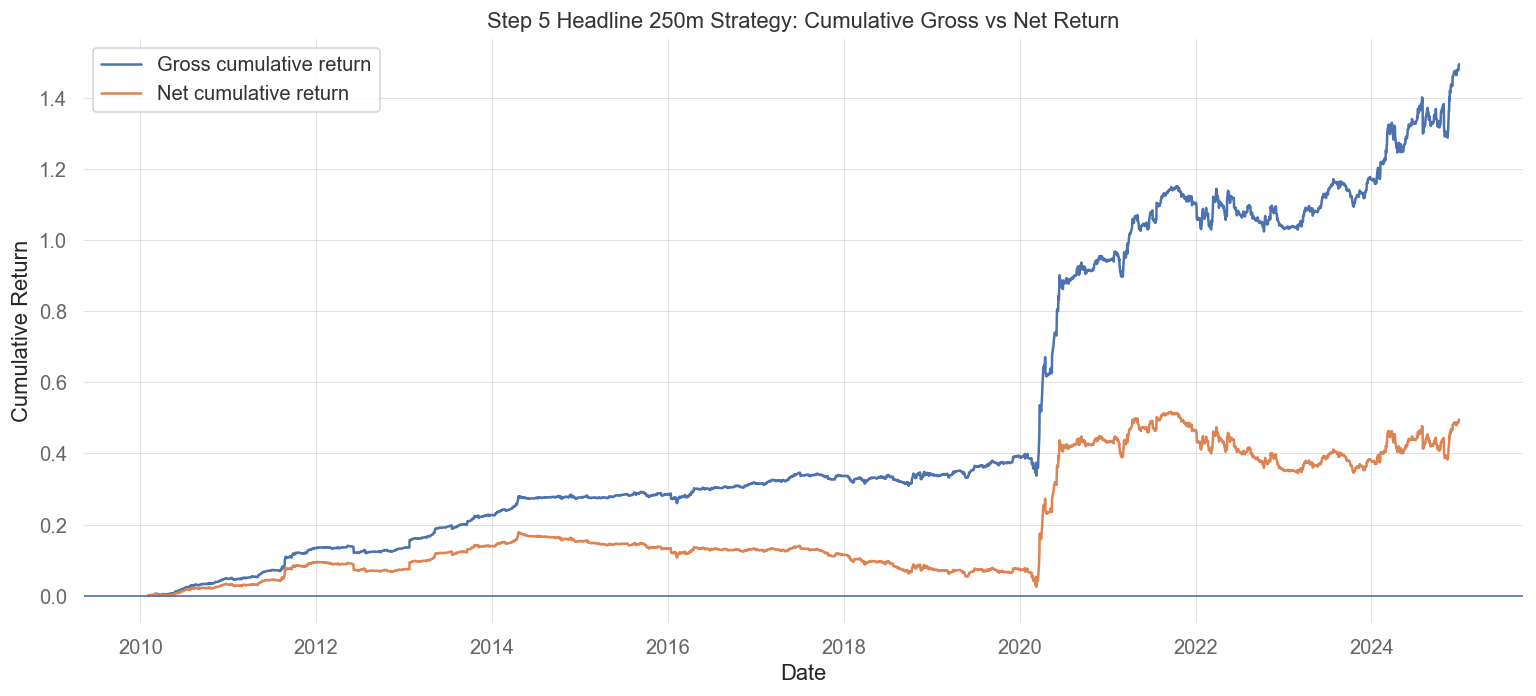

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/step5_headline_cumulative_return.png


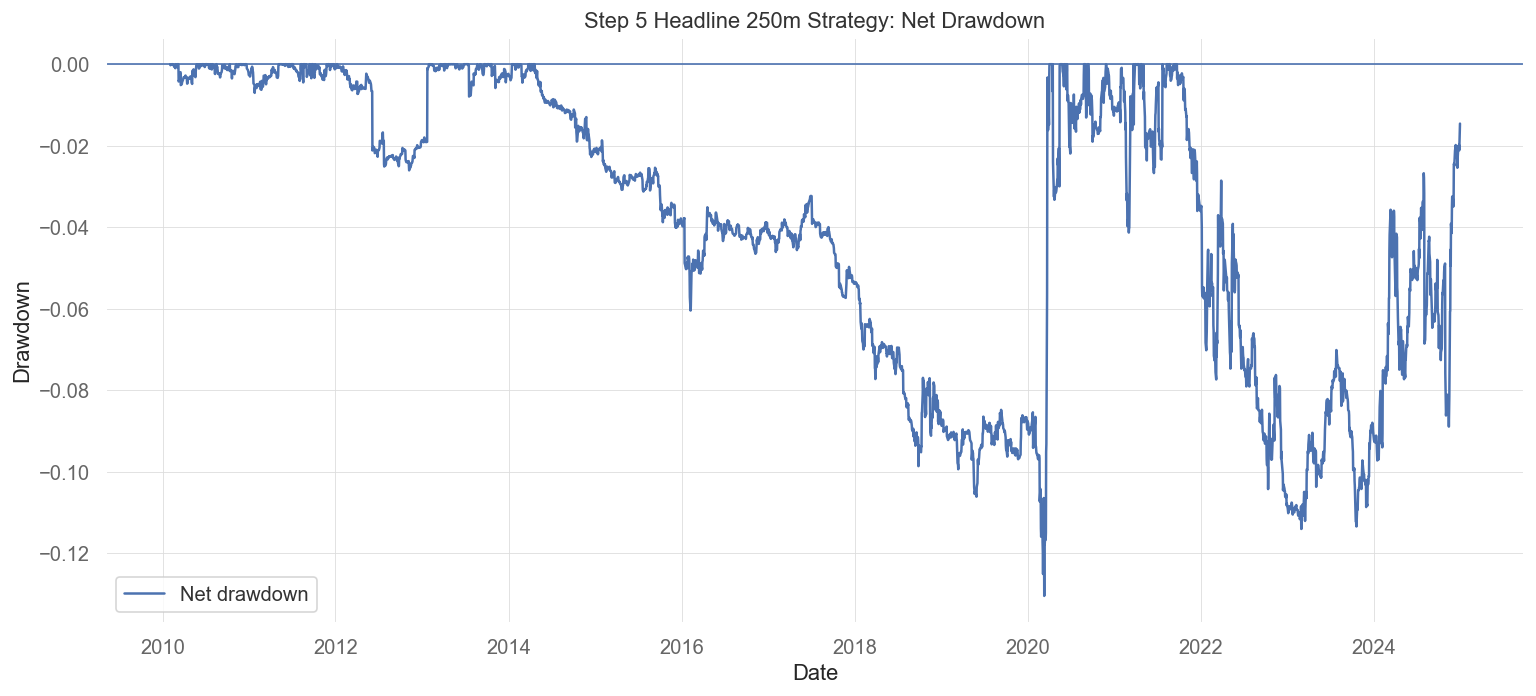

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/step5_headline_net_drawdown.png


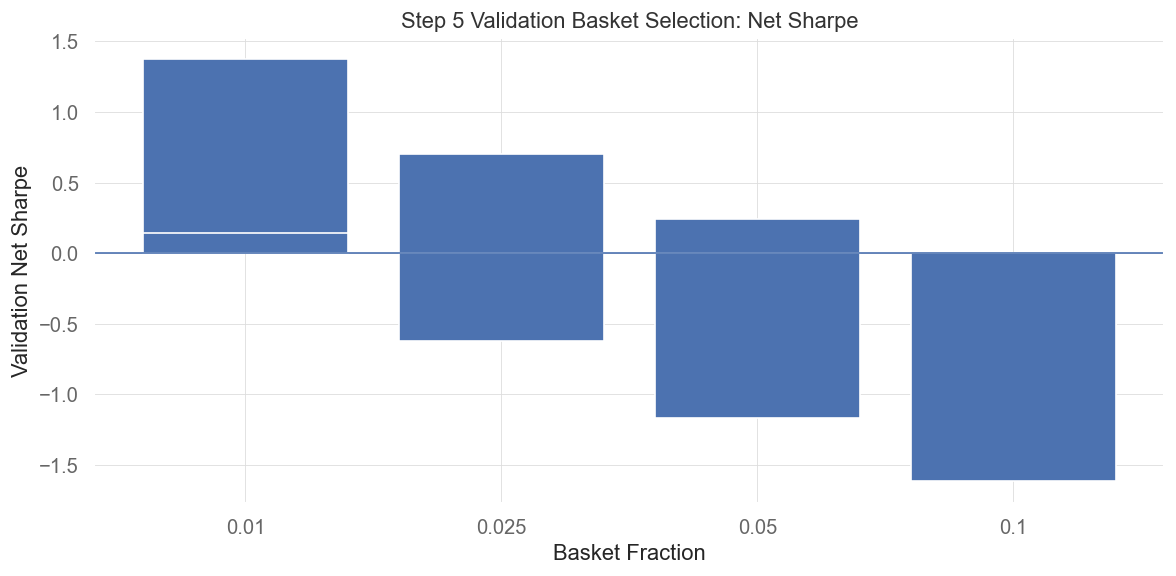

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/step5_validation_basket_net_sharpe.png


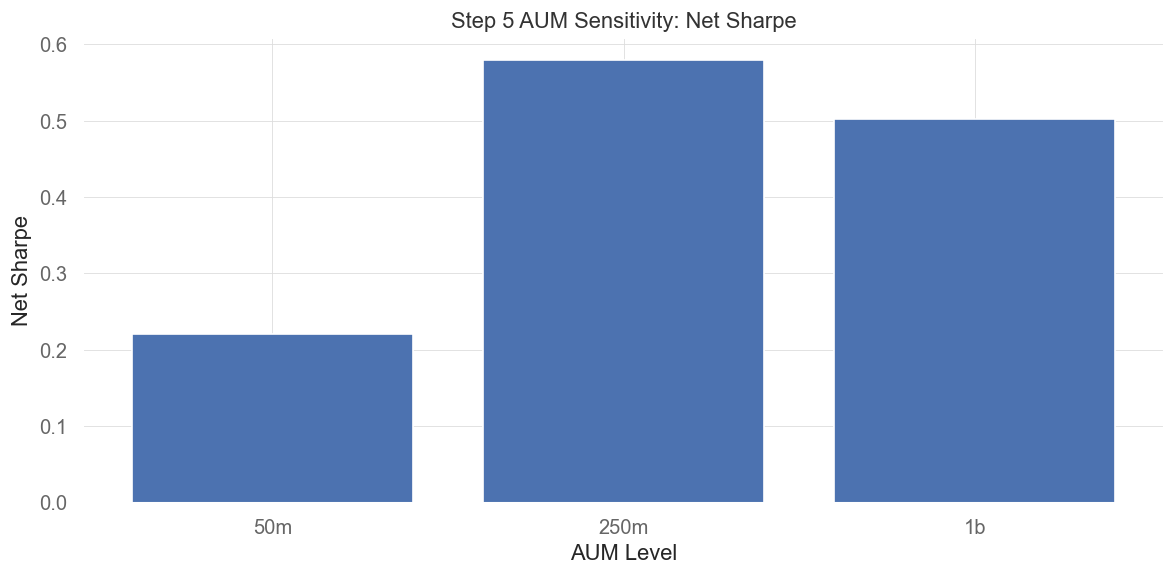

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/step5_aum_sensitivity_net_sharpe.png


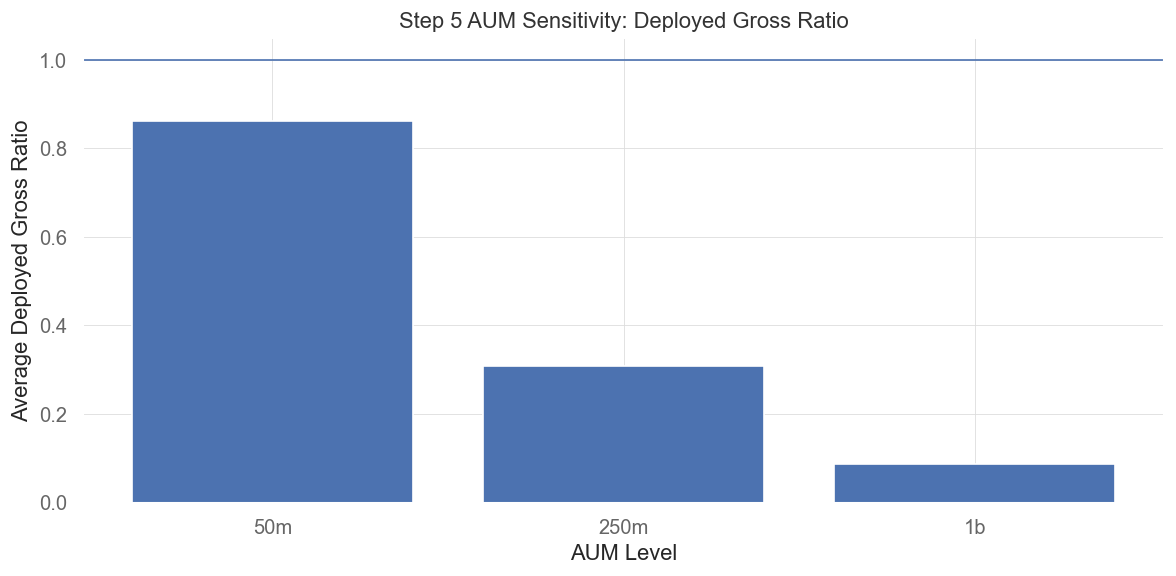

Saved: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/step5_aum_sensitivity_deployed_gross.png

Headline daily diagnostics preview:


,date,gross_return,net_return,deployed_gross_ratio,turnover,cost_drag,borrow_cost,commission_cost,slippage_cost
0,2010-02-02,0.000323,0.000271,0.122023,0.244045,0.000052,766.258234,3050.565058,9151.695173
1,2010-02-03,-0.000191,-0.000219,0.063313,0.126626,0.000028,759.654811,1582.827765,4748.483295
2,2010-02-04,0.000114,0.000056,0.139275,0.278550,0.000059,723.734298,3481.877284,10445.631851
3,2010-02-05,0.000025,-0.000029,0.124041,0.248082,0.000053,951.988361,3101.022381,9303.067144
4,2010-02-08,0.000174,0.000122,0.123337,0.246673,0.000052,663.945563,3083.413255,9250.239766


In [57]:
# ============================================================
# Step 5 Visualisation: Portfolio Performance and Capacity
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


STEP5_FIG_DIR = FIG_DIR / "step5"
STEP5_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("STEP 5 VISUALISATION: HEADLINE STRATEGY PERFORMANCE")
print("=" * 80)

# ------------------------------------------------------------
# Identify headline daily dataframe
# ------------------------------------------------------------
if "headline_daily" in globals():
    daily_plot = headline_daily.copy()
elif "daily_250m" in globals():
    daily_plot = daily_250m.copy()
elif "daily" in globals():
    if "aum_level" in daily.columns:
        daily_plot = daily.loc[daily["aum_level"].astype(str).str.lower().eq("250m")].copy()
    else:
        daily_plot = daily.copy()
else:
    daily_plot = None

if daily_plot is None or daily_plot.empty:
    print("No headline daily performance dataframe found.")
else:
    date_col = COL["date"] if "COL" in globals() and "date" in COL and COL["date"] in daily_plot.columns else "date"
    daily_plot[date_col] = pd.to_datetime(daily_plot[date_col])
    daily_plot = daily_plot.sort_values(date_col).copy()

    # Find return columns
    gross_ret_col = "gross_return" if "gross_return" in daily_plot.columns else None
    net_ret_col = "net_return" if "net_return" in daily_plot.columns else None

    if gross_ret_col is not None:
        daily_plot["cum_gross_return"] = (1.0 + daily_plot[gross_ret_col].fillna(0)).cumprod() - 1.0
    if net_ret_col is not None:
        daily_plot["cum_net_return"] = (1.0 + daily_plot[net_ret_col].fillna(0)).cumprod() - 1.0

    # --------------------------------------------------------
    # 1. Cumulative gross vs net return
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(13, 6))

    if "cum_gross_return" in daily_plot.columns:
        ax.plot(daily_plot[date_col], daily_plot["cum_gross_return"], label="Gross cumulative return")

    if "cum_net_return" in daily_plot.columns:
        ax.plot(daily_plot[date_col], daily_plot["cum_net_return"], label="Net cumulative return")

    ax.axhline(0, linewidth=1)
    ax.set_title("Step 5 Headline 250m Strategy: Cumulative Gross vs Net Return")
    ax.set_ylabel("Cumulative Return")
    ax.set_xlabel("Date")
    ax.legend()
    plt.tight_layout()

    fig_path = STEP5_FIG_DIR / "step5_headline_cumulative_return.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show(block=False)
    plt.close()

    print(f"Saved: {fig_path}")

    # --------------------------------------------------------
    # 2. Net drawdown curve
    # --------------------------------------------------------
    if net_ret_col is not None:
        wealth = (1.0 + daily_plot[net_ret_col].fillna(0)).cumprod()
        running_max = wealth.cummax()
        daily_plot["net_drawdown"] = wealth / running_max - 1.0

        fig, ax = plt.subplots(figsize=(13, 6))
        ax.plot(daily_plot[date_col], daily_plot["net_drawdown"], label="Net drawdown")
        ax.axhline(0, linewidth=1)
        ax.set_title("Step 5 Headline 250m Strategy: Net Drawdown")
        ax.set_ylabel("Drawdown")
        ax.set_xlabel("Date")
        ax.legend()
        plt.tight_layout()

        fig_path = STEP5_FIG_DIR / "step5_headline_net_drawdown.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show(block=False)
        plt.close()

        print(f"Saved: {fig_path}")

    # --------------------------------------------------------
    # 3. Basket selection chart
    # --------------------------------------------------------
    if "selection_grid" in globals():
        basket_plot = selection_grid.copy()

        basket_col_candidates = [
            c for c in basket_plot.columns 
            if "basket" in c.lower() or "fraction" in c.lower()
        ]
        sharpe_col_candidates = [
            c for c in basket_plot.columns 
            if "sharpe" in c.lower() and "net" in c.lower()
        ]

        basket_col = basket_col_candidates[0] if basket_col_candidates else None
        sharpe_col = sharpe_col_candidates[0] if sharpe_col_candidates else None

        if basket_col is not None and sharpe_col is not None:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.bar(basket_plot[basket_col].astype(str), basket_plot[sharpe_col])
            ax.axhline(0, linewidth=1)
            ax.set_title("Step 5 Validation Basket Selection: Net Sharpe")
            ax.set_ylabel("Validation Net Sharpe")
            ax.set_xlabel("Basket Fraction")
            plt.tight_layout()

            fig_path = STEP5_FIG_DIR / "step5_validation_basket_net_sharpe.png"
            plt.savefig(fig_path, dpi=150, bbox_inches="tight")
            plt.show(block=False)
            plt.close()

            print(f"Saved: {fig_path}")
        else:
            print("Could not identify basket fraction / net Sharpe columns in selection_grid.")

    # --------------------------------------------------------
    # 4. AUM sensitivity chart
    # --------------------------------------------------------
    if "aum_sensitivity" in globals():
        aum_plot = aum_sensitivity.copy()

        aum_col_candidates = [
            c for c in aum_plot.columns 
            if "aum" in c.lower()
        ]
        sharpe_col_candidates = [
            c for c in aum_plot.columns 
            if "sharpe" in c.lower() and "net" in c.lower()
        ]
        deploy_col_candidates = [
            c for c in aum_plot.columns 
            if "deployed" in c.lower() and "gross" in c.lower()
        ]

        aum_col = aum_col_candidates[0] if aum_col_candidates else None
        sharpe_col = sharpe_col_candidates[0] if sharpe_col_candidates else None
        deploy_col = deploy_col_candidates[0] if deploy_col_candidates else None

        if aum_col is not None and sharpe_col is not None:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.bar(aum_plot[aum_col].astype(str), aum_plot[sharpe_col])
            ax.axhline(0, linewidth=1)
            ax.set_title("Step 5 AUM Sensitivity: Net Sharpe")
            ax.set_ylabel("Net Sharpe")
            ax.set_xlabel("AUM Level")
            plt.tight_layout()

            fig_path = STEP5_FIG_DIR / "step5_aum_sensitivity_net_sharpe.png"
            plt.savefig(fig_path, dpi=150, bbox_inches="tight")
            plt.show(block=False)
            plt.close()

            print(f"Saved: {fig_path}")

        if aum_col is not None and deploy_col is not None:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.bar(aum_plot[aum_col].astype(str), aum_plot[deploy_col])
            ax.axhline(1.0, linewidth=1)
            ax.set_title("Step 5 AUM Sensitivity: Deployed Gross Ratio")
            ax.set_ylabel("Average Deployed Gross Ratio")
            ax.set_xlabel("AUM Level")
            plt.tight_layout()

            fig_path = STEP5_FIG_DIR / "step5_aum_sensitivity_deployed_gross.png"
            plt.savefig(fig_path, dpi=150, bbox_inches="tight")
            plt.show(block=False)
            plt.close()

            print(f"Saved: {fig_path}")

    # --------------------------------------------------------
    # 5. Display compact headline diagnostic table
    # --------------------------------------------------------
    diagnostic_cols = [
        c for c in [
            date_col,
            gross_ret_col,
            net_ret_col,
            "deployed_gross_ratio",
            "turnover",
            "cost_drag",
            "borrow_cost",
            "commission_cost",
            "slippage_cost",
        ]
        if c is not None and c in daily_plot.columns
    ]

    if len(diagnostic_cols) > 0:
        print("\nHeadline daily diagnostics preview:")
        display(daily_plot[diagnostic_cols].head().round(6))

# Step 5 Additional Brief Diagnostics

Gross-to-net attribution, AUM sensitivity, stress windows, statistical robustness, borrow honesty, and impact-cost reconciliation. All diagnostics are reporting-only and do not change the headline strategy.


Step 5 additional diagnostics: reporting-only; headline strategy unchanged.


,period,gross_sharpe,after_commission_sharpe,after_slippage_sharpe,net_sharpe,commission_sharpe_drag,slippage_sharpe_drag,borrow_sharpe_drag,total_sharpe_drag
0,train,1.5804,1.3110,0.5004,0.3950,0.2695,0.8105,0.1054,1.1854
1,validation,1.9876,1.8521,1.4444,1.3778,0.1355,0.4077,0.0667,0.6098
2,development_test,0.8816,0.7136,0.2081,0.1412,0.1680,0.5054,0.0669,0.7403
3,full_2010_2024,1.2826,1.1240,0.6464,0.5796,0.1586,0.4775,0.0668,0.7029


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_gross_to_net_sharpe_decomposition.png


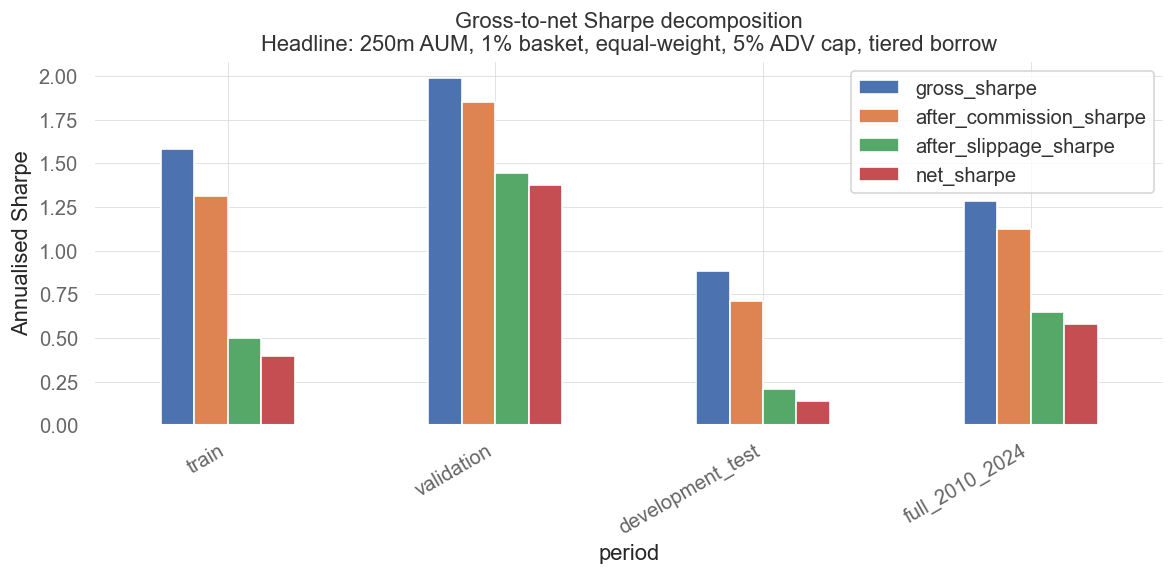

,aum_level,net_ann_return,net_ann_vol,net_sharpe,max_drawdown,avg_daily_turnover,avg_deployed_gross_ratio,fraction_days_full_gross_deployed,fraction_days_any_stock_adv_cap_binding,borrow_sharpe_drag,total_cost_sharpe_drag
0,50m,0.0158,0.0888,0.2204,-0.3662,1.7213,0.8606,0.6099,0.9947,0.1196,1.0963
1,250m,0.0274,0.0487,0.5796,-0.1305,0.6178,0.3089,0.0213,1.0000,0.0668,0.7029
2,1b,0.0077,0.0156,0.5016,-0.0383,0.1730,0.0865,0.0000,1.0000,0.0559,0.6124


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_aum_net_sharpe.png


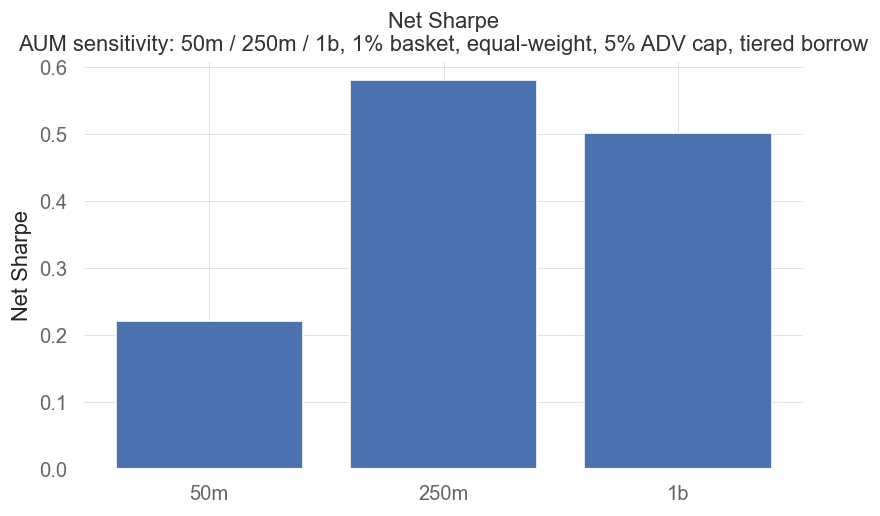

Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_aum_deployed_gross.png


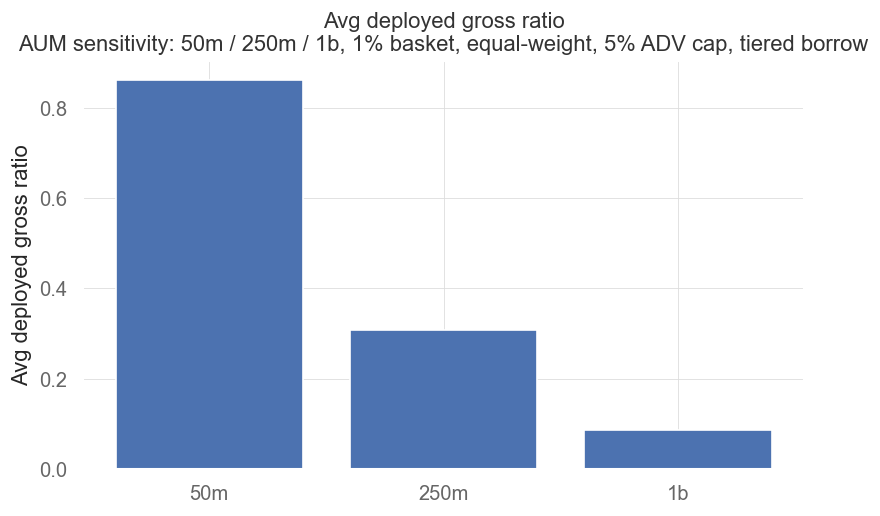

Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_aum_borrow_sharpe_drag.png


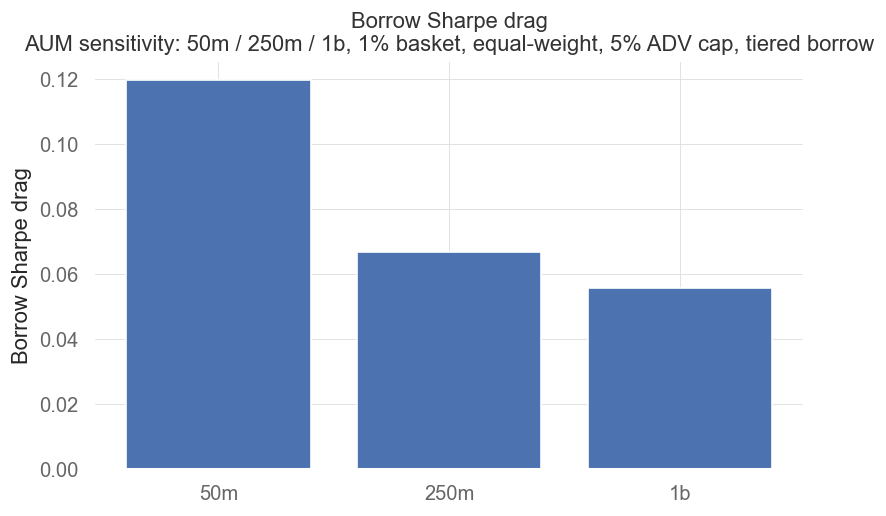

,window,start_date,end_date,n_days,gross_return,net_return,net_annualised_vol,net_sharpe,max_drawdown,avg_deployed_gross_ratio,avg_turnover,total_cost_drag,borrow_cost_drag
0,late_2018_drawdown,2018-10-01,2018-12-31,63,0.0173,0.0057,0.0479,0.4997,-0.0154,0.4050,0.8101,0.0115,0.0013
1,covid_2020_q1,2020-02-01,2020-03-31,41,0.0888,0.0810,0.1990,2.5028,-0.0481,0.4037,0.8075,0.0072,0.0006
2,rate_inflation_2022,2022-01-01,2022-12-31,251,-0.0318,-0.0748,0.0718,-1.0509,-0.0820,0.4158,0.8316,0.0454,0.0037


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_stress_net_return.png


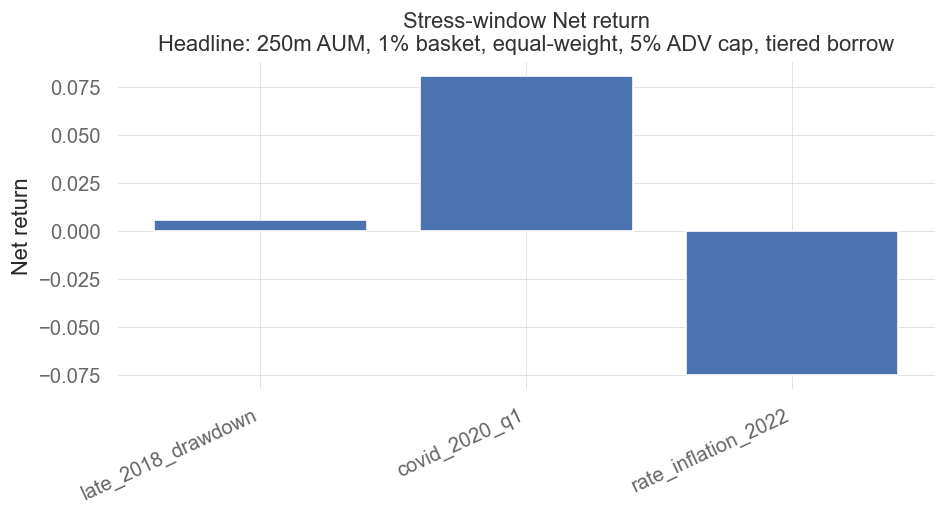

Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_stress_max_drawdown.png


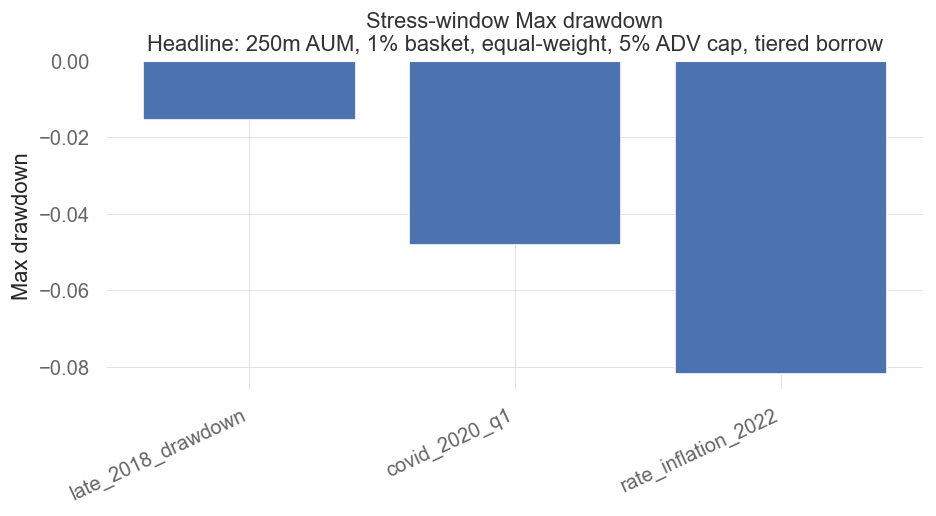

,year,gross_return,net_return,net_vol_ann,net_sharpe,max_drawdown,avg_turnover,avg_deployed_gross_ratio
0,2010,0.0470,0.0306,0.0127,2.5911,-0.0051,0.3136,0.1568
1,2011,0.0825,0.0607,0.0219,2.7050,-0.0064,0.3760,0.1880
2,2012,0.0014,-0.0171,0.0186,-0.9234,-0.0260,0.3420,0.1710
3,2013,0.0813,0.0609,0.0248,2.3976,-0.0079,0.3392,0.1696
4,2014,0.0398,0.0113,0.0185,0.6196,-0.0228,0.4973,0.2486
5,2015,0.0068,-0.0181,0.0135,-1.3462,-0.0218,0.4529,0.2265
6,2016,0.0244,-0.0016,0.0221,-0.0593,-0.0236,0.4637,0.2318
7,2017,0.0154,-0.0138,0.0157,-0.8800,-0.0259,0.5308,0.2654
8,2018,0.0023,-0.0364,0.0319,-1.1488,-0.0477,0.7086,0.3543
9,2019,0.0400,0.0008,0.0227,0.0478,-0.0207,0.6814,0.3407


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_yearly_net_return.png


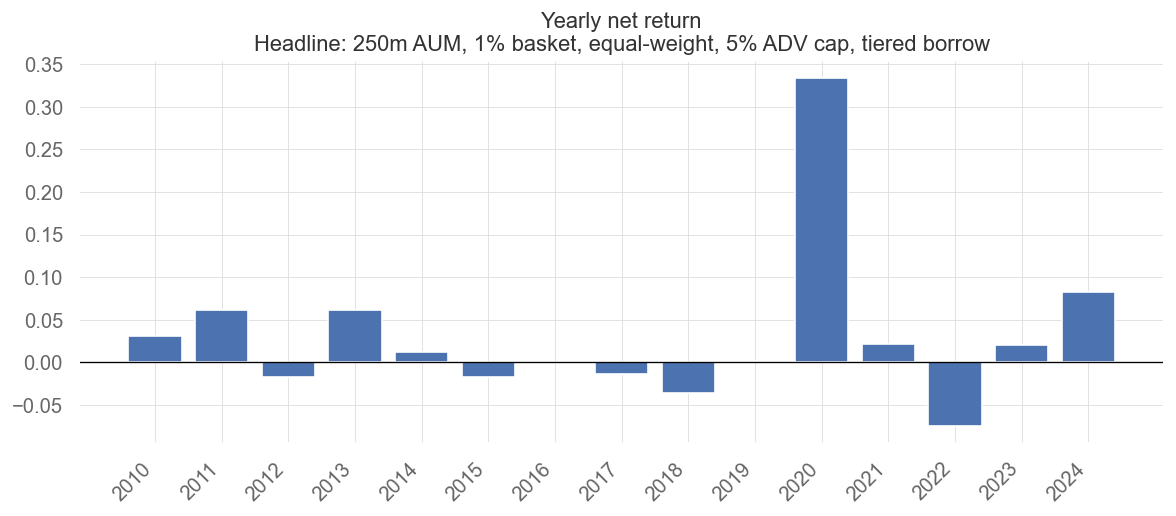

Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_yearly_net_sharpe.png


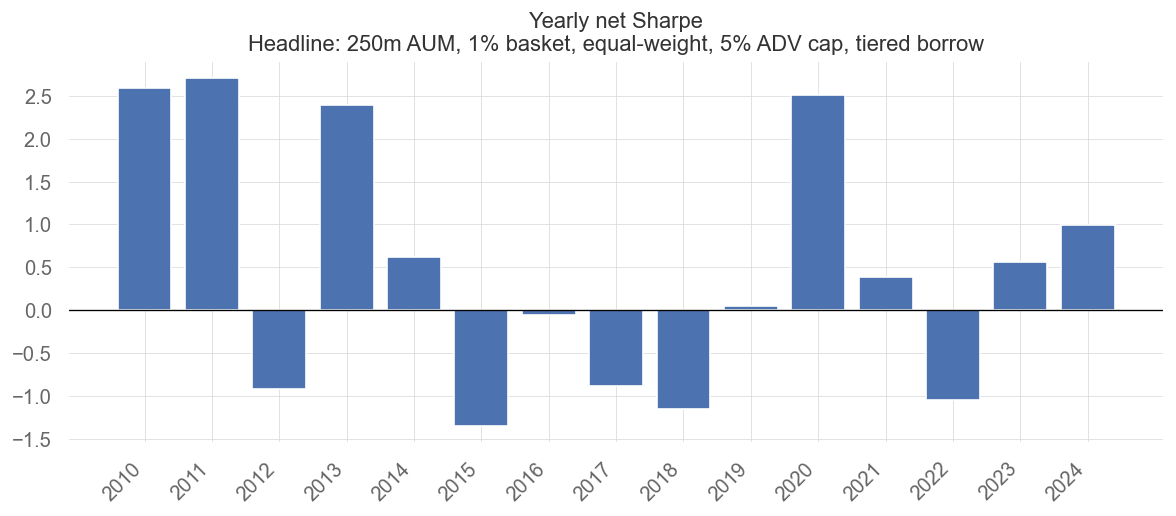

,period,standard_sharpe,lo_adjusted_sharpe_q5,n_days,autocorr_lag_1,autocorr_lag_2,autocorr_lag_3,autocorr_lag_4,autocorr_lag_5
0,train,0.3950,0.3853,2244,-0.0187,0.0774,0.0001,-0.0253,-0.0126
1,validation,1.3778,1.1520,757,0.0920,0.0818,0.1296,0.0197,0.0753
2,development_test,0.1412,0.1372,752,0.0078,0.0460,-0.0282,0.0283,-0.0155
3,full_2010_2024,0.5796,0.5168,3753,0.0499,0.0699,0.0569,0.0203,0.0334


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_rolling_net_returns.png


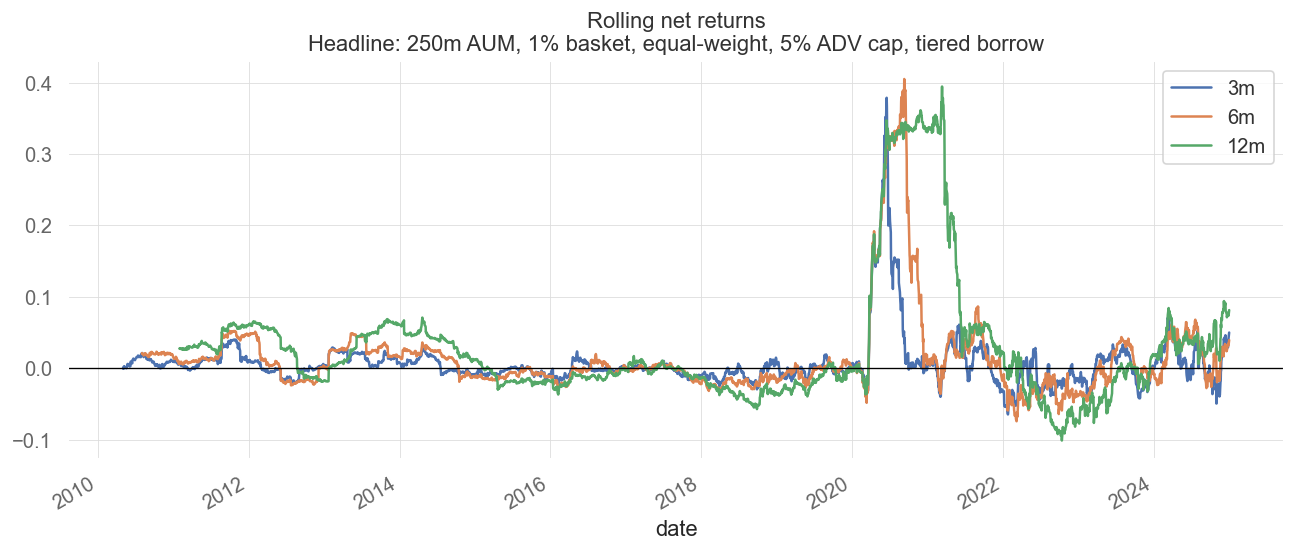

,window_length,start_date,end_date,net_return,max_drawdown_within_window,avg_turnover,avg_deployed_gross_ratio
0,3m,2021-10-25,2022-01-24,-0.064677,-0.064363,0.815210,0.407605
1,6m,2021-09-07,2022-03-07,-0.074223,-0.077358,0.957778,0.478889
2,12m,2021-10-13,2022-10-12,-0.101227,-0.102252,0.847970,0.423985


,n_days,tail_days,top_5pct_positive_days_sum_return,top_5pct_contribution_to_total_net_return_sum,bottom_5pct_negative_days_sum_return,bottom_5pct_contribution_to_total_net_return_sum,excluding_top_5pct_net_ann_return,excluding_top_5pct_net_sharpe,excluding_bottom_5pct_net_ann_return,excluding_bottom_5pct_net_sharpe
0,3753,187,1.5249,3.6308,-1.201,-2.8595,-0.0756,-2.4714,0.1204,2.7993


,definition,short_high_si_notional_share,high_si_gross_pnl_contribution,high_si_net_pnl_contribution,high_si_gross_pnl_pct_total,high_si_net_pnl_pct_total
0,short_interest_pct_float > 10%,0.0967,-9.702322e+06,-1.920706e+07,-0.0416,-0.1829


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_high_si_htb_contribution.png


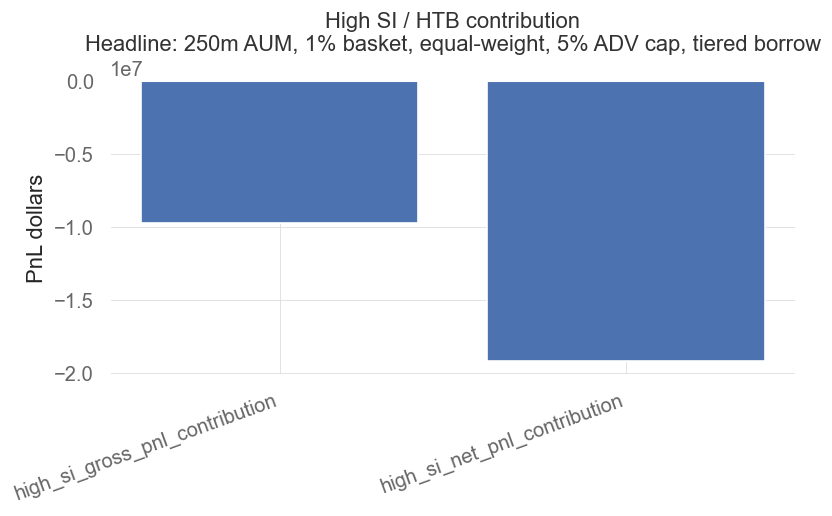

,strategy,net_sharpe,net_return,average_deployed_gross_ratio,turnover,borrow_cost
0,original_tiered_borrow,0.5796,0.0274,0.3089,0.6178,3230.6894
1,hard_exclude_high_si_or_htb,0.4901,0.0217,0.3037,0.6075,2334.6679


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_hard_borrow_exclusion_net_sharpe.png


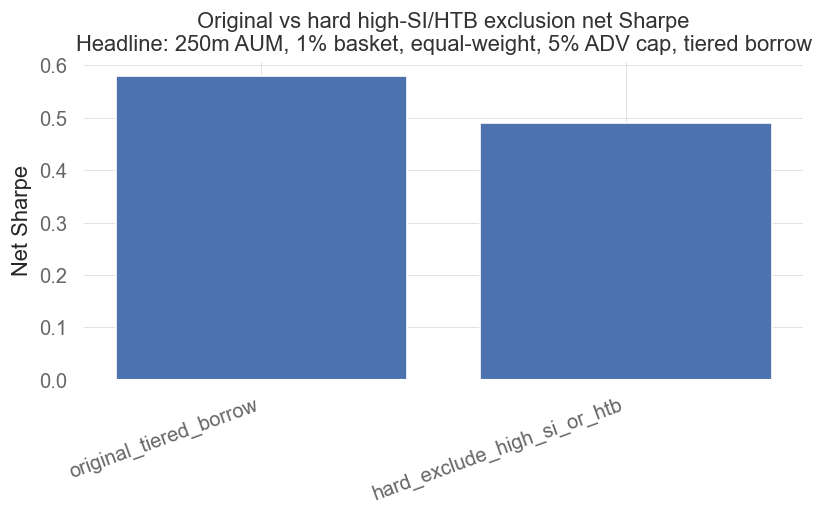

,sigma_daily,participation_fraction,square_root_impact_bps,fixed_auction_slippage_bps_per_leg,fixed_round_trip_slippage_bps,interpretation
0,0.0128,0.05,19.9758,1.5,3.0,Diagnostic only: square-root impact justifies ...
1,0.0223,0.05,34.8336,1.5,3.0,Diagnostic only: square-root impact justifies ...
2,0.0382,0.05,59.7222,1.5,3.0,Diagnostic only: square-root impact justifies ...
3,0.0544,0.05,85.1702,1.5,3.0,Diagnostic only: square-root impact justifies ...


Saved and displayed figure: /Users/cuiyufan/Desktop/ml data/c2o_outputs/figures/step5/fig_step5_impact_cost_reconciliation.png


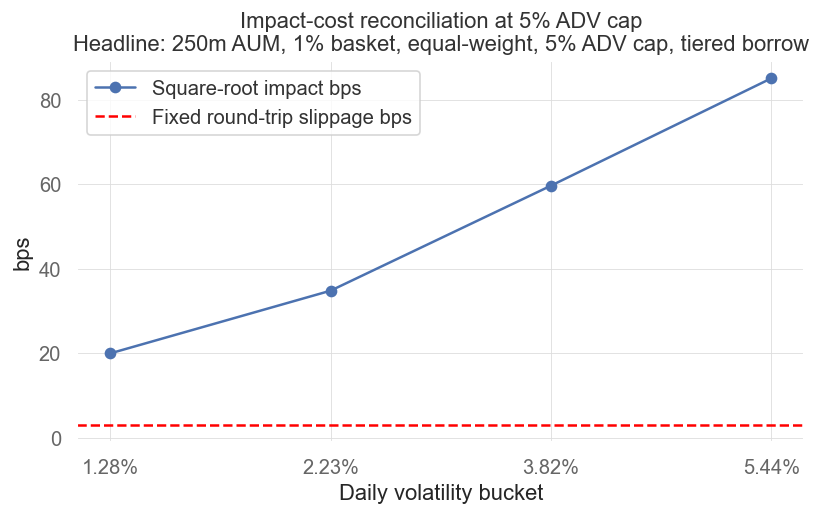

In [58]:
# ============================================================
# Step 5 additional brief diagnostics and robustness (reporting only)
# ============================================================
print("Step 5 additional diagnostics: reporting-only; headline strategy unchanged.")
step5_fig_dir = FIG_DIR / "step5"
step5_fig_dir.mkdir(parents=True, exist_ok=True)
HEADLINE_DESC = "Headline: 250m AUM, 1% basket, equal-weight, 5% ADV cap, tiered borrow"
AUM_DESC = "AUM sensitivity: 50m / 250m / 1b, 1% basket, equal-weight, 5% ADV cap, tiered borrow"

headline_daily["after_commission_return"] = (headline_daily["gross_pnl"] - headline_daily["commission_cost"]) / headline_daily["aum"]
headline_daily["after_slippage_return"] = (headline_daily["gross_pnl"] - headline_daily["commission_cost"] - headline_daily["slippage_cost"]) / headline_daily["aum"]

def _period_iter_with_full(daily):
    for pname in ["train", "validation", "development_test"]:
        yield pname, daily[daily["period"].eq(pname)].copy()
    yield "full_2010_2024", daily.copy()

sharpe_rows = []
for pname, d in _period_iter_with_full(headline_daily):
    if d.empty:
        continue
    gross_sh = sharpe(d["gross_return"])
    after_comm_sh = sharpe(d["after_commission_return"])
    after_slip_sh = sharpe(d["after_slippage_return"])
    net_sh = sharpe(d["net_return"])
    sharpe_rows.append({
        "period": pname,
        "gross_sharpe": gross_sh,
        "after_commission_sharpe": after_comm_sh,
        "after_slippage_sharpe": after_slip_sh,
        "net_sharpe": net_sh,
        "commission_sharpe_drag": gross_sh - after_comm_sh,
        "slippage_sharpe_drag": after_comm_sh - after_slip_sh,
        "borrow_sharpe_drag": after_slip_sh - net_sh,
        "total_sharpe_drag": gross_sh - net_sh,
    })
step5_gross_to_net_sharpe_decomposition = pd.DataFrame(sharpe_rows)
display(step5_gross_to_net_sharpe_decomposition.round(4))
step5_gross_to_net_sharpe_decomposition.to_csv(out_path("step5_gross_to_net_sharpe_decomposition.csv"), index=False)
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = step5_gross_to_net_sharpe_decomposition.set_index("period")[["gross_sharpe", "after_commission_sharpe", "after_slippage_sharpe", "net_sharpe"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title(f"Gross-to-net Sharpe decomposition\n{HEADLINE_DESC}")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Annualised Sharpe")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
save_and_show(fig, step5_fig_dir / "fig_step5_gross_to_net_sharpe_decomposition.png")

def _daily_full_metrics(d, aum_label):
    d = d.copy()
    d["after_slippage_return"] = (d["gross_pnl"] - d["commission_cost"] - d["slippage_cost"]) / d["aum"]
    return {
        "aum_level": aum_label,
        "net_ann_return": ann_return(d["net_return"]),
        "net_ann_vol": d["net_return"].std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR),
        "net_sharpe": sharpe(d["net_return"]),
        "max_drawdown": max_drawdown(d["net_return"]),
        "avg_daily_turnover": d["turnover"].mean(),
        "avg_deployed_gross_ratio": d["deployed_gross_ratio"].mean(),
        "fraction_days_full_gross_deployed": d["deployed_gross_ratio"].ge(0.999).mean(),
        "fraction_days_any_stock_adv_cap_binding": d["any_stock_adv_cap_binding"].mean(),
        "borrow_sharpe_drag": sharpe(d["after_slippage_return"]) - sharpe(d["net_return"]),
        "total_cost_sharpe_drag": sharpe(d["gross_return"]) - sharpe(d["net_return"]),
    }
step5_aum_sensitivity_brief_required_metrics = pd.DataFrame([_daily_full_metrics(final_daily_by_aum[a], a) for a in ["50m", "250m", "1b"]])
display(step5_aum_sensitivity_brief_required_metrics.round(4))
step5_aum_sensitivity_brief_required_metrics.to_csv(out_path("step5_aum_sensitivity_brief_required_metrics.csv"), index=False)
for metric, fname, ylabel in [("net_sharpe", "fig_step5_aum_net_sharpe.png", "Net Sharpe"), ("avg_deployed_gross_ratio", "fig_step5_aum_deployed_gross.png", "Avg deployed gross ratio"), ("borrow_sharpe_drag", "fig_step5_aum_borrow_sharpe_drag.png", "Borrow Sharpe drag")]:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(step5_aum_sensitivity_brief_required_metrics["aum_level"], step5_aum_sensitivity_brief_required_metrics[metric])
    ax.set_title(f"{ylabel}\n{AUM_DESC}")
    ax.set_ylabel(ylabel)
    save_and_show(fig, step5_fig_dir / fname)

stress_windows = {
    "late_2018_drawdown": ("2018-10-01", "2018-12-31"),
    "covid_2020_q1": ("2020-02-01", "2020-03-31"),
    "rate_inflation_2022": ("2022-01-01", "2022-12-31"),
}
stress_rows = []
for name, (start, end) in stress_windows.items():
    d = headline_daily[headline_daily["date"].between(pd.Timestamp(start), pd.Timestamp(end))].copy()
    stress_rows.append({
        "window": name, "start_date": start, "end_date": end, "n_days": len(d),
        "gross_return": (1+d["gross_return"].fillna(0)).prod()-1 if len(d) else np.nan,
        "net_return": (1+d["net_return"].fillna(0)).prod()-1 if len(d) else np.nan,
        "net_annualised_vol": d["net_return"].std(ddof=1)*np.sqrt(TRADING_DAYS_PER_YEAR) if len(d)>1 else np.nan,
        "net_sharpe": sharpe(d["net_return"]),
        "max_drawdown": max_drawdown(d["net_return"]),
        "avg_deployed_gross_ratio": d["deployed_gross_ratio"].mean(),
        "avg_turnover": d["turnover"].mean(),
        "total_cost_drag": d["cost_drag"].sum(),
        "borrow_cost_drag": (d["borrow_cost"]/d["aum"]).sum() if len(d) else np.nan,
    })
step5_stress_window_summary = pd.DataFrame(stress_rows)
display(step5_stress_window_summary.round(4))
step5_stress_window_summary.to_csv(out_path("step5_stress_window_summary.csv"), index=False)
for metric, fname, ylabel in [("net_return", "fig_step5_stress_net_return.png", "Net return"), ("max_drawdown", "fig_step5_stress_max_drawdown.png", "Max drawdown")]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(step5_stress_window_summary["window"], step5_stress_window_summary[metric])
    ax.set_title(f"Stress-window {ylabel}\n{HEADLINE_DESC}")
    ax.set_ylabel(ylabel)
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
    save_and_show(fig, step5_fig_dir / fname)

headline_daily["year"] = headline_daily["date"].dt.year
yearly_rows = []
for y, d in headline_daily.groupby("year"):
    yearly_rows.append({"year": y, "gross_return": (1+d["gross_return"].fillna(0)).prod()-1, "net_return": (1+d["net_return"].fillna(0)).prod()-1, "net_vol_ann": d["net_return"].std(ddof=1)*np.sqrt(TRADING_DAYS_PER_YEAR), "net_sharpe": sharpe(d["net_return"]), "max_drawdown": max_drawdown(d["net_return"]), "avg_turnover": d["turnover"].mean(), "avg_deployed_gross_ratio": d["deployed_gross_ratio"].mean()})
step5_year_by_year_performance = pd.DataFrame(yearly_rows)
display(step5_year_by_year_performance.round(4))
step5_year_by_year_performance.to_csv(out_path("step5_year_by_year_performance.csv"), index=False)
for metric, fname, ylabel in [("net_return", "fig_step5_yearly_net_return.png", "Yearly net return"), ("net_sharpe", "fig_step5_yearly_net_sharpe.png", "Yearly net Sharpe")]:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(step5_year_by_year_performance["year"].astype(str), step5_year_by_year_performance[metric])
    ax.set_title(f"{ylabel}\n{HEADLINE_DESC}")
    ax.axhline(0, color="black", linewidth=0.8)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    save_and_show(fig, step5_fig_dir / fname)

def lo_adjusted_sharpe_series(r, q=5):
    r = pd.Series(r).dropna()
    if len(r) < q + 2:
        return np.nan, {}
    sr = sharpe(r)
    rhos = {f"autocorr_lag_{k}": r.autocorr(k) for k in range(1, q+1)}
    denom = 1 + 2 * sum((1 - k/(q+1)) * (rhos[f"autocorr_lag_{k}"] if pd.notna(rhos[f"autocorr_lag_{k}"]) else 0) for k in range(1, q+1))
    return sr / np.sqrt(max(denom, 1e-8)), rhos
lo_rows = []
for pname, d in _period_iter_with_full(headline_daily):
    adj, rhos = lo_adjusted_sharpe_series(d["net_return"], q=5)
    row = {"period": pname, "standard_sharpe": sharpe(d["net_return"]), "lo_adjusted_sharpe_q5": adj, "n_days": len(d)}
    row.update(rhos)
    lo_rows.append(row)
step5_lo_autocorr_adjusted_sharpe = pd.DataFrame(lo_rows)
display(step5_lo_autocorr_adjusted_sharpe.round(4))
step5_lo_autocorr_adjusted_sharpe.to_csv(out_path("step5_lo_autocorr_adjusted_sharpe.csv"), index=False)

rolling_series = headline_daily.set_index("date")["net_return"].sort_index()
worst_rows = []
fig, ax = plt.subplots(figsize=(11, 4.8))
for label, window in [("3m", 63), ("6m", 126), ("12m", 252)]:
    rr = (1 + rolling_series).rolling(window).apply(np.prod, raw=True) - 1
    rr.plot(ax=ax, label=label)
    end_date = rr.idxmin()
    start_date = rolling_series.loc[:end_date].tail(window).index.min() if pd.notna(end_date) else pd.NaT
    d = headline_daily[headline_daily["date"].between(start_date, end_date)].copy() if pd.notna(end_date) else pd.DataFrame()
    worst_rows.append({"window_length": label, "start_date": start_date, "end_date": end_date, "net_return": rr.min(), "max_drawdown_within_window": max_drawdown(d["net_return"]) if len(d) else np.nan, "avg_turnover": d["turnover"].mean() if len(d) else np.nan, "avg_deployed_gross_ratio": d["deployed_gross_ratio"].mean() if len(d) else np.nan})
ax.set_title(f"Rolling net returns\n{HEADLINE_DESC}")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
save_and_show(fig, step5_fig_dir / "fig_step5_rolling_net_returns.png")
step5_worst_rolling_windows = pd.DataFrame(worst_rows)
display(step5_worst_rolling_windows)
step5_worst_rolling_windows.to_csv(out_path("step5_worst_rolling_windows.csv"), index=False)

n_tail = max(1, int(len(headline_daily) * 0.05))
ret = headline_daily["net_return"].copy()
top_idx = ret.nlargest(n_tail).index
bottom_idx = ret.nsmallest(n_tail).index
def _ret_sharpe_excluding(idx):
    r = ret.drop(index=idx)
    return ann_return(r), sharpe(r)
ex_top_ret, ex_top_sh = _ret_sharpe_excluding(top_idx)
ex_bot_ret, ex_bot_sh = _ret_sharpe_excluding(bottom_idx)
total_net_sum = ret.sum()
step5_top_bottom_5pct_day_contribution = pd.DataFrame([{
    "n_days": len(ret), "tail_days": n_tail,
    "top_5pct_positive_days_sum_return": ret.loc[top_idx].sum(),
    "top_5pct_contribution_to_total_net_return_sum": ret.loc[top_idx].sum() / total_net_sum if total_net_sum != 0 else np.nan,
    "bottom_5pct_negative_days_sum_return": ret.loc[bottom_idx].sum(),
    "bottom_5pct_contribution_to_total_net_return_sum": ret.loc[bottom_idx].sum() / total_net_sum if total_net_sum != 0 else np.nan,
    "excluding_top_5pct_net_ann_return": ex_top_ret,
    "excluding_top_5pct_net_sharpe": ex_top_sh,
    "excluding_bottom_5pct_net_ann_return": ex_bot_ret,
    "excluding_bottom_5pct_net_sharpe": ex_bot_sh,
}])
display(step5_top_bottom_5pct_day_contribution.round(4))
step5_top_bottom_5pct_day_contribution.to_csv(out_path("step5_top_bottom_5pct_day_contribution.csv"), index=False)

positions = final_positions_250m.copy()
short_pos = positions[positions["side"].eq("short") | positions["position_notional"].lt(0)].copy()
if "short_interest_pct_float" in short_pos.columns and short_pos["short_interest_pct_float"].notna().any():
    short_pos["high_si_or_htb"] = short_pos["short_interest_pct_float"].gt(0.10)
    high_si_definition = "short_interest_pct_float > 10%"
elif "dsi" in short_pos.columns and short_pos["dsi"].notna().any():
    short_pos["high_si_or_htb"] = short_pos["dsi"].gt(0.10)
    high_si_definition = "dsi > 10% fallback"
else:
    print("WARNING: no short_interest_pct_float/dsi available; using Tier C as high SI/HTB proxy.")
    short_pos["high_si_or_htb"] = short_pos.get("borrow_tier", pd.Series("A", index=short_pos.index)).eq("C")
    high_si_definition = "borrow_tier C fallback"
high = short_pos[short_pos["high_si_or_htb"]].copy()
step5_borrow_honesty_contribution = pd.DataFrame([{
    "definition": high_si_definition,
    "short_high_si_notional_share": high["abs_position_notional"].sum() / short_pos["abs_position_notional"].sum() if len(short_pos) and short_pos["abs_position_notional"].sum() else np.nan,
    "high_si_gross_pnl_contribution": high["gross_pnl"].sum(),
    "high_si_net_pnl_contribution": high["net_pnl"].sum(),
    "high_si_gross_pnl_pct_total": high["gross_pnl"].sum() / positions["gross_pnl"].sum() if positions["gross_pnl"].sum() != 0 else np.nan,
    "high_si_net_pnl_pct_total": high["net_pnl"].sum() / positions["net_pnl"].sum() if positions["net_pnl"].sum() != 0 else np.nan,
}])
display(step5_borrow_honesty_contribution.round(4))
step5_borrow_honesty_contribution.to_csv(out_path("step5_borrow_honesty_contribution.csv"), index=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
vals = step5_borrow_honesty_contribution[["high_si_gross_pnl_contribution", "high_si_net_pnl_contribution"]].iloc[0]
ax.bar(vals.index, vals.values)
ax.set_title(f"High SI / HTB contribution\n{HEADLINE_DESC}")
ax.set_ylabel("PnL dollars")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
save_and_show(fig, step5_fig_dir / "fig_step5_high_si_htb_contribution.png")

score_250_hard_excl = score_250.copy()
if "short_interest_pct_float" in score_250_hard_excl.columns and score_250_hard_excl["short_interest_pct_float"].notna().any():
    hard_mask = score_250_hard_excl["short_interest_pct_float"].gt(0.10)
elif "dsi" in score_250_hard_excl.columns and score_250_hard_excl["dsi"].notna().any():
    hard_mask = score_250_hard_excl["dsi"].gt(0.10)
else:
    hard_mask = score_250_hard_excl.get("borrow_tier", pd.Series("A", index=score_250_hard_excl.index)).eq("C")
_, hard_daily, _ = build_portfolio_final(score_250_hard_excl.loc[~hard_mask].copy(), HEADLINE_AUM_LABEL, selected_basket, store_positions=False)
step5_hard_borrow_exclusion_robustness = pd.DataFrame([
    {"strategy": "original_tiered_borrow", "net_sharpe": sharpe(headline_daily["net_return"]), "net_return": ann_return(headline_daily["net_return"]), "average_deployed_gross_ratio": headline_daily["deployed_gross_ratio"].mean(), "turnover": headline_daily["turnover"].mean(), "borrow_cost": headline_daily["borrow_cost"].mean()},
    {"strategy": "hard_exclude_high_si_or_htb", "net_sharpe": sharpe(hard_daily["net_return"]), "net_return": ann_return(hard_daily["net_return"]), "average_deployed_gross_ratio": hard_daily["deployed_gross_ratio"].mean(), "turnover": hard_daily["turnover"].mean(), "borrow_cost": hard_daily["borrow_cost"].mean()},
])
display(step5_hard_borrow_exclusion_robustness.round(4))
step5_hard_borrow_exclusion_robustness.to_csv(out_path("step5_hard_borrow_exclusion_robustness.csv"), index=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(step5_hard_borrow_exclusion_robustness["strategy"], step5_hard_borrow_exclusion_robustness["net_sharpe"])
ax.set_title(f"Original vs hard high-SI/HTB exclusion net Sharpe\n{HEADLINE_DESC}")
ax.set_ylabel("Net Sharpe")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
save_and_show(fig, step5_fig_dir / "fig_step5_hard_borrow_exclusion_net_sharpe.png")

vol_buckets = pd.Series([0.01, 0.02, 0.03], name="sigma_daily")
if "realized_vol_20d_lag1" in positions.columns and positions["realized_vol_20d_lag1"].notna().any():
    vol_buckets = pd.Series(positions["realized_vol_20d_lag1"].dropna().quantile([0.25, 0.50, 0.75, 0.90]).values, name="sigma_daily")
impact_k = 0.7
impact_rows = []
for sigma in vol_buckets:
    impact_bps = impact_k * sigma * np.sqrt(PARTICIPATION_CAP) * 1e4
    impact_rows.append({"sigma_daily": sigma, "participation_fraction": PARTICIPATION_CAP, "square_root_impact_bps": impact_bps, "fixed_auction_slippage_bps_per_leg": AUCTION_SLIPPAGE_BPS_PER_LEG, "fixed_round_trip_slippage_bps": 2 * AUCTION_SLIPPAGE_BPS_PER_LEG, "interpretation": "Diagnostic only: square-root impact justifies 5% ADV cap; headline PnL uses fixed cost schedule, not double-counted impact."})
step5_impact_cost_reconciliation = pd.DataFrame(impact_rows)
display(step5_impact_cost_reconciliation.round(4))
step5_impact_cost_reconciliation.to_csv(out_path("step5_impact_cost_reconciliation.csv"), index=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(len(step5_impact_cost_reconciliation)), step5_impact_cost_reconciliation["square_root_impact_bps"], marker="o", label="Square-root impact bps")
ax.axhline(2 * AUCTION_SLIPPAGE_BPS_PER_LEG, color="red", linestyle="--", label="Fixed round-trip slippage bps")
ax.set_xticks(range(len(step5_impact_cost_reconciliation)))
ax.set_xticklabels([f"{x:.2%}" for x in step5_impact_cost_reconciliation["sigma_daily"]])
ax.set_title(f"Impact-cost reconciliation at 5% ADV cap\n{HEADLINE_DESC}")
ax.set_xlabel("Daily volatility bucket")
ax.set_ylabel("bps")
ax.legend()
save_and_show(fig, step5_fig_dir / "fig_step5_impact_cost_reconciliation.png")


# Final Compliance Checklist and Generated Files


In [59]:
# ============================================================
# Final compliance checklist and generated files manifest
# ============================================================
print("Building final strict brief-compliance checklist from live variables...")

def _status(passed):
    return "PASS" if bool(passed) else "FAIL"

def _file_exists(name):
    return (OUT_DIR / name).exists()

used_positions_strict = final_positions_250m["is_strict_one_overnight_target"].eq(True).all() if "is_strict_one_overnight_target" in final_positions_250m.columns else False
net_exposure_ratio = ((headline_daily["long_notional"] - headline_daily["short_notional"]).abs() / headline_daily["aum"]).max()
required_figure_paths = [
    STEP2_FIG_DIR / "step2_q3_avg_daily_tradable_names_by_aum.png",
    STEP3_FIG_DIR / "step3_borrow_tier_distribution_by_year.png",
    
    STEP1_FIG_DIR / "fig_step1_stylised_fact_cumulative_returns.png",
    STEP2_FIG_DIR / "fig_step2_roll_spread_proxy_distribution.png",
    FIG_DIR / "step4" / "fig_step4_feature_group_mean_ic_by_period.png",
    FIG_DIR / "step4" / "fig_step4_feature_group_icir_by_period.png",
    FIG_DIR / "step4" / "fig_step4_subperiod_mean_ic.png",
    FIG_DIR / "step4" / "fig_step4_vol_regime_mean_ic.png",
    FIG_DIR / "step5" / "fig_step5_gross_to_net_sharpe_decomposition.png",
    FIG_DIR / "step5" / "fig_step5_aum_net_sharpe.png",
    FIG_DIR / "step5" / "fig_step5_stress_net_return.png",
    FIG_DIR / "step5" / "fig_step5_yearly_net_return.png",
    FIG_DIR / "step5" / "fig_step5_rolling_net_returns.png",
    FIG_DIR / "step5" / "fig_step5_high_si_htb_contribution.png",
    FIG_DIR / "step5" / "fig_step5_impact_cost_reconciliation.png",
]
figures_saved = all(Path(p).exists() for p in required_figure_paths)
figures_displayed = all(str(Path(p).resolve()) in set(displayed_figure_files) for p in required_figure_paths)

checks = [
    ("data end date <= 2024-12-31", panel["date"].max() <= DEV_END and alpha_scores["date"].max() <= DEV_END and headline_daily["date"].max() <= DEV_END, f"max dates panel={panel['date'].max().date()}, alpha={alpha_scores['date'].max().date()}, headline={headline_daily['date'].max().date()}", "critical", "c2o_step1_clean_panel.parquet"),
    ("no 2025/2026 data used", max(panel["date"].dt.year.max(), alpha_scores["date"].dt.year.max(), headline_daily["date"].dt.year.max()) <= 2024, "all live Step1/4/5 data max year <= 2024", "critical", "step4_alpha_scores.parquet"),
    ("yearly top-1000 universe uses prior year-end market cap", (mcap_universe_audit["universe_asof_date"].dt.year == mcap_universe_audit["year"] - 1).all(), "universe_asof_date year equals year-1 for every universe year", "critical", "step1_yearly_mcap_universe_audit.csv"),
    ("12-month history requirement enforced", universe_sanity["min_months_hist"].ge(12).all(), f"min months_hist={universe_sanity['min_months_hist'].min():.2f}", "critical", "c2o_step1_yearly_universe_map.parquet"),
    ("strict one-overnight target enforced", used_positions_strict, f"positions strict target rows={used_positions_strict}", "critical", "step1_strict_overnight_target_audit.csv"),
    ("target_next_overnight not in feature list", TARGET_COL not in enhanced_feature_list, "target absent from enhanced_feature_list", "critical", "step4_feature_catalog.csv"),
    ("OHLCV features are lagged before alpha construction", bool(step4_audit.loc[step4_audit["audit_item"].eq("all_enhanced_ohlcv_features_are_lagged"), "passed"].iloc[0]), "Step4 audit all_enhanced_ohlcv_features_are_lagged", "critical", "step4_alpha_audit.csv"),
    ("short interest point-in-time availability enforced", int(si_no_lookahead_summary["violation_count"].sum()) == 0 and len(si_lookahead_violations) == 0, "source-provided availability date is used with previous-trading-day asof merge; no extra publication lag applied", "critical", "c2o_step1_short_interest_no_lookahead_audit.csv"),
    ("earnings exclusion enforced", step2["in_earnings_window"].any() and earnings["effective_date"].isin(tdays["date"]).all(), f"earn window stock-days={int(earn_window_yearly['earnings_window_stock_days'].sum())}", "critical", "c2o_step2_earnings_window_exclusion_by_year.csv"),
    ("Step5 uses only alpha_score_final", SCORE_COL == "alpha_score_final" and selected_config["final_alpha_score_col"] == "alpha_score_final", f"SCORE_COL={SCORE_COL}", "critical", "step5_selected_headline_config.json"),
    ("Step2 Q2 impact tercile CSV saved", _file_exists("c2o_step2_q2_impact_at_cap_by_mcap_tercile.csv"), "Q2 impact at 5% cap by market-cap tercile saved for report", "major", "c2o_step2_q2_impact_at_cap_by_mcap_tercile.csv"),
    ("weak alpha not used in final Step5 ranking", "signal_weak_alpha_baseline" not in alpha_scores.columns and SCORE_COL == "alpha_score_final", "weak alpha retained only in Step4 IC summary", "critical", "step4_signal_ic_summary.csv"),
    ("Ridge model fitted only on train period", ridge_coefficients.get("ridge_alpha", pd.Series([np.nan])).notna().any() and signal_selection_table["development_test_mean_ic_report_only"].notna().any(), "Ridge fit block uses period == train; dev-test column report-only", "critical", "step4_regularised_linear_coefficients.csv"),
    ("validation used only for limited selection", selected_config["headline_aum_label"] == "250m" and selected_config["weighting"] == "equal" and set(selection_grid["basket_frac"].unique()) <= set(SELECTION_BASKETS), "selection grid limited to 250m/equal/tiered/predefined baskets", "critical", "step5_headline_selection_grid.csv"),
    ("development-test only used for reporting", "development_test" in set(headline_performance_summary["period"]) and selected_config["basket_selection_reason"].lower().find("validation") >= 0, "dev-test rows not referenced in selection reason", "critical", "step5_headline_performance_summary.csv"),
    ("participation cap not breached at position level", (final_positions_250m["abs_position_notional"] <= final_positions_250m["adv_cap_notional"] + 1e-4).all(), "all headline positions <= 5% ADV cap", "critical", "step5_positions.parquet"),
    ("no artificial over-allocation when basket cannot absorb target gross", headline_daily["deployed_gross_ratio"].le(1.000001).all(), f"max deployed gross ratio={headline_daily['deployed_gross_ratio'].max():.4f}", "critical", "step5_headline_daily_returns.csv"),
    ("long-short net exposure close to zero before costs", net_exposure_ratio < 1e-8, f"max abs net exposure / AUM={net_exposure_ratio:.3e}", "critical", "step5_headline_daily_returns.csv"),
    ("commission / slippage / borrow costs included", headline_daily[["commission_cost", "slippage_cost", "borrow_cost"]].sum().gt(0).all(), "all three cost buckets have positive total cost", "critical", "step5_headline_daily_returns.csv"),
    ("gross-to-net Sharpe decomposition generated", _file_exists("step5_gross_to_net_sharpe_decomposition.csv"), "decomposition CSV exists", "major", "step5_gross_to_net_sharpe_decomposition.csv"),
    ("SP500_TR benchmark QuantStats generated by quantstats package", quantstats_package_success and quantstats_benchmark_success and Path(qs_path).exists(), f"package={quantstats_package_success}, benchmark={quantstats_benchmark_success}, error={quantstats_error}", "critical", Path(qs_path).name),
    ("QuantStats fallback not counted as PASS", (quantstats_package_success and quantstats_benchmark_success) or not (OUT_DIR / "quantstats_fallback_summary_250m.html").exists(), "fallback file does not create PASS unless package benchmark succeeds", "critical", "quantstats_250m_vs_sp500_tr.html"),
    ("AUM sensitivity includes 50m / 250m / 1b", set(step5_aum_sensitivity_brief_required_metrics["aum_level"]) == {"50m", "250m", "1b"}, str(sorted(step5_aum_sensitivity_brief_required_metrics["aum_level"].unique())), "major", "step5_aum_sensitivity_brief_required_metrics.csv"),
    ("stress-window analysis generated", _file_exists("step5_stress_window_summary.csv") and len(step5_stress_window_summary) >= 3, "three stress windows generated", "major", "step5_stress_window_summary.csv"),
    ("statistical robustness generated", all(_file_exists(f) for f in ["step5_year_by_year_performance.csv", "step5_lo_autocorr_adjusted_sharpe.csv", "step5_worst_rolling_windows.csv", "step5_top_bottom_5pct_day_contribution.csv"]), "yearly/Lo/worst/top-bottom diagnostics exist", "major", "step5_year_by_year_performance.csv"),
    ("borrow honesty analysis generated", _file_exists("step5_borrow_honesty_contribution.csv") and _file_exists("step5_hard_borrow_exclusion_robustness.csv"), "borrow contribution and hard-exclusion robustness exist", "major", "step5_borrow_honesty_contribution.csv"),
    ("Step2 preliminary screen relaxed", MIN_CAPACITY_RATIO == 0.25 and {"ADV_ABSOLUTE_FAIL", "ADV_CAPACITY_FAIL"}.issubset(set(step2["prelim_eligibility_reason"].unique())), "MIN_CAPACITY_RATIO=0.25 and ADV failures split into absolute/capacity", "major", "c2o_step2_prelim_tradable_universe.parquet"),
    ("Step5 remains the enforceable ADV-cap allocation stage", PARTICIPATION_CAP == 0.05 and final_positions_250m["actual_cap_binding"].notna().any() and headline_daily["deployed_gross_ratio"].max() <= 1.000001, "Step5 applies 5% ADV cap and deployed gross can be below full target", "critical", "step5_positions.parquet"),
    ("all required figures saved", figures_saved, f"required figures saved={figures_saved}", "major", "c2o_outputs/figures"),
    ("all figures displayed in notebook via plt.show(block=False)", figures_displayed, f"tracked displayed figures={len(displayed_figure_files)}", "major", "displayed_figure_files"),
]
final_compliance_checklist = pd.DataFrame(checks, columns=["check_name", "passed", "detail", "severity", "evidence_file"])
final_compliance_checklist["status"] = np.where(final_compliance_checklist["passed"], "PASS", "FAIL")
final_compliance_checklist = final_compliance_checklist[["check_name", "status", "detail", "severity", "evidence_file"]]
display(final_compliance_checklist)
final_compliance_checklist.to_csv(out_path("final_compliance_checklist.csv"), index=False)
assert final_compliance_checklist["status"].eq("PASS").all(), "Final compliance checklist failed: " + final_compliance_checklist.loc[final_compliance_checklist["status"].eq("FAIL"), ["check_name", "detail"]].to_string(index=False)

manifest_rows = []
for f in sorted(set(generated_files)):
    path = Path(f)
    name = path.name
    if "step1" in name or name.startswith("c2o_step1"):
        section = "Step1 CSV/Parquet"
    elif "step2" in name or name.startswith("c2o_step2"):
        section = "Step2 CSV/Parquet"
    elif "step4" in name:
        section = "Step4 CSV/Parquet"
    elif "step5" in name:
        section = "Step5 CSV/Parquet"
    elif "quantstats" in name and name.endswith(".html"):
        section = "QuantStats HTML" if "fallback" not in name else "Fallback HTML"
    elif "checklist" in name:
        section = "Final checklist"
    else:
        section = "Other outputs"
    manifest_rows.append({"section": section, "file": str(path.resolve()), "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else np.nan})
for fig_path in sorted(set(displayed_figure_files)):
    path = Path(fig_path)
    name = path.name
    if "step1" in name:
        section = "Step1 figures"
    elif "step2" in name:
        section = "Step2 figures"
    elif "step4" in str(path):
        section = "Step4 figures"
    elif "step5" in str(path):
        section = "Step5 figures"
    else:
        section = "Other figures"
    manifest_rows.append({"section": section, "file": str(path.resolve()), "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else np.nan})
generated_files_manifest = pd.DataFrame(manifest_rows).drop_duplicates("file").sort_values(["section", "file"])
display(generated_files_manifest)
generated_files_manifest.to_csv(out_path("generated_files_manifest.csv"), index=False)
print("Generated files manifest saved.")


Building final strict brief-compliance checklist from live variables...


,check_name,status,detail,severity,evidence_file
0,data end date <= 2024-12-31,PASS,"max dates panel=2024-12-31, alpha=2024-12-31, ...",critical,c2o_step1_clean_panel.parquet
1,no 2025/2026 data used,PASS,all live Step1/4/5 data max year <= 2024,critical,step4_alpha_scores.parquet
2,yearly top-1000 universe uses prior year-end m...,PASS,universe_asof_date year equals year-1 for ever...,critical,step1_yearly_mcap_universe_audit.csv
3,12-month history requirement enforced,PASS,min months_hist=12.06,critical,c2o_step1_yearly_universe_map.parquet
4,strict one-overnight target enforced,PASS,positions strict target rows=True,critical,step1_strict_overnight_target_audit.csv
5,target_next_overnight not in feature list,PASS,target absent from enhanced_feature_list,critical,step4_feature_catalog.csv
6,OHLCV features are lagged before alpha constru...,PASS,Step4 audit all_enhanced_ohlcv_features_are_la...,critical,step4_alpha_audit.csv
7,short interest point-in-time availability enfo...,PASS,source-provided availability date is used with...,critical,c2o_step1_short_interest_no_lookahead_audit.csv
8,earnings exclusion enforced,PASS,earn window stock-days=129523,critical,c2o_step2_earnings_window_exclusion_by_year.csv
9,Step5 uses only alpha_score_final,PASS,SCORE_COL=alpha_score_final,critical,step5_selected_headline_config.json


,section,file,exists,size_bytes
28,Final checklist,/Users/cuiyufan/Desktop/ml data/c2o_outputs/fi...,True,4158
68,Other figures,/Users/cuiyufan/Desktop/ml data/c2o_outputs/fi...,True,100343
71,Other figures,/Users/cuiyufan/Desktop/ml data/c2o_outputs/fi...,True,37500
22,Other outputs,/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2...,True,133
23,Other outputs,/Users/cuiyufan/Desktop/ml data/c2o_outputs/c2...,True,725
...,...,...,...,...
83,Step5 figures,/Users/cuiyufan/Desktop/ml data/c2o_outputs/fi...,True,143332
84,Step5 figures,/Users/cuiyufan/Desktop/ml data/c2o_outputs/fi...,True,69944
85,Step5 figures,/Users/cuiyufan/Desktop/ml data/c2o_outputs/fi...,True,69519
86,Step5 figures,/Users/cuiyufan/Desktop/ml data/c2o_outputs/fi...,True,53333


Generated files manifest saved.


# Final Step1-5 Sanity Summary

This cell summarizes the restored point-in-time Step1-3 logic and confirms the unchanged Step4-5 headline interface still ran end-to-end.


In [60]:
# ============================================================
# Final concise summary
# ============================================================
status_counts = final_compliance_checklist["status"].value_counts().to_dict()
perf_lookup = headline_performance_summary.set_index("period")
print("Final concise summary")
print(f"  final selected signal: {selected_final_signal_col}")
print(f"  headline strategy: 250m AUM, {selected_config['basket_frac']:.2%} basket, equal-weight, 5% ADV cap, tiered borrow")
print(f"  train net Sharpe: {perf_lookup.loc['train', 'net_sharpe']:.4f}")
print(f"  validation net Sharpe: {perf_lookup.loc['validation', 'net_sharpe']:.4f}")
print(f"  development-test net Sharpe: {perf_lookup.loc['development_test', 'net_sharpe']:.4f}")
print(f"  development-test net return: {perf_lookup.loc['development_test', 'net_return']:.4%}")
print(f"  average deployed gross ratio: {headline_daily['deployed_gross_ratio'].mean():.4f}")
print(f"  QuantStats benchmark success: {quantstats_package_success and quantstats_benchmark_success}")
print(f"  final compliance checklist counts: {status_counts}")
print("  development-test performance is reporting-only; enhanced alpha and basket are validation-selected.")
print("  capacity constraints naturally reduce deployed gross; fallback QuantStats does not count as full compliance.")


Final concise summary
  final selected signal: signal_regularised_linear
  headline strategy: 250m AUM, 1.00% basket, equal-weight, 5% ADV cap, tiered borrow
  train net Sharpe: 0.3950
  validation net Sharpe: 1.3778
  development-test net Sharpe: 0.1412
  development-test net return: 0.7274%
  average deployed gross ratio: 0.3089
  QuantStats benchmark success: True
  final compliance checklist counts: {'PASS': 30}
  development-test performance is reporting-only; enhanced alpha and basket are validation-selected.
  capacity constraints naturally reduce deployed gross; fallback QuantStats does not count as full compliance.
